<span style="color:steelblue; text-align: left">

# Marketing Campaign Optimization and Retention Analytics

</span>

This notebook presents an end-to-end analysis of data-driven marketing campaigns, integrating descriptive, predictive, and prescriptive analytics to evaluate conversion, retention, and campaign strategy optimization.

The project is grounded in Marketing Analytics, Customer Segmentation, A/B Testing, and predictive modeling for personalized digital campaigns. The analytical flow follows Guha, Echagarruga, and Tian (2021), connecting segmentation, statistical experimentation, and retention modeling for decision support.

Throughout the notebook, we cover the full marketing analytics cycle, from initial exploration to retention prediction experiments with Machine Learning models.

Key business questions:

- Do personalized campaigns generate higher conversion?
- Are some channels more efficient for retention?
- Can we predict customers at higher churn risk?
- Which segments offer the highest return potential?
- How can future campaigns be optimized from historical data?

The notebook combines:

- Exploratory Data Analysis (EDA);
- Conversion and retention funnel analysis;
- A/B Testing with statistical inference;
- Campaign segmentation;
- Retention predictive modeling;
- ROI and strategic recommendations.

The final objective is not only to describe historical metrics, but to convert campaign data into actionable decisions.

**Conceptual Pipeline**: Campaign -> Conversion -> Retention -> ROI -> Recommendation

**Date**: May 2026 | **Data Scientist**: Enio Rubens | **Environment**: Python 3.9+ (Pandas, Scikit-learn, Statsmodels)



In [4]:
from __future__ import annotations

import os
import sys
import subprocess
import warnings
from pathlib import Path
from typing import Optional, Tuple, Dict, List
from IPython.display import Markdown, display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None
    print("Seaborn unavailable; using only matplotlib.")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    recall_score, precision_score, f1_score, ConfusionMatrixDisplay
)

from statsmodels.stats.proportion import proportions_ztest

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

'''# Configuracao de Estilo
plt.rcParams.update({
    "axes.edgecolor": "#CBD2D9",
    "axes.labelcolor": "#323F4B",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "font.size": 11,
    "grid.color": "#E4E7EB",
    "grid.linewidth": 0.8,
})


%config InlineBackend.figure_format = 'retina'

#sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
'''
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "axes.edgecolor": "#CBD2D9",
    "axes.labelcolor": "#323F4B",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "font.size": 11,
    "grid.color": "#E4E7EB",
    "grid.linewidth": 0.8,
})

%config InlineBackend.figure_format = 'retina'

def set_corporate_theme():
    """
    Corporate plotting theme inspired by editorial / financial charts,
    preserving strong readability.
    """
    if sns is not None:
        sns.set_theme(style="ticks")

    plt.rcParams['figure.dpi'] = 96
    plt.rcParams['figure.figsize'] = (13.33, 6.5)

    # Titles
    plt.rcParams['figure.titlesize'] = 22
    plt.rcParams['figure.titleweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.titlepad'] = 20

    # Axis labels
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.labelweight'] = 'bold'

    # Axes / grid
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.left'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.grid'] = True
    plt.rcParams['axes.grid.axis'] = 'y'
    plt.rcParams['grid.alpha'] = 0.45
    plt.rcParams['grid.linewidth'] = 1.0
    plt.rcParams['ytick.left'] = False

    # Legend
    plt.rcParams['legend.title_fontsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.frameon'] = True
    plt.rcParams['legend.framealpha'] = 1
    plt.rcParams['legend.fancybox'] = True
    plt.rcParams['legend.facecolor'] = 'white'
    plt.rcParams['legend.edgecolor'] = 'gray'
    plt.rcParams['legend.borderpad'] = 0.6

    # Lines / markers
    plt.rcParams['lines.linewidth'] = 3
    plt.rcParams['lines.markersize'] = 10

    # Pandas display
    pd.set_option('display.max_rows', 3000)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 2000)
    pd.options.display.max_colwidth = 1000
    
    
def add_titles(ax, title, subtitle=None):
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=22)
    if subtitle:
        ax.text(
            0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="#52606D",
        )
        
set_corporate_theme()         
print("✓ All imports completed successfully.")

✓ All imports completed successfully.


<span style="color:steelblue; text-align: left">

## Business Constants
</span>
This stage defines the constants used throughout financial analysis and strategic simulation. Centralizing these parameters improves reproducibility and allows business scenario adjustments without changing multiple code sections.

Defined variables represent simplified operating assumptions common in Marketing Analytics projects, including:

- estimated cost by marketing channel;
- average revenue per conversion;
- estimated customer value over the relationship (Customer Lifetime Value);
- input and output data directories;
- random seed control for reproducibility.



In [5]:
# ── BUSINESS CONSTANTS ──────────────────────────────────────────────────

DATA_PATH: Path = Path(
    r"d:\Cursos\DataCamp\Data Scientist with Python\Projects"
    r"\Marketing Campaign Optimization and Retention Analytics EN"
    r"\dataset\marketing_new.csv"
)
OUTPUT_DIR: Path = Path(
    r"d:\Cursos\DataCamp\Data Scientist with Python\Projects"
    r"\Marketing Campaign Optimization and Retention Analytics EN\output"
)

COST_PER_IMPRESSION: dict[str, float] = {
    "House Ads": 1.0,
    "Email": 0.8,
    "Social Media": 1.5,
    "Paid Search": 2.5,
    "Organic Search": 0.5,
    "Referral": 1.0,
    "Display": 2.0,
}

__author__ = "Enio Rubens"
DEFAULT_COST: float = 1.2
REVENUE_PER_CONVERSION: float = 45.0
ESTIMATED_CUSTOMER_VALUE: float = 120.0  # C2: replaced by segment_ltv_map after C2
RANDOM_STATE: int = 42
SELECTED_K: int = 3                     # C1: RFM clusters aligned with paper
ALPHA: float = 0.05                     # C3: significance level for A/B test
POWER: float = 0.80                     # C3: desired statistical power
MINIMUM_LIFT_PP: float = 2.0            # C3: minimum lift in p.p.
ORGANIC_CONVERSION_RATE: float = 0.20   # C5: estimated organic conversion rate
MC_N_SIMULATIONS: int = 10_000          # Monte Carlo: number of simulations

print("✓ Business constants defined")

✓ Business constants defined


<span style="color:steelblue; text-align: left">

## Data Loading and Inspection
</span>

This stage loads the marketing campaign dataset and performs initial structure inspection (10,037 records). The objective is to understand data composition, identify inconsistencies, and confirm that required variables are available for downstream analysis.



In [6]:
def load_data(path: Path) -> pd.DataFrame:
    """Load marketing campaign dataset.

    Loads the CSV file with campaign, conversion and retention data.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with raw loaded data.

    Raises
    ------
    FileNotFoundError
        If the file does not exist at the specified path.
    """
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path, index_col=0)
    print(f"✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df


# Load data
df = load_data(DATA_PATH)
display(df.head())

✓ Dataset loaded: 10037 rows, 15 columns


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained,DoW,channel_code,is_correct_lang
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes


<span style="color:steelblue; text-align: left">

### Inspection Functions
</span>

This section implements helper functions to standardize data inspection, cleaning, and preparation. Reusable functions improve notebook organization, reduce redundancy, and simplify replication on new datasets.



In [7]:
def inspect_data(df: pd.DataFrame) -> None:
    """Inspect and display basic dataset statistics."""
    print("\n" + "=" * 80)
    print("DATA INSPECTION")
    print("=" * 80)
    
    print(f"\n Dimensions: {df.shape}")
    print(f"\n First rows:")
    display(df.head())
    
    print(f"\n Data types:")
    display(df.dtypes)
    
    print(f"\n Descriptive statistics:")
    display(df.describe().round(2))
    
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        "Column": missing_percent.index,
        "% Missing": missing_percent.values
    }).sort_values("% Missing", ascending=False)
    
    print(f"\n  Missing values:")
    display(missing_df.round(2))
    print("=" * 80)

# Run inspection
inspect_data(df)


DATA INSPECTION

 Dimensions: (10037, 15)

 First rows:


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained,DoW,channel_code,is_correct_lang
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaN,House Ads,True,0.00,1.00,Yes



 Data types:


user_id                    str
date_served                str
marketing_channel          str
variant                    str
converted                 bool
language_displayed         str
language_preferred         str
age_group                  str
date_subscribed            str
date_canceled              str
subscribing_channel        str
is_retained               bool
DoW                    float64
channel_code           float64
is_correct_lang            str
dtype: object


 Descriptive statistics:


,DoW,channel_code
count,1856.00,1856.00
mean,2.53,2.63
std,1.94,1.21
min,0.00,1.00
25%,1.00,2.00
50%,2.00,2.00
75%,4.00,3.00
max,6.00,5.00



  Missing values:


,Column,% Missing
9,date_canceled,94.25
8,date_subscribed,81.51
10,subscribing_channel,81.51
12,DoW,81.51
13,channel_code,81.51
1,date_served,0.16
2,marketing_channel,0.15
6,language_preferred,0.00
5,language_displayed,0.00
4,converted,0.00


<span style="color:steelblue; text-align: left">

### Data Cleaning
</span>

Duplicate removal, date conversion, string standardization, binary flags (conversion, retention), temporal variables, and correct-language indicator. This is a critical step for analytical quality.



In [8]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and prepare data for analysis using stable standards (NumPy)."""
    df_clean = df.copy()
    
    # 1. Remove duplicates
    df_clean = df_clean.drop_duplicates(subset=["user_id", "date_served"])
    
    # 2. Convert date columns (Pandas uses NaT, which is stable)
    date_columns = ["date_served", "date_subscribed", "date_canceled"]
    for col in date_columns:
        if col in df_clean.columns:
            df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")
    
    # 3. Clean strings (replacing pd.NA with np.nan)
    string_columns = [
        "marketing_channel", "variant", "language_displayed",
        "language_preferred", "age_group", "subscribing_channel"
    ]
    for col in string_columns:
        if col in df_clean.columns:
            # Force conversion to string, strip spaces and
            # revert "nan" values to NumPy null standard (np.nan)
            df_clean[col] = (
                df_clean[col].astype(str)
                .str.strip()
                .replace(["nan", "None", "nan", "NaN", ""], np.nan)
            )
            # do not use .astype("string") here to avoid returning pd.NA
    
    # 4. Create binary flags (ensuring pure int/float type)
    if "converted" in df_clean.columns:
        # fillna(0) before converting to int avoids errors with nulls
        df_clean["converted_flag"] = df_clean["converted"].fillna(False).astype(int)
    else:
        df_clean["converted_flag"] = 0
    
    if "is_retained" in df_clean.columns:
        df_clean["retained_flag"] = df_clean["is_retained"].fillna(False).astype(int)
    else:
        df_clean["retained_flag"] = 0
    
    # 5. Create temporal variables
    if "date_served" in df_clean.columns:
        df_clean["day_of_week"] = df_clean["date_served"].dt.day_name()
        df_clean["month"] = df_clean["date_served"].dt.month
        # For campaign_period, keep as simple string (object)
        df_clean["campaign_period"] = (
            df_clean["date_served"]
            .dt.to_period("M")
            .astype(str)
        )
    
    # 6. Fill is_correct_lang with robust logic
    if "is_correct_lang" not in df_clean.columns:
        if "language_displayed" in df_clean.columns and \
            "language_preferred" in df_clean.columns:
            # Compare and convert to int (1 or 0)
            df_clean["is_correct_lang"] = (
                (df_clean["language_displayed"] == df_clean["language_preferred"])
                .astype(int)
            )
        else:
            df_clean["is_correct_lang"] = 1

    print("✓ Data cleaned and prepared successfully (NumPy standard)")
    return df_clean

# Run cleaning
df_clean = clean_data(df)
print(f"✓ Dataset after cleaning: {df_clean.shape}")

✓ Data cleaned and prepared successfully (NumPy standard)
✓ Dataset after cleaning: (9757, 20)


<span style="color:steelblue; text-align: left">

## Behavioral Segmentation: RFM Proxies

</span>

The campaign dataset does not contain individual transactions; therefore, Recency, Frequency, and Monetary are campaign-event proxies. The 3 clusters (High, Medium, Low Value) follow Guha et al. (2021).



,k,inertia,silhouette
0,2,14320.57,0.55
1,3,8592.80,0.55
2,4,5568.69,0.62
3,5,4127.36,0.65
4,6,3036.02,0.66
5,7,2603.66,0.67


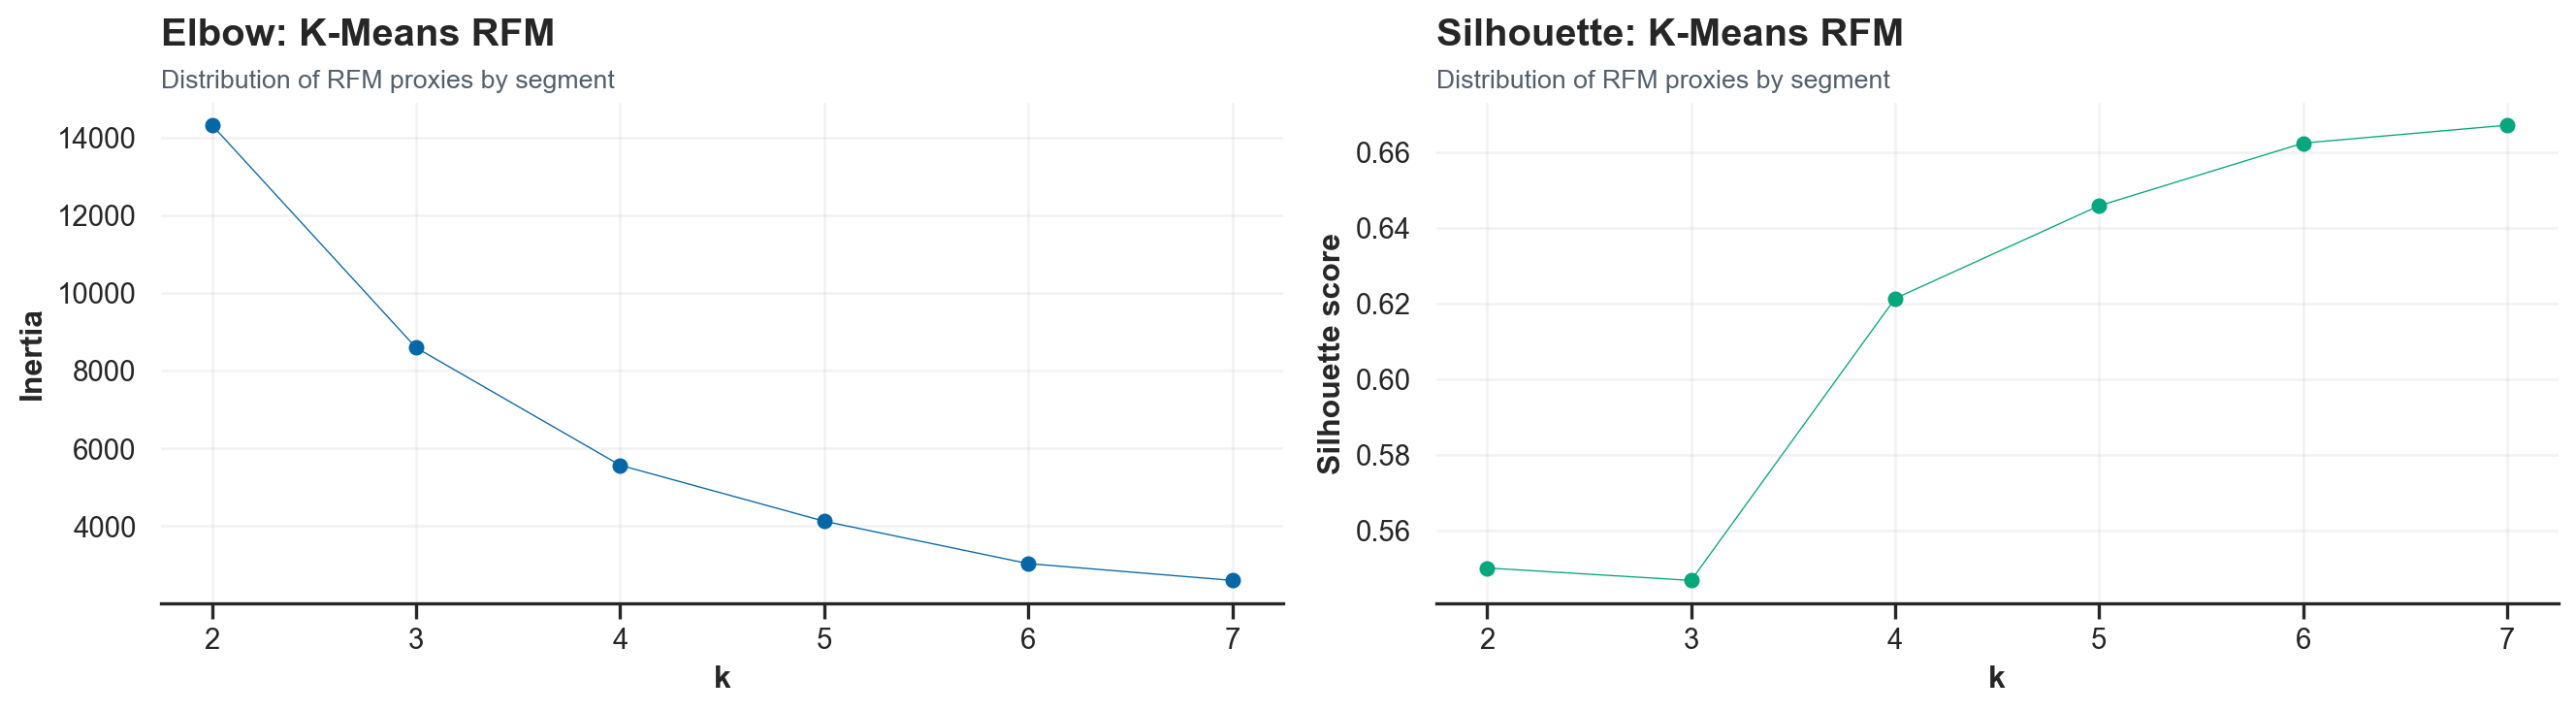

,RFM_Cluster,Segment,customers,recency_mean,frequency_mean,monetary_mean
2,2,High Value,1014,14.69,1.66,45.89
1,1,Medium Value,3889,18.96,1.00,0.17
0,0,Low Value,2406,6.41,1.73,0.00


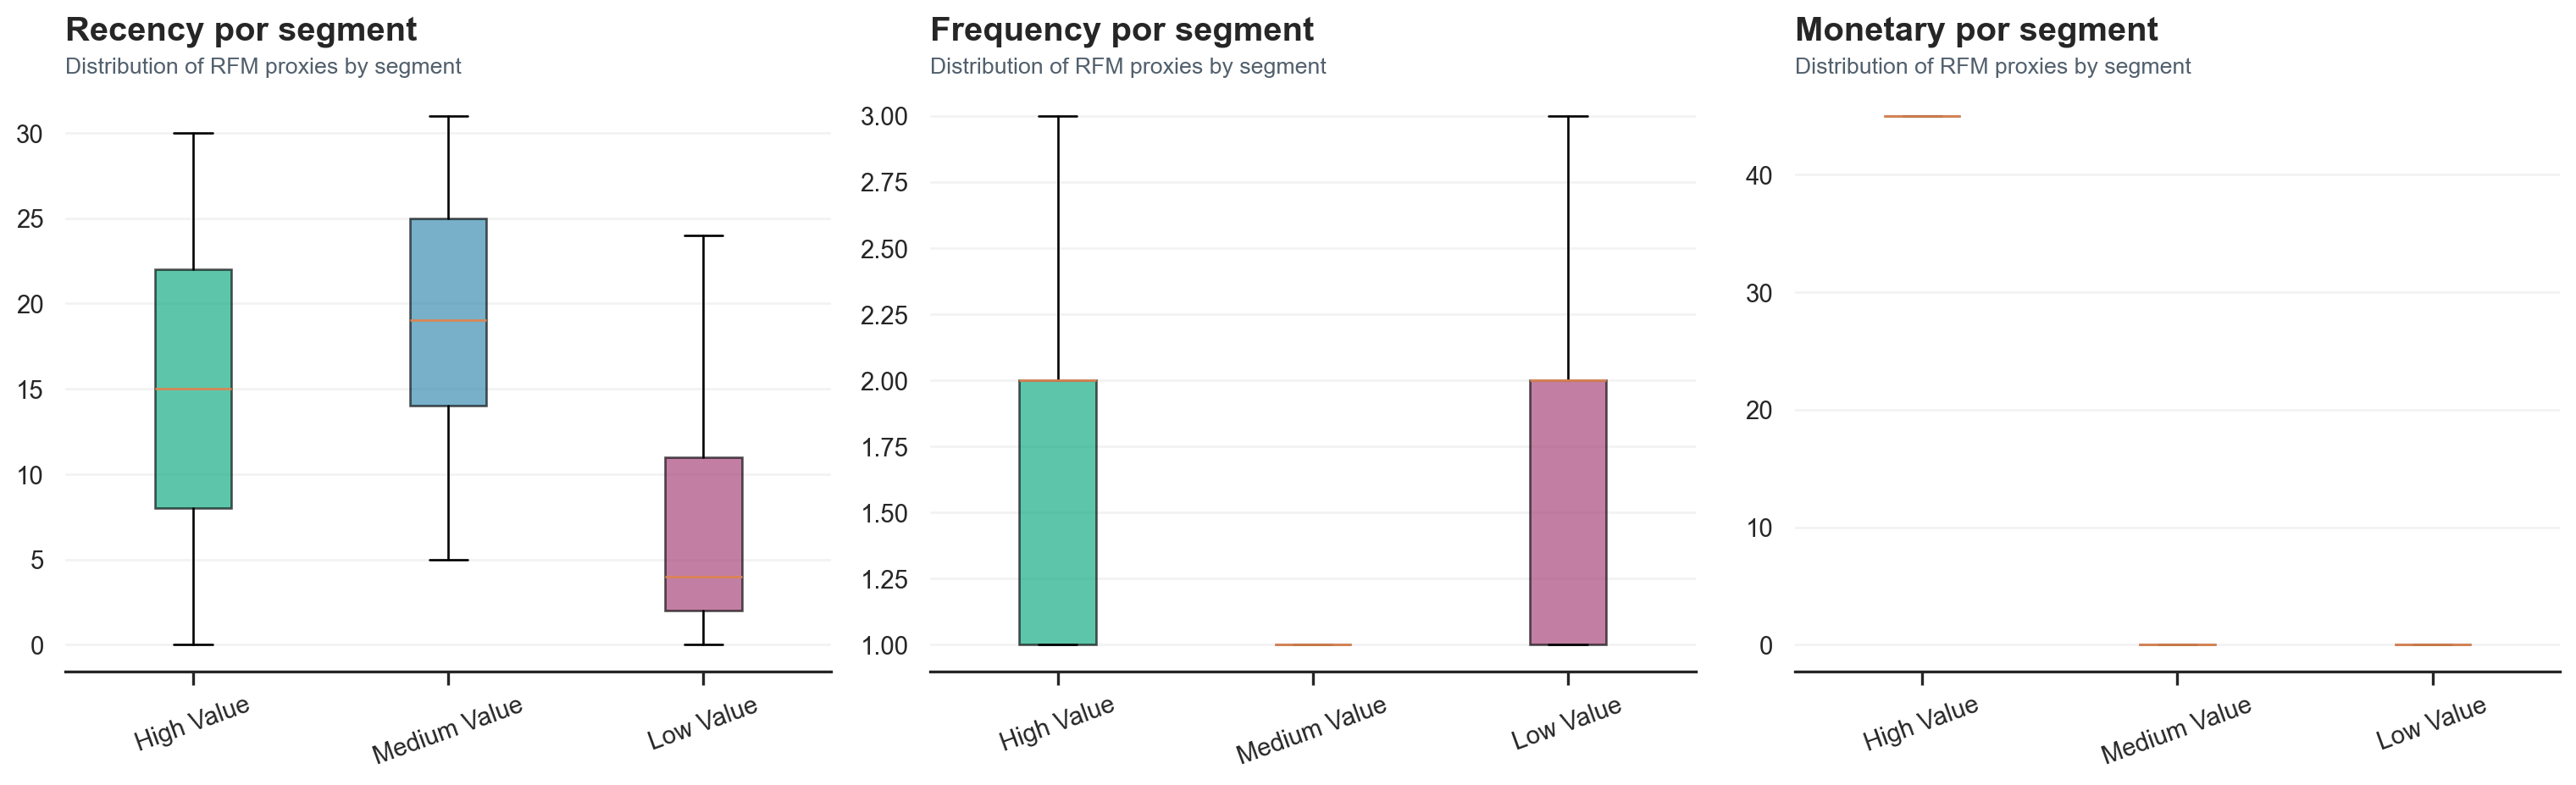

C1: Proxy-based RFM segmentation created and integrated into df_clean.


In [9]:
# C1: RFM proxies from campaign data.
# Warning: these are proxies, not transactional RFM.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm_proxy = df_clean.copy()
rfm_proxy["date_served"] = pd.to_datetime(
    rfm_proxy["date_served"],
    errors="coerce",
)

reference_date = rfm_proxy["date_served"].max()
recency_df = (
    rfm_proxy.groupby("user_id")["date_served"]
    .max()
    .apply(lambda d: (reference_date - d).days)
    .rename("Recency")
    .reset_index()
)

frequency_df = (
    rfm_proxy.groupby("user_id")["date_served"]
    .count()
    .rename("Frequency")
    .reset_index()
)

monetary_df = (
    rfm_proxy.groupby("user_id")["converted_flag"]
    .sum()
    .mul(REVENUE_PER_CONVERSION)
    .rename("Monetary")
    .reset_index()
)

rfm_df = recency_df.merge(frequency_df, on="user_id").merge(
    monetary_df,
    on="user_id",
)
recency_fill = rfm_df["Recency"].max() + 1
rfm_df["Recency"] = rfm_df["Recency"].fillna(recency_fill)
rfm_df["Frequency"] = rfm_df["Frequency"].fillna(0)
rfm_df["Monetary"] = rfm_df["Monetary"].fillna(0)

rfm_scaled = np.log1p(rfm_df[["Recency", "Frequency", "Monetary"]])
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm_scaled)

inertias: list[float] = []
silhouettes: list[float] = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_rfm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_rfm, labels))

rfm_k_diagnostics = pd.DataFrame(
    {
        "k": list(k_range),
        "inertia": inertias,
        "silhouette": silhouettes,
    }
)
display(rfm_k_diagnostics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rfm_k_diagnostics["k"], rfm_k_diagnostics["inertia"], marker=".", linewidth=0.5, color="#0667A7")
#axes[0].set_title("Elbow: K-Means RFM")
add_titles(axes[0], "Elbow: K-Means RFM", subtitle="Distribution of RFM proxies by segment")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.25)

axes[1].plot(
    rfm_k_diagnostics["k"],
    rfm_k_diagnostics["silhouette"],
    marker=".",
    linewidth=0.5,
    color="#06A77D",
)
#axes[1].set_title("Silhouette: K-Means RFM")
add_titles(axes[1], "Silhouette: K-Means RFM", subtitle="Distribution of RFM proxies by segment")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()
plt.close()

km_final = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
rfm_df["RFM_Cluster"] = km_final.fit_predict(X_rfm)

cluster_means = (
    rfm_df.groupby("RFM_Cluster")["Monetary"]
    .mean()
    .sort_values(ascending=False)
)
cluster_labels = ["High Value", "Medium Value", "Low Value"]
cluster_name_map = {
    cluster_id: cluster_labels[position]
    for position, cluster_id in enumerate(cluster_means.index)
}
rfm_df["Segment"] = rfm_df["RFM_Cluster"].map(cluster_name_map)

df_clean = df_clean.drop(
    columns=["RFM_Cluster", "Segment"],
    errors="ignore",
).merge(
    rfm_df[["user_id", "RFM_Cluster", "Segment"]],
    on="user_id",
    how="left",
)

rfm_cluster_summary = (
    rfm_df.groupby(["RFM_Cluster", "Segment"])
    .agg(
        customers=("user_id", "nunique"),
        recency_mean=("Recency", "mean"),
        frequency_mean=("Frequency", "mean"),
        monetary_mean=("Monetary", "mean"),
    )
    .reset_index()
    .sort_values("monetary_mean", ascending=False)
)
display(rfm_cluster_summary)

segment_order = ["High Value", "Medium Value", "Low Value"]
box_colors = ["#06A77D", "#2E86AB", "#A23B72"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["Recency", "Frequency", "Monetary"]):
    box_data = [
        rfm_df.loc[rfm_df["Segment"] == segment, metric]
        for segment in segment_order
    ]
    boxplot = ax.boxplot(
        box_data,
        tick_labels=segment_order,
        patch_artist=True,
        showfliers=False,
    )
    for patch, color in zip(boxplot["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    #ax.set_title(f"{metric} por segment", fontweight="bold")
    add_titles(ax, f"{metric} por segment", subtitle="Distribution of RFM proxies by segment")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
plt.close()

print("C1: Proxy-based RFM segmentation created and integrated into df_clean.")

<span style="color:steelblue; text-align: left">

## Customer Lifetime Value by Segment
</span>

With RFM segments defined, the next question is the economic value of each group.
Historical LTV is calculated per customer as estimated revenue minus campaign impact cost.
Segment-level average value replaces a single customer value in simulations.



,segment,ltv_mean,ltv_median,ltv_std,n_customers
0,High Value,44.10,43.50,5.95,1014
2,Medium Value,-0.93,-1.20,2.79,3889
1,Low Value,-1.86,-2.00,0.64,2406


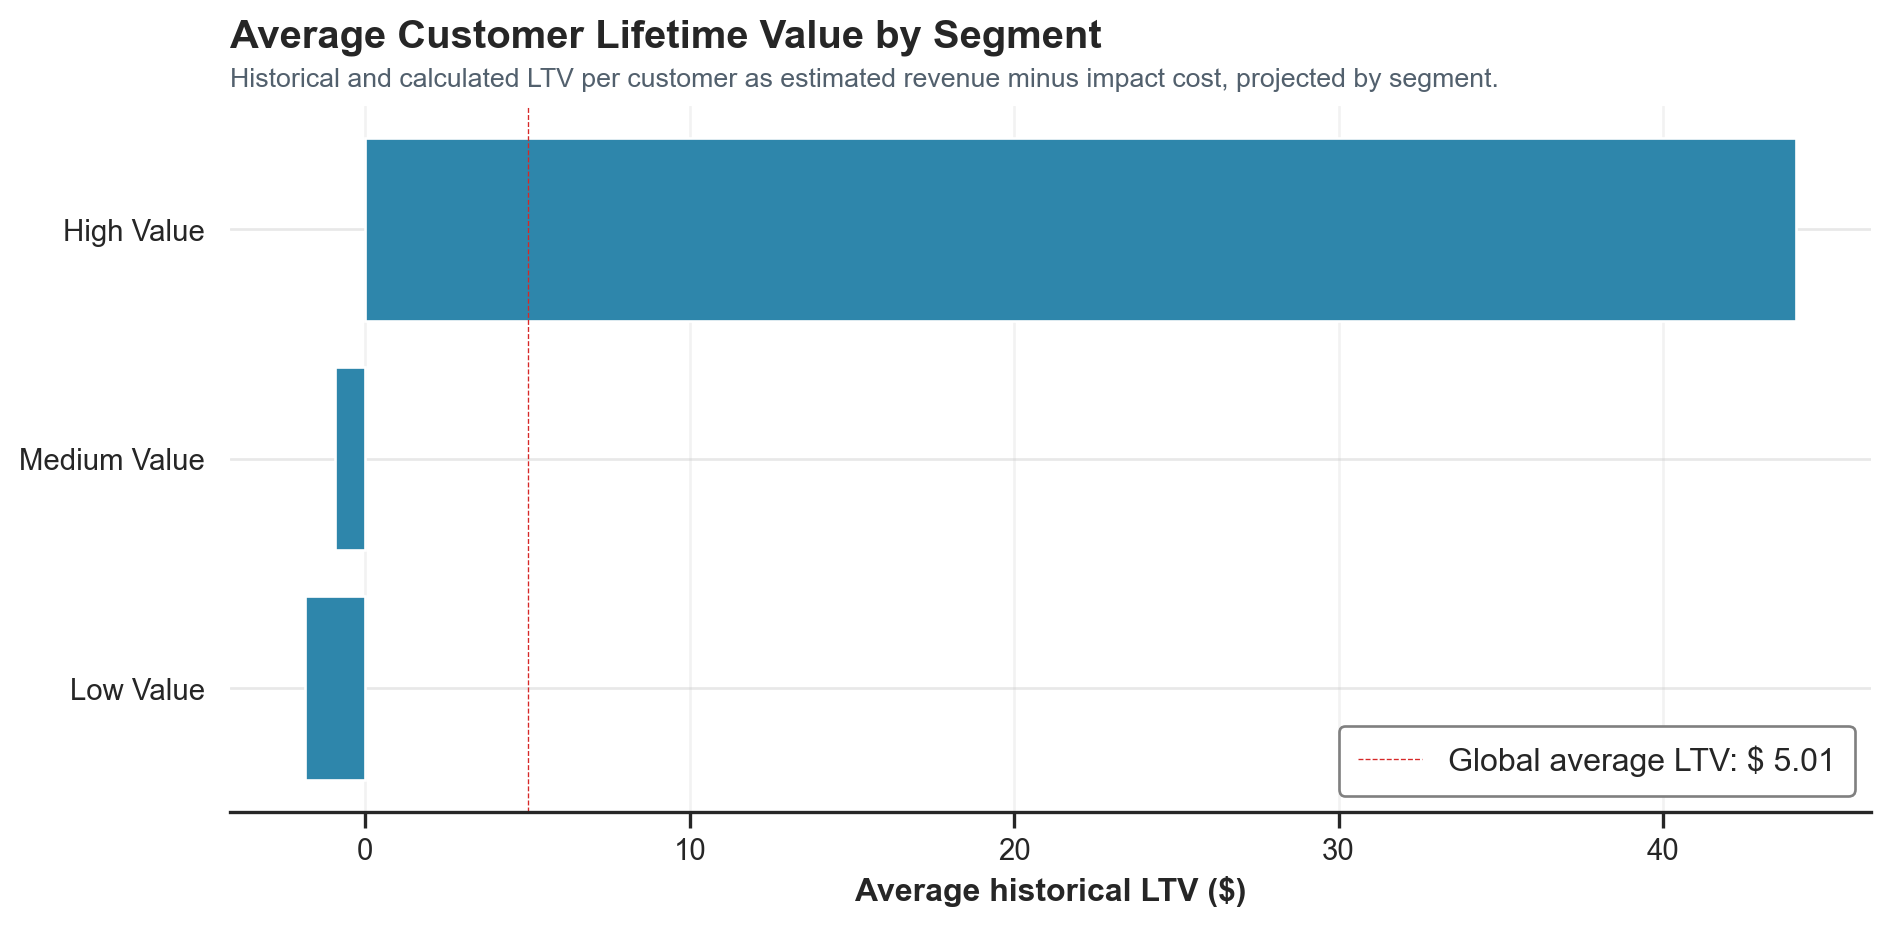

C2: LTV per segment calculated and available at segment_ltv_map.


In [10]:
# C2: Historical LTV calculated per customer and projected by segment.
# Historical LTV = generated revenue - estimated impact cost.
ltv_df = df_clean.copy()
ltv_df["revenue"] = ltv_df["converted_flag"] * REVENUE_PER_CONVERSION
ltv_df["cost"] = ltv_df["marketing_channel"].map(
    COST_PER_IMPRESSION,
).fillna(DEFAULT_COST)

ltv_by_customer = (
    ltv_df.groupby("user_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_cost=("cost", "sum"),
        segment=("Segment", "first"),
    )
    .assign(historical_ltv=lambda d: d["total_revenue"] - d["total_cost"])
    .reset_index()
)

ltv_by_segment = (
    ltv_by_customer.groupby("segment")["historical_ltv"]
    .agg(
        ltv_mean="mean",
        ltv_median="median",
        ltv_std="std",
        n_customers="count",
    )
    .reset_index()
    .sort_values("ltv_mean", ascending=False)
)
ltv_by_segment["ltv_std"] = ltv_by_segment["ltv_std"].fillna(0)
global_ltv = float(ltv_by_customer["historical_ltv"].mean())
segment_ltv_map: dict[str, float] = (
    ltv_by_segment.set_index("segment")["ltv_mean"].to_dict()
)

display(ltv_by_segment)

fig, ax = plt.subplots(figsize=(10, 5))
plot_ltv = ltv_by_segment.sort_values("ltv_mean", ascending=True)
ax.barh(plot_ltv["segment"], plot_ltv["ltv_mean"], color="#2E86AB")
ax.axvline(
    global_ltv,
    color="#D62828",
    linestyle="--",
    linewidth=0.5,
    label=f"Global average LTV: \\$ {global_ltv:,.2f}",
)
ax.set_xlabel("Average historical LTV ($)", fontweight="bold")
#ax.set_title("Average Customer Lifetime Value by Segment", fontweight="bold")
add_titles(ax, "Average Customer Lifetime Value by Segment", subtitle="Historical and calculated LTV per customer as estimated revenue minus impact cost, projected by segment.")
ax.grid(axis="x", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

print("C2: LTV per segment calculated and available at segment_ltv_map.")

<span style="color:steelblue; text-align: left">

## Descriptive Exploration
</span>

After cleaning, we validate dataset composition before inference or modeling.

This stage provides initial exploratory analysis to understand overall campaign behavior and key variable distributions.

The objective is to identify preliminary patterns related to:
- conversion volume;
- user retention;
- distribution across A/B test groups;
- channel usage intensity.

The charts allow quick checks for imbalance, user concentration across channels, and initial differences between campaign variants.

This exploration provides context for statistical inference, predictive modeling, and campaign optimization.




DESCRIPTIVE EXPLORATION


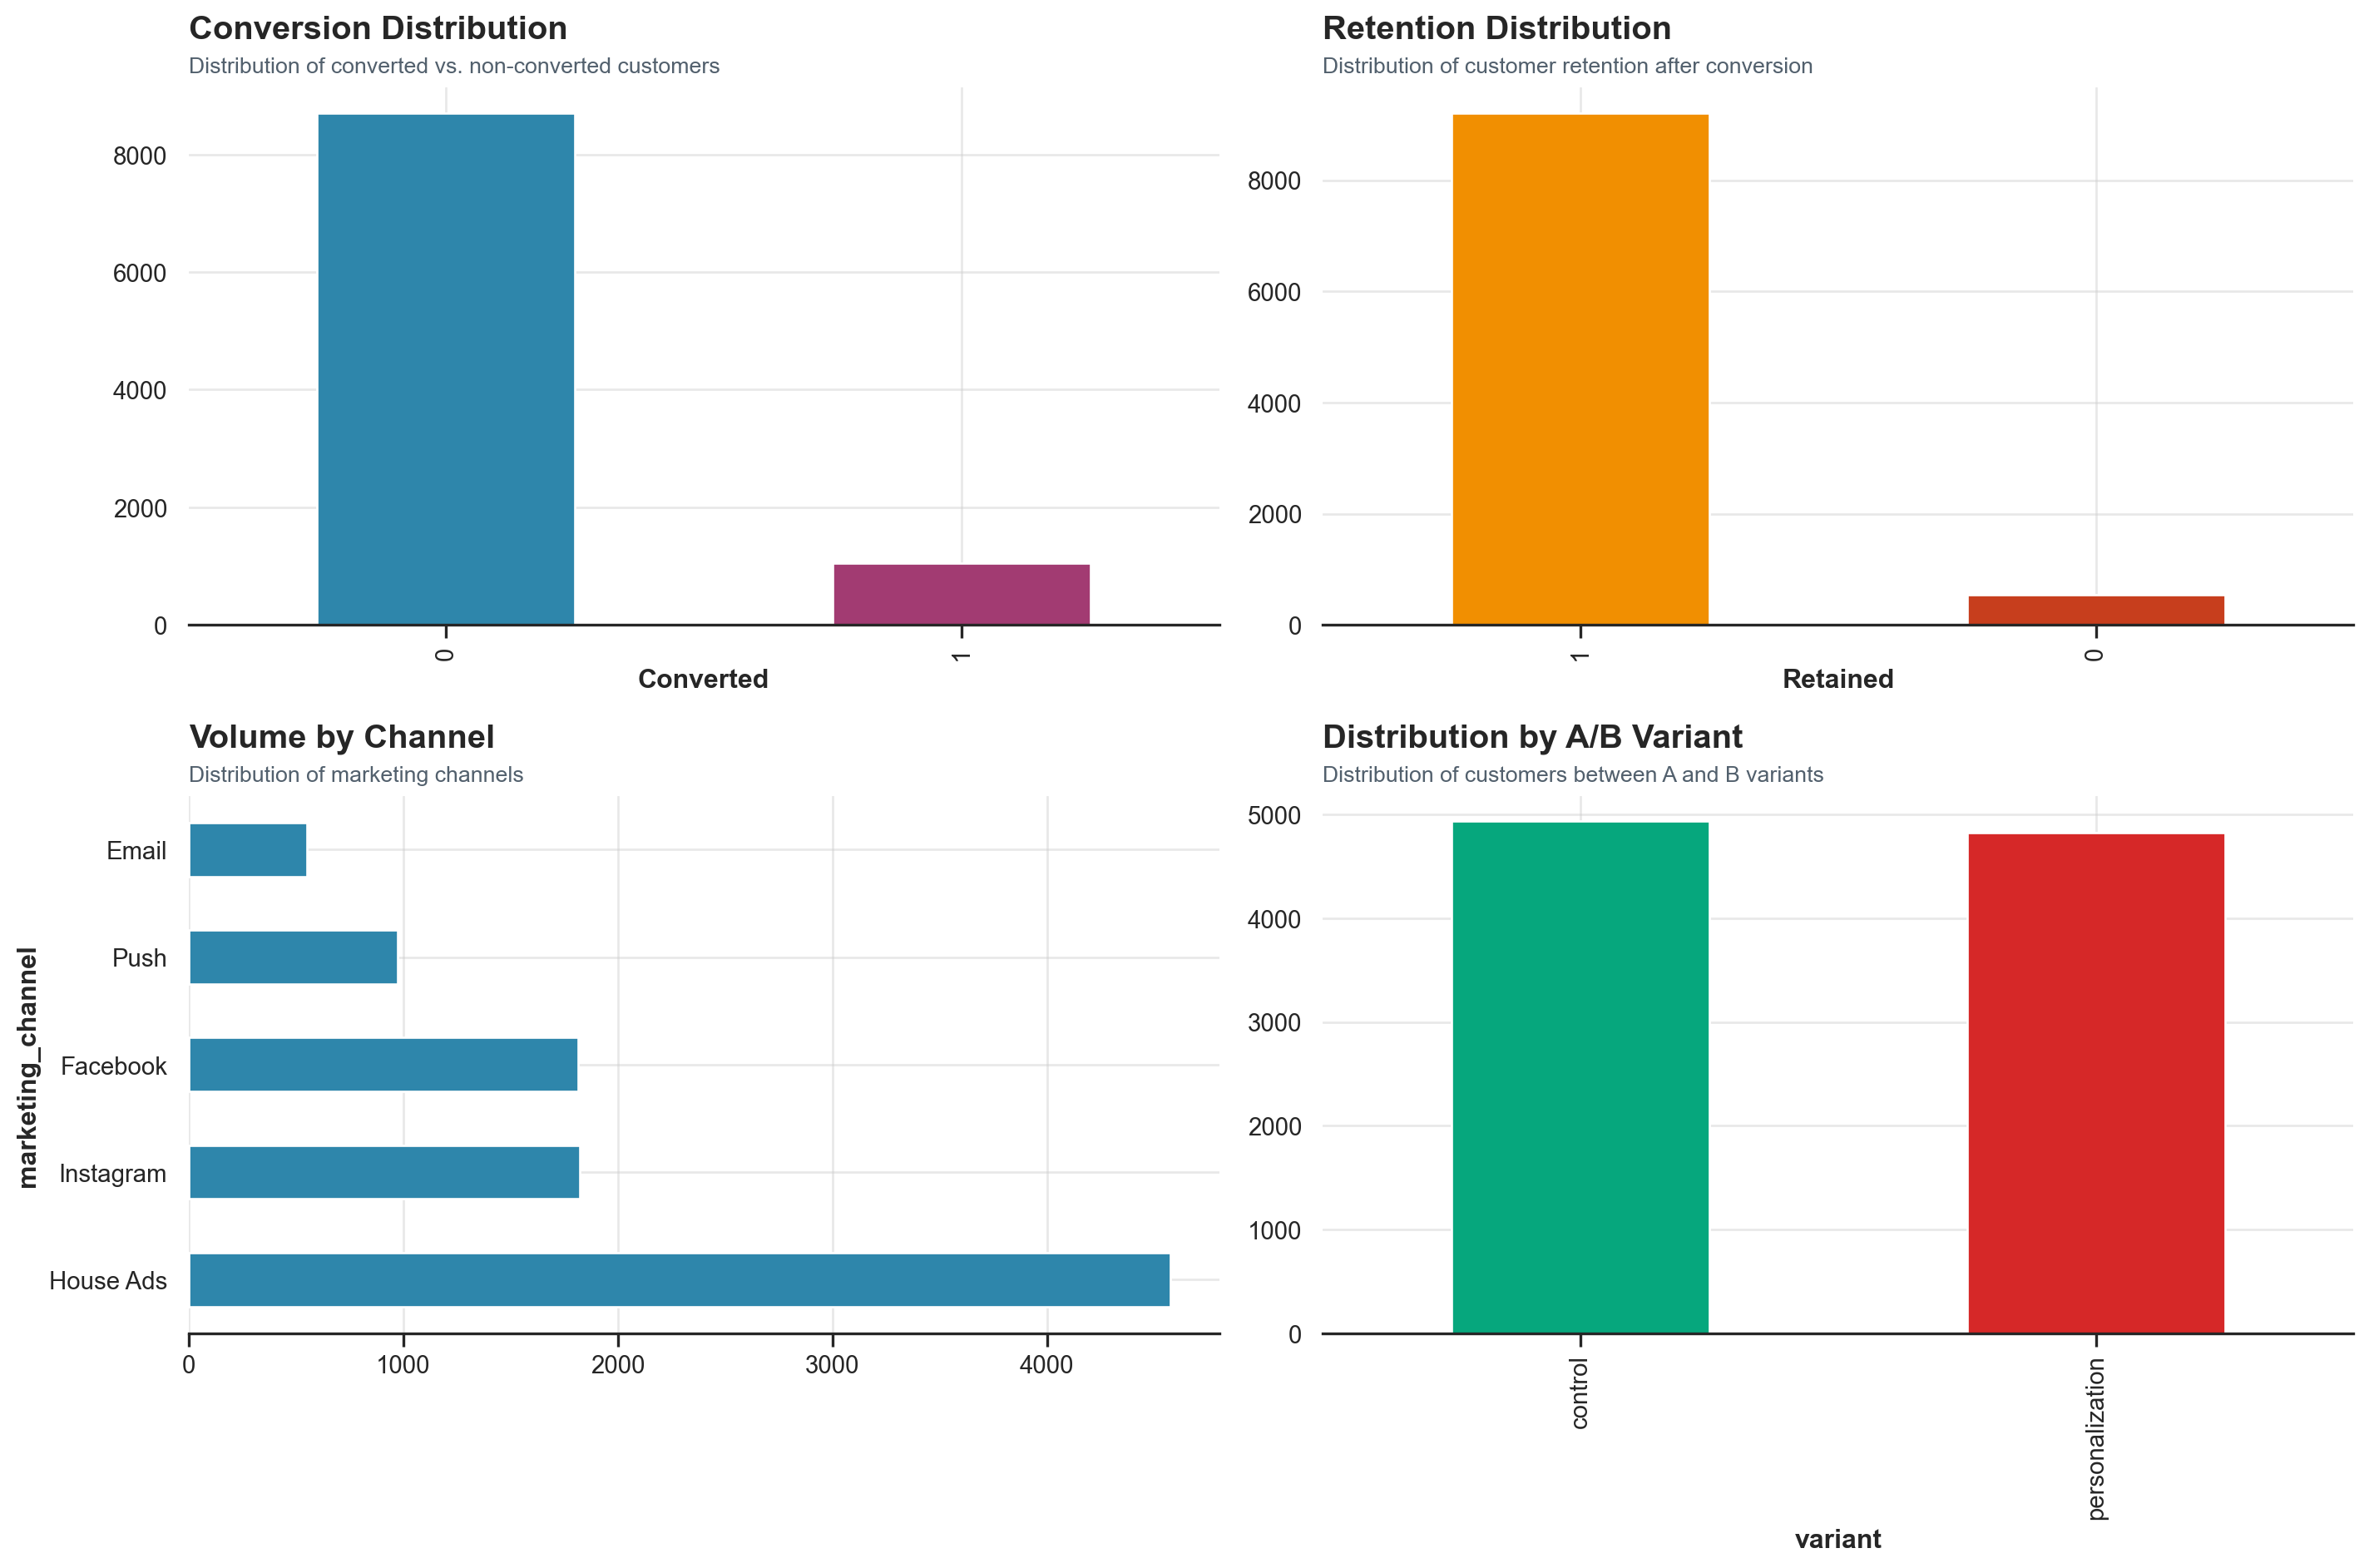

✓ Exploration charts created


In [11]:
def explore_distributions(df: pd.DataFrame) -> None:
    """Explore univariate distributions and correlations."""
    print("\n" + "=" * 80)
    print("DESCRIPTIVE EXPLORATION")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    if "converted_flag" in df.columns:
        df["converted_flag"].value_counts().plot(
            kind="bar", ax=axes[0, 0], color=["#2E86AB", "#A23B72"]
        )
        #axes[0, 0].set_title("Conversion Distribution", fontweight="bold")
        add_titles(axes[0, 0], "Conversion Distribution", subtitle="Distribution of converted vs. non-converted customers")
        
        axes[0, 0].set_xlabel("Converted")
    
    if "retained_flag" in df.columns:
        df["retained_flag"].value_counts().plot(
            kind="bar", ax=axes[0, 1], color=["#F18F01", "#C73E1D"]
        )
        #axes[0, 1].set_title("Retention Distribution", fontweight="bold")
        add_titles(axes[0, 1], "Retention Distribution", subtitle="Distribution of customer retention after conversion")
        axes[0, 1].set_xlabel("Retained")
    
    if "marketing_channel" in df.columns:
        df["marketing_channel"].value_counts().plot(
            kind="barh", ax=axes[1, 0], color="#2E86AB"
        )
        #axes[1, 0].set_title("Volume by Channel", fontweight="bold")
        add_titles(axes[1, 0], "Volume by Channel", subtitle="Distribution of marketing channels")
    
    if "variant" in df.columns:
        df["variant"].value_counts().plot(
            kind="bar", ax=axes[1, 1], color=["#06A77D", "#D62828"]
        )
        #axes[1, 1].set_title("Distribution by A/B Variant", fontweight="bold")
        add_titles(axes[1, 1], "Distribution by A/B Variant", subtitle="Distribution of customers between A and B variants")
    
    plt.tight_layout()
    plt.show()
    plt.close()
    print("✓ Exploration charts created")

explore_distributions(df_clean)

<span style="color:steelblue; text-align: left">

### Insights

</span>

>Descriptive analysis shows a typical digital-campaign scenario with class imbalance between converted and non-converted users. Retention occurs at a higher rate than conversion, and the primary bottleneck is initial conversion rather than retention.



<span style="color:steelblue; text-align: left">

## Funnel Analysis

</span>

This section evaluates campaign performance across key funnel stages: impact, conversion, and retention.

The funnel captures progressive user drop-off throughout the customer journey. Not all impacted users convert, and not all converted users remain active after conversion.

Strategic questions addressed:
- how many users were effectively impacted by the campaign;
- what share converted;
- how many remained retained after conversion;
- where the largest user loss occurs.

The dataset contains 7,309 impacted users.

**Immediate question:**
- `At which stages are users lost before retention?`

The funnel indicates where optimization effort should be concentrated.




FUNNEL ANALYSIS


,Metric,Value
0,Impacted Users,7309.00
1,Conversions,1049.00
2,Retained (among converted),700.00
3,Conversion Rate (%),10.75
4,Retention Rate (%),66.73


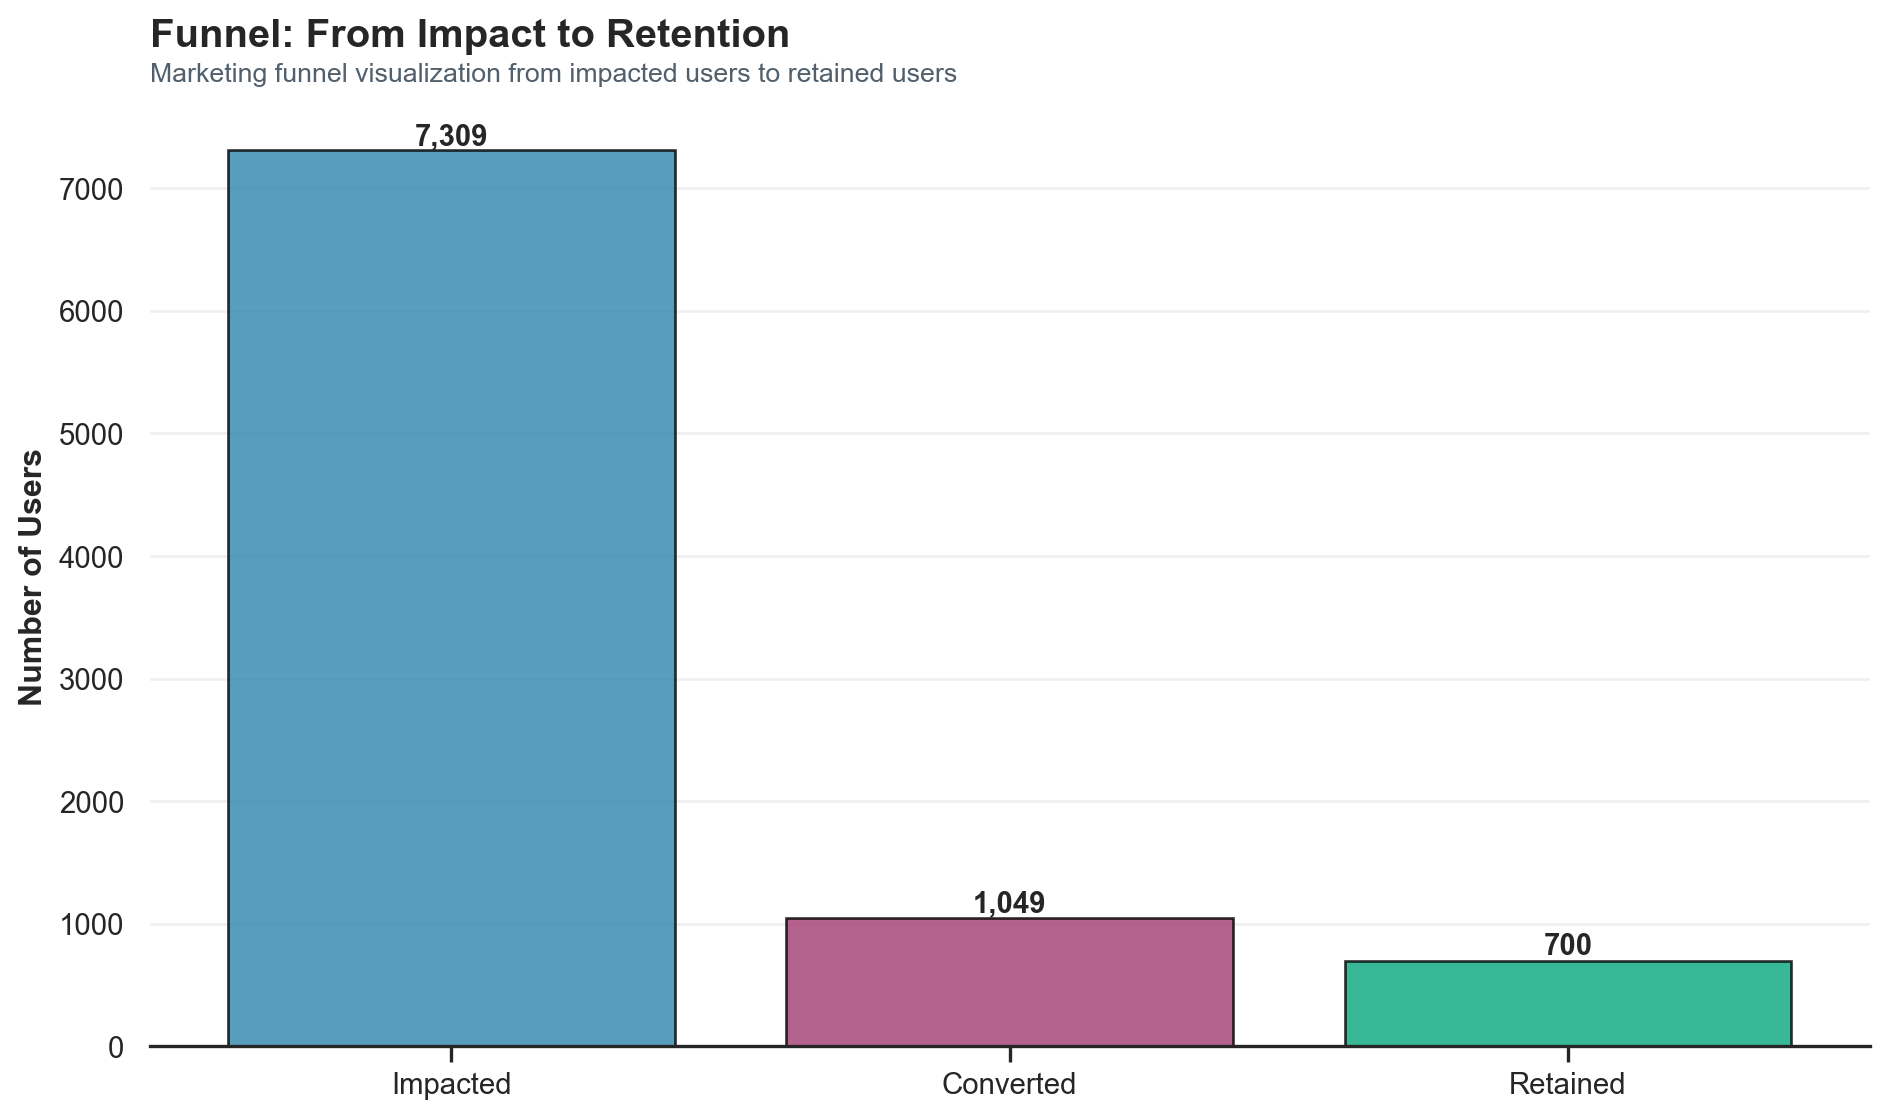

✓ Funnel built


In [12]:
def build_funnel(df: pd.DataFrame) -> pd.DataFrame:
    """Build funnel analysis."""
    print("\n" + "=" * 80)
    print("FUNNEL ANALYSIS")
    print("=" * 80)
    
    funnel_metrics = {
        "Metric": [
            "Impacted Users",
            "Conversions",
            "Retained (among converted)",
            "Conversion Rate (%)",
            "Retention Rate (%)"
        ],
        "Value": [
            df["user_id"].nunique(),
            int(df["converted_flag"].sum()),
            int(df[df["converted_flag"] == 1]["retained_flag"].sum()),
            round((df["converted_flag"].sum() / len(df)) * 100, 2),
            round(
                (df[df["converted_flag"] == 1]["retained_flag"].sum() /
                 max(df["converted_flag"].sum(), 1)) * 100, 2
            )
        ]
    }
    
    funnel_df = pd.DataFrame(funnel_metrics)
    display(funnel_df)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    stages = ["Impacted", "Converted", "Retained"]
    counts = [
        df["user_id"].nunique(),
        int(df["converted_flag"].sum()),
        int(df[df["converted_flag"] == 1]["retained_flag"].sum())
    ]
    colors = ["#2E86AB", "#A23B72", "#06A77D"]
    
    bars = ax.bar(stages, counts, color=colors, alpha=0.8, edgecolor="black")
    
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                f"{int(count):,}", ha="center", va="bottom",
                fontweight="bold", fontsize=11)
    
    ax.set_ylabel("Number of Users", fontweight="bold")
    #ax.set_title("Funnel: From Impact to Retention", fontweight="bold")
    add_titles(ax, "Funnel: From Impact to Retention", subtitle="Marketing funnel visualization from impacted users to retained users")
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ Funnel built")

    return funnel_df

funnel_summary = build_funnel(df_clean)

In [13]:
from IPython.display import Markdown

conv_rate = float(
    funnel_summary.loc[
        funnel_summary["Metric"] == "Conversion Rate (%)",
        "Value",
    ].iloc[0]
)
ret_rate = float(
    funnel_summary.loc[
        funnel_summary["Metric"] == "Retention Rate (%)",
        "Value",
    ].iloc[0]
)
impacto_1pp = df_clean["user_id"].nunique() * 0.01 * REVENUE_PER_CONVERSION

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Funnel Insights

</span>

**What the data shows:** {conv_rate:.1f}% of impacted users convert and {ret_rate:.1f}% of converts remain. The biggest loss occurs in conversion, not retention.
**Why it matters:** The main bottleneck is qualified acquisition, not post-conversion retention. Focusing efforts here has greater leverage.
**Recommended action:** Prioritize budget optimization in channels and variants that increase initial conversion.
**Estimated impact:** Each +1 p.p. in conversion generates approximately \\$ {impacto_1pp:,.0f} in additional revenue on the current base.
"""))



<span style="color:steelblue; text-align: left">

### Funnel Insights

</span>

**What the data shows:** 10.8% of impacted users convert and 66.7% of converts remain. The biggest loss occurs in conversion, not retention.
**Why it matters:** The main bottleneck is qualified acquisition, not post-conversion retention. Focusing efforts here has greater leverage.
**Recommended action:** Prioritize budget optimization in channels and variants that increase initial conversion.
**Estimated impact:** Each +1 p.p. in conversion generates approximately \$ 3,289 in additional revenue on the current base.


<span style="color:steelblue; text-align: left">

## Channel Performance Analysis

</span>

The funnel showed that the largest loss occurs at conversion.

In this section, we evaluate performance metrics by marketing channel. The objective is to identify channels with stronger conversion, retention, and economic return, considering:

- impacted user volume;
- number of conversions;
- retention;
- cancellations;
- conversion rate;
- retention rate.

This approach enables operational efficiency comparison across channels and identifies which acquisition strategies bring higher-quality users through the journey.

Beyond raw conversion volume, this section addresses a core marketing analytics question:
- `Which channels attract users with higher probability of staying active after initial conversion?`

Now: which channel wastes more budget in this loss process, and which channel delivers users with better retention potential?




CHANNEL PERFORMANCE ANALYSIS


,marketing_channel,impacted_users,conversions,retained,cancellations,conversion_rate_%,retention_rate_%
0,Email,552,187,143,53,33.88,76.47
3,Instagram,1726,243,159,116,14.08,65.43
1,Facebook,1744,227,156,100,13.02,68.72
4,Push,963,79,54,38,8.20,68.35
2,House Ads,3911,298,173,240,7.62,58.05


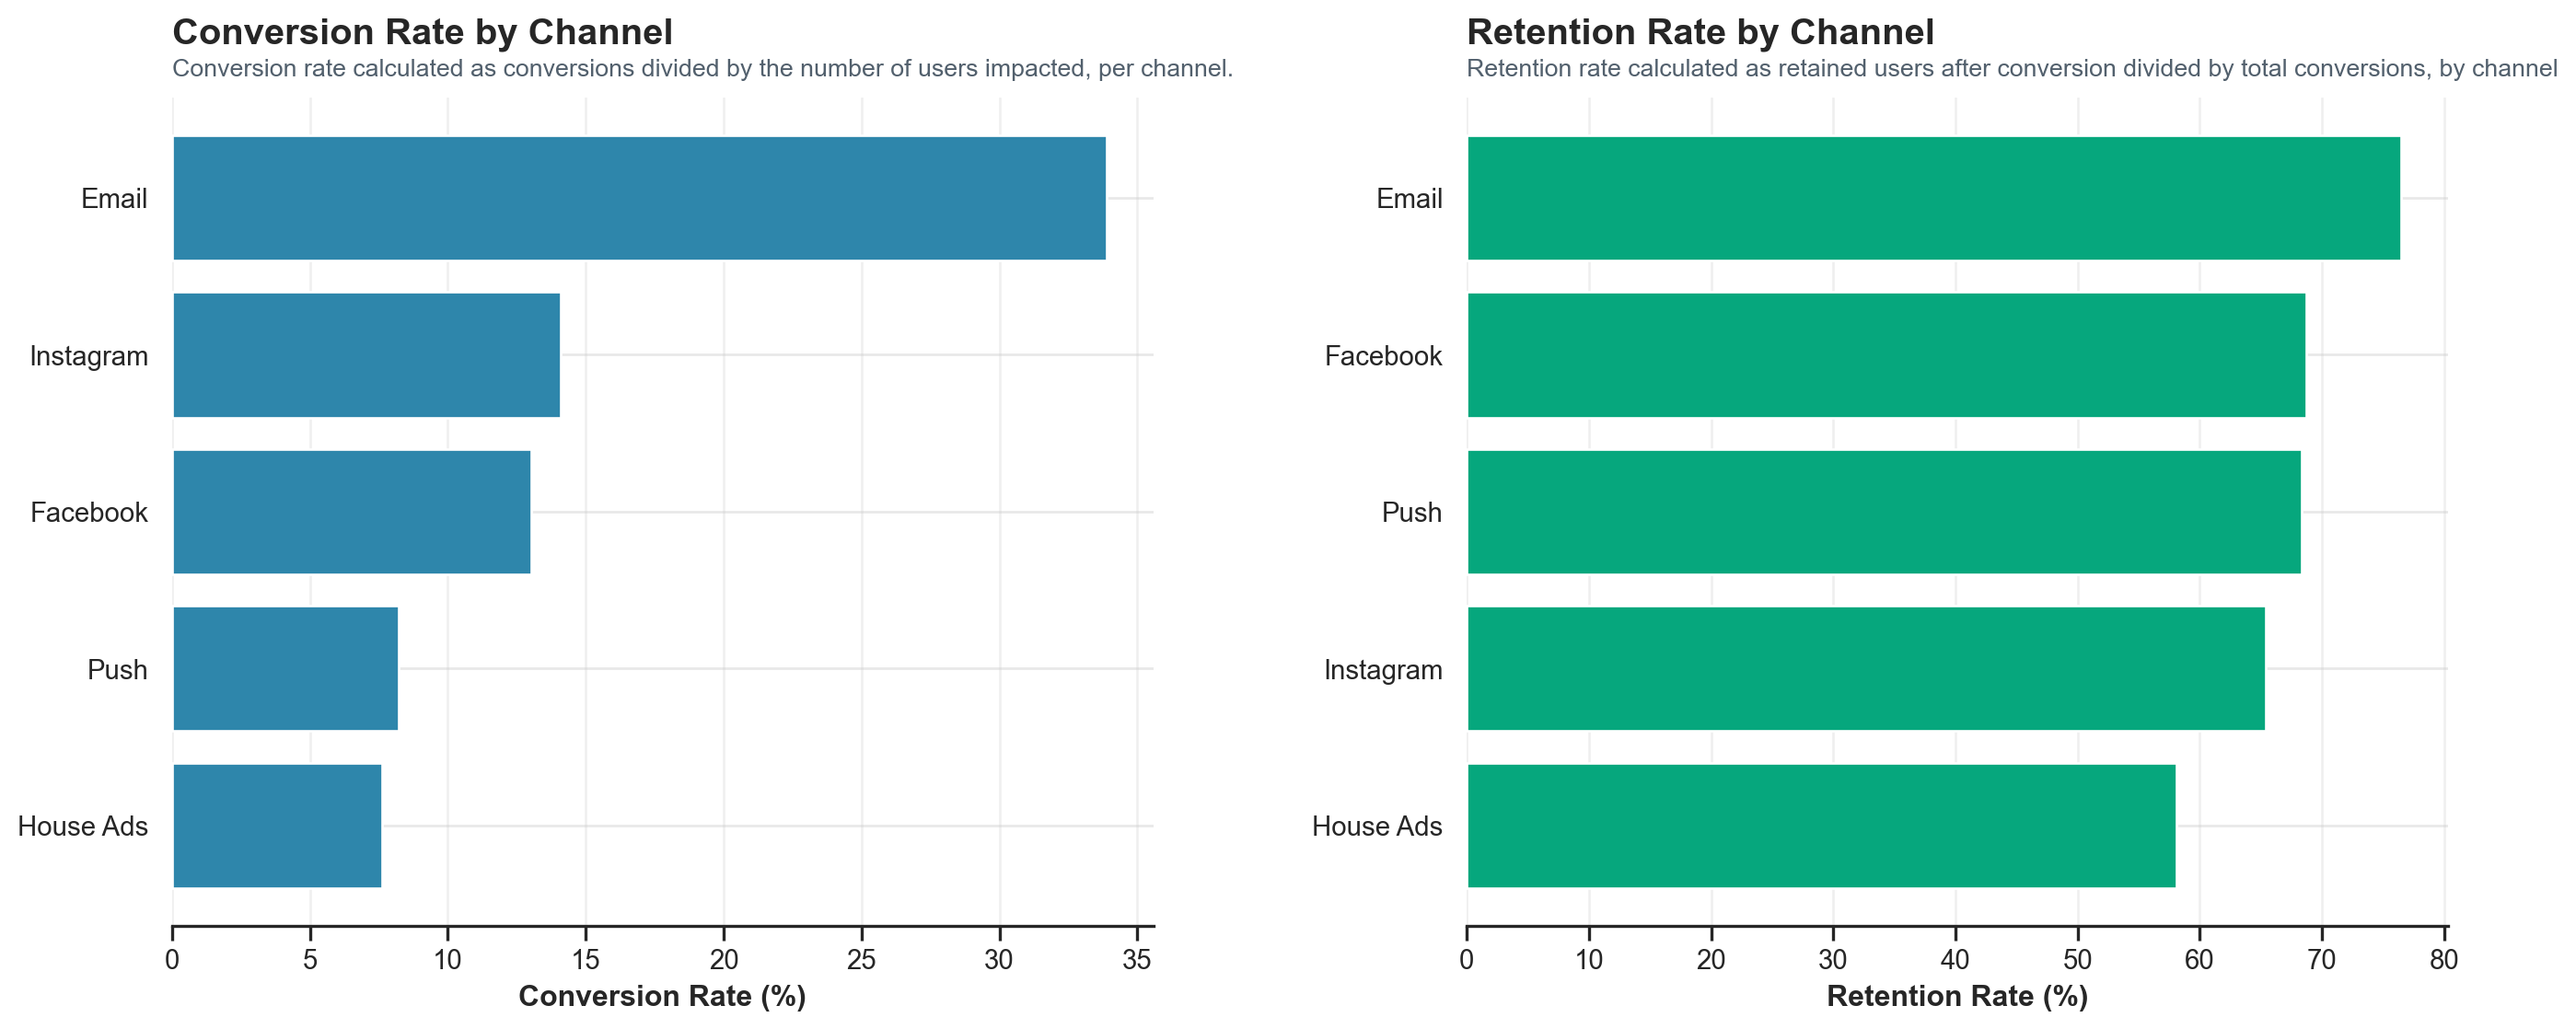

✓ Channel analysis completed


In [14]:
def analyze_channel_performance(df: pd.DataFrame) -> pd.DataFrame:
    """Analyze channel performance."""
    print("\n" + "=" * 80)
    print("CHANNEL PERFORMANCE ANALYSIS")
    print("=" * 80)
    
    # Valid retention: user converted and then retained.
    df_channel = df.copy()
    df_channel["retained_after_conversion"] = (
        (df_channel["converted_flag"] == 1)
        & (df_channel["retained_flag"] == 1)
    ).astype(int)

    agg_dict = {
        "impacted_users": ("user_id", "nunique"),
        "conversions": ("converted_flag", "sum"),
        "retained": ("retained_after_conversion", "sum"),
    }
    
    if "date_canceled" in df_channel.columns:
        agg_dict["cancellations"] = ("date_canceled", lambda x: x.notna().sum())
    
    channel_summary = df_channel.groupby("marketing_channel").agg(**agg_dict).reset_index()
    
    if "cancellations" not in channel_summary.columns:
        channel_summary["cancellations"] = 0
    
    channel_summary["conversion_rate_%"] = round(
        (channel_summary["conversions"] / channel_summary["impacted_users"]) * 100, 2
    )
    retention_rate = (
        channel_summary["retained"]
        / channel_summary["conversions"].replace(0, pd.NA)
    ) * 100
    channel_summary["retention_rate_%"] = (
        retention_rate.fillna(0).clip(lower=0, upper=100).round(2)
    )
    
    channel_summary = channel_summary.sort_values("conversion_rate_%", ascending=False)
    
    display(channel_summary)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    sorted_data = channel_summary.sort_values("conversion_rate_%", ascending=True)
    axes[0].barh(sorted_data["marketing_channel"], sorted_data["conversion_rate_%"], color="#2E86AB")
    axes[0].set_xlabel("Conversion Rate (%)", fontweight="bold")
    #axes[0].set_title("Conversion Rate by Channel", fontweight="bold")
    add_titles(axes[0], "Conversion Rate by Channel", 
            subtitle="Conversion rate calculated as conversions divided by the number of users impacted, per channel.")
    axes[0].grid(axis="x", alpha=0.3)
    
    sorted_data = channel_summary.sort_values("retention_rate_%", ascending=True)
    axes[1].barh(sorted_data["marketing_channel"], sorted_data["retention_rate_%"], color="#06A77D")
    axes[1].set_xlabel("Retention Rate (%)", fontweight="bold")
    #axes[1].set_title("Retention Rate by Channel", fontweight="bold")
    add_titles(axes[1], "Retention Rate by Channel", 
            subtitle="Retention rate calculated as retained users after conversion divided by total conversions, by channel")
    axes[1].grid(axis="x", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ Channel analysis completed")
    return channel_summary

channel_summary = analyze_channel_performance(df_clean)

In [15]:
from IPython.display import Markdown

# FIX 1: Real comparison of all channels across both dimensions.
# Do not assume which channel dominates which dimension - let the data decide.
channel_metrics = channel_summary.set_index("marketing_channel")

# Email
email_conv = float(channel_metrics.loc["Email", "conversion_rate_%"]) if "Email" in channel_metrics.index else 0.0
email_ret = float(channel_metrics.loc["Email", "retention_rate_%"]) if "Email" in channel_metrics.index else 0.0

# House Ads
house_conv = float(channel_metrics.loc["House Ads", "conversion_rate_%"]) if "House Ads" in channel_metrics.index else 0.0
house_ret = float(channel_metrics.loc["House Ads", "retention_rate_%"]) if "House Ads" in channel_metrics.index else 0.0

if not channel_summary.empty:
    best_conv_channel = channel_summary.loc[
        channel_summary["conversion_rate_%"].idxmax(), "marketing_channel"
    ]
    best_ret_channel = channel_summary.loc[
        channel_summary["retention_rate_%"].idxmax(), "marketing_channel"
    ]
    best_conv_rate = float(channel_summary["conversion_rate_%"].max())
    best_ret_rate = float(channel_summary["retention_rate_%"].max())
else:
    best_conv_channel = "N/D"
    best_ret_channel = "N/D"
    best_conv_rate = 0.0
    best_ret_rate = 0.0

email_dominates = (email_conv >= house_conv) and (email_ret >= house_ret)
house_dominates = (house_conv >= email_conv) and (house_ret >= email_ret)
tradeoff_exists = not email_dominates and not house_dominates

if email_dominates:
    action_text = (
        f"Email leads in both dimensions (conversion: {email_conv:.1f}% " 
        f"vs {house_conv:.1f}%; retention: {email_ret:.1f}% vs {house_ret:.1f}%). "
        "**Action**: Scale email budget. House Ads does not justify budget reallocation "
        "while email dominates both metrics."
    )
    realloc_direction = "from House Ads to Email"
elif tradeoff_exists:
    action_text = (
        f"There's a real tradeoff: {best_conv_channel} leads in conversion ({best_conv_rate:.1f}%) "
        f"and {best_ret_channel} leads in retention ({best_ret_rate:.1f}%). "
        f"**Action**: Use {best_conv_channel} for acquisition and "
        f"{best_ret_channel} for convert retention."

    )
    realloc_direction = (
        f"from {best_conv_channel} to {best_ret_channel} in retention campaigns"
    )
else:
    action_text = "House Ads leads on both dimensions. Review data; this is an uncommon result."
    realloc_direction = "review data before recommending"

_global_ltv_ref = float(
    globals().get("global_ltv", globals().get("ESTIMATED_CUSTOMER_VALUE", 0.0))
)
ltv_impact = _global_ltv_ref * 0.05

# Action 2 of the summary: based on real data, not a fixed hypothesis.
if email_dominates:
    acao2_texto = (
        f"**Focus budget on Email** - dominant channel in conversion ({email_conv:.1f}%) "
        f"and retention ({email_ret:.1f}%). Reduce allocation to channels with both "
        "metrics below average. Do not redirect to House Ads while Email dominates both dimensions."

    )
elif tradeoff_exists:
    acao2_texto = (        
        f"Separate channels by objective: {best_conv_channel} for acquisition, "
        f"{best_ret_channel} for retention. Allocate a percentage of the budget "
        "proportional to the expected value of each stage of the funnel. "
    )

else:
    acao2_texto = "Review channel performance data before recommending reallocation."

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Channel Insights
</span>

**What they show:** {action_text}

**Why it matters:** The channel with the highest conversion and highest retention simultaneously
should receive budget priority - there is no benefit in diversifying to channels
with inferior performance in both dimensions.

**Recommended action:** Concentrate the next campaign on the dominant channel.

Review current allocation: Is there budget in channels with a conversion rate below
{channel_summary["conversion_rate_%"].mean():.1f}% (overall average)?

**Estimated impact:** Budget reallocation {realloc_direction}
can increase incremental profit by ~\\$ {ltv_impact:,.0f} per user
for each additional retained user (conservative estimate: 5% gain in average LTV).
"""))


<span style="color:steelblue; text-align: left">

### Channel Insights
</span>

**What they show:** Email leads in both dimensions (conversion: 33.9% vs 7.6%; retention: 76.5% vs 58.0%). **Action**: Scale email budget. House Ads does not justify budget reallocation while email dominates both metrics.

**Why it matters:** The channel with the highest conversion and highest retention simultaneously
should receive budget priority - there is no benefit in diversifying to channels
with inferior performance in both dimensions.

**Recommended action:** Concentrate the next campaign on the dominant channel.

Review current allocation: Is there budget in channels with a conversion rate below
15.4% (overall average)?

**Estimated impact:** Budget reallocation from House Ads to Email
can increase incremental profit by ~\$ 0 per user
for each additional retained user (conservative estimate: 5% gain in average LTV).


<span style="color:steelblue; text-align: left">

## Language Personalization Analysis
</span>

Before the formal A/B test, we evaluate a simple operational hypothesis:
- `Do users impacted in the wrong language convert less?`

Language personalization is important in digital campaigns because it reduces communication friction and tends to make messaging clearer and more relevant. From a marketing analytics perspective, this analysis checks whether communication aligned with user profile improves campaign performance.

The comparison includes:

- users receiving the campaign in the preferred language;
- users receiving the campaign in a different language.

Analyzed metrics:
- conversion rate;
- retention rate among converted users.

If confirmed, language correction is already a high-leverage action with no additional campaign cost.




PERSONALIZATION ANALYSIS: CORRECT LANGUAGE


,label,user_id,converted_flag,retained_among_converted,conversion_rate_%,retention_rate_%
0,Wrong Language,403,27,14,6.70,51.85
1,Correct Language,6989,1022,686,14.62,67.12


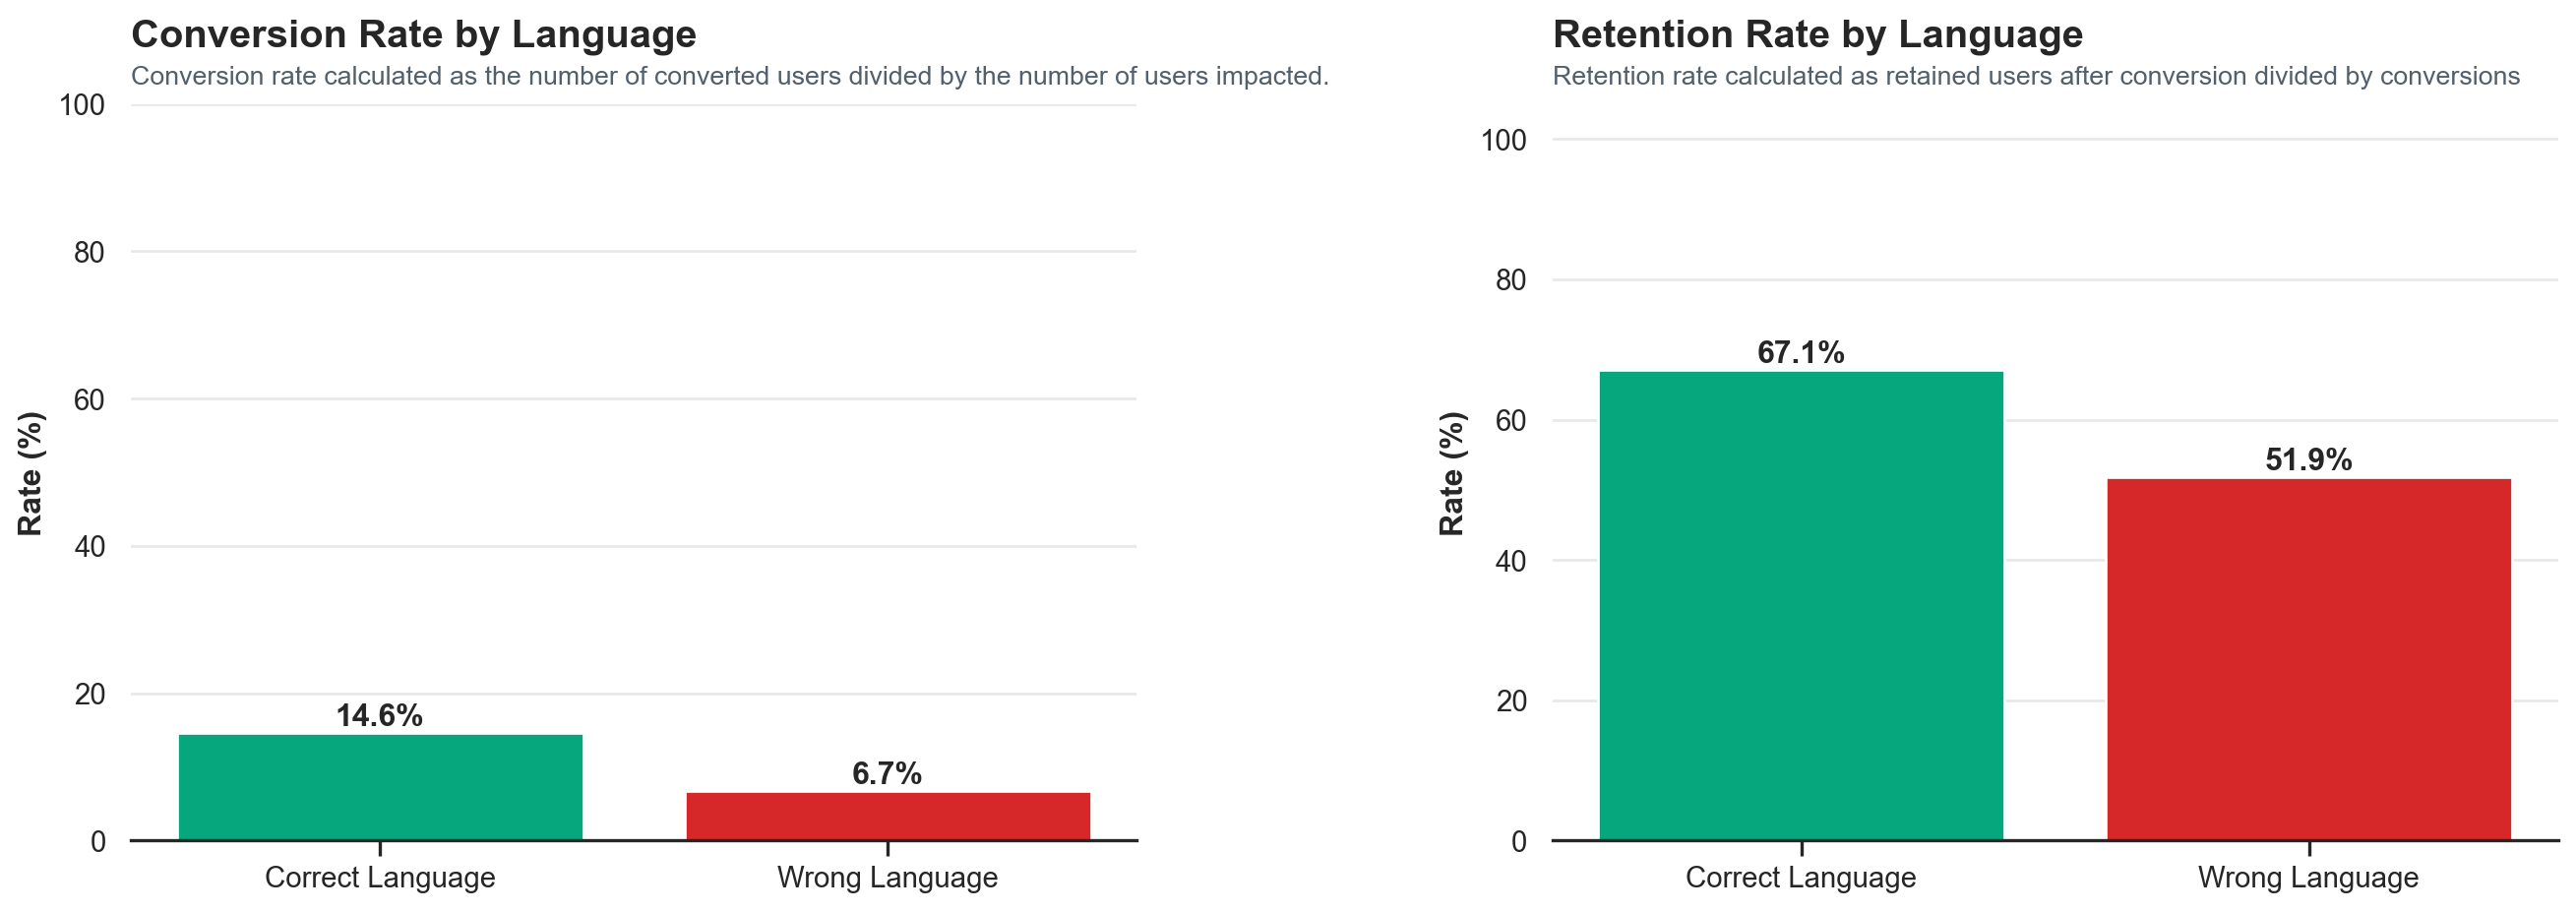

Language analysis completed.
Validation of retention by language: min=51.85% | max=67.12%


In [16]:
def analyze_language_performance(df: pd.DataFrame) -> pd.DataFrame | None:
    """Analyze correct-language impact."""
    if "is_correct_lang" not in df.columns:
        print("Column 'is_correct_lang' not found.")
        return None

    print("\n" + "=" * 80)
    print("PERSONALIZATION ANALYSIS: CORRECT LANGUAGE")
    print("=" * 80)

    data = df.copy()

    required_columns = ["user_id", "converted_flag", "retained_flag"]
    missing_columns = [col for col in required_columns if col not in data.columns]
    if missing_columns:
        print(f"Required columns missing: {missing_columns}")
        return None

    # Ensure binary flags so that sums represent counts.
    for flag_col in ["converted_flag", "retained_flag"]:
        data[flag_col] = (
            pd.to_numeric(data[flag_col], errors="coerce")
            .fillna(0)
            .clip(lower=0, upper=1)
            .astype(int)
        )

    data["is_correct_lang"] = data["is_correct_lang"].map({
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "Yes": 1,
        "No": 0,
        "yes": 1,
        "no": 0,
        1: 1,
        0: 0,
    })

    # General base: total users and total conversions per language.
    lang_summary = (
        data.groupby("is_correct_lang", dropna=False)
        .agg(
            user_id=("user_id", "nunique"),
            converted_flag=("converted_flag", "sum"),
        )
        .reset_index()
    )

    # retention: count retained_flag only within the converted subset.
    converted_df = data[data["converted_flag"] == 1].copy()
    retained_summary = (
        converted_df.groupby("is_correct_lang", dropna=False)
        .agg(retained_among_converted=("retained_flag", "sum"))
        .reset_index()
    )

    lang_summary = lang_summary.merge(
        retained_summary,
        on="is_correct_lang",
        how="left",
    )
    lang_summary["retained_among_converted"] = (
        lang_summary["retained_among_converted"].fillna(0).astype(int)
    )

    # conversion uses all users in the group as the denominator.
    lang_summary["conversion_rate_%"] = (
        lang_summary["converted_flag"]
        / lang_summary["user_id"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    # retention uses only converted users as denominator, so must stay <= 100%.
    lang_summary["retention_rate_%"] = (
        lang_summary["retained_among_converted"]
        / lang_summary["converted_flag"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    lang_labels = {
        1: "Correct Language",
        0: "Wrong Language",
    }

    lang_summary["label"] = (
        lang_summary["is_correct_lang"]
        .map(lang_labels)
        .fillna("Not informed")
    )

    display(
        lang_summary[
            [
                "label",
                "user_id",
                "converted_flag",
                "retained_among_converted",
                "conversion_rate_%",
                "retention_rate_%",
            ]
        ]
    )

    plot_df = (
        lang_summary.set_index("label")
        .reindex(["Correct Language", "Wrong Language"])
        .fillna(0)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(
        plot_df["label"],
        plot_df["conversion_rate_%"],
        color=["#06A77D", "#D62828"],
    )
    axes[0].set_ylabel("Rate (%)", fontweight="bold")
    #axes[0].set_title("Conversion Rate by Language", fontweight="bold")
    add_titles(axes[0], "Conversion Rate by Language", 
        subtitle="Conversion rate calculated as the number of converted users divided by the number of users impacted.")

    axes[0].set_ylim(0, max(100, plot_df["conversion_rate_%"].max() * 1.15))

    for i, value in enumerate(plot_df["conversion_rate_%"]):
        axes[0].text(
            i,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            fontweight="bold",
        )

    axes[1].bar(
        plot_df["label"],
        plot_df["retention_rate_%"],
        color=["#06A77D", "#D62828"],
    )
    axes[1].set_ylabel("Rate (%)", fontweight="bold")
    #axes[1].set_title("Retention Rate by Language", fontweight="bold")
    add_titles(axes[1], "Retention Rate by Language", 
            subtitle="Retention rate calculated as retained users after conversion divided by conversions")
    axes[1].set_ylim(0, 105)

    for i, value in enumerate(plot_df["retention_rate_%"]):
        axes[1].text(
            i,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()
    plt.close()

    print("Language analysis completed.")

    retention_min = lang_summary["retention_rate_%"].min()
    retention_max = lang_summary["retention_rate_%"].max()
    print(
        f"Validation of retention by language: min={retention_min:.2f}% | max={retention_max:.2f}%"
    )
    if (lang_summary["retention_rate_%"] > 100).any():
        print("ALERT: retention rate above 100%.")
        
    #else:
    #    print("Validation OK: no retention rate exceeds 100%.")

    return lang_summary

lang_summary = analyze_language_performance(df_clean)

In [17]:
from IPython.display import Markdown


def _safe_float(value: object, default: float = 0.0) -> float:
    try:
        if pd.isna(value):
            return float(default)
        return float(value)
    except Exception:
        return float(default)



def _normalize_lang_flag(value: object) -> float:
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return int(value)

    if isinstance(value, (int, np.integer)):
        return int(value) if int(value) in (0, 1) else np.nan

    if isinstance(value, (float, np.floating)):
        if np.isnan(value):
            return np.nan
        iv = int(value)
        return iv if iv in (0, 1) and float(iv) == float(value) else np.nan

    text = str(value).strip().lower()
    true_tokens = {"1", "true", "yes", "y", "correct", "right", "certo"}
    false_tokens = {"0", "false", "no", "n", "wrong", "incorrect", "errado"}

    if text in true_tokens:
        return 1
    if text in false_tokens:
        return 0
    return np.nan


lang_correct_conv = 0.0
lang_wrong_conv = 0.0
lang_correct_ret = 0.0
lang_wrong_ret = 0.0
_n_wrong = 0
_metrics_ready = False

if isinstance(globals().get("lang_summary"), pd.DataFrame) and not lang_summary.empty:
    _ls = lang_summary.copy()

    if "label" in _ls.columns:
        _by_label = _ls.set_index("label")
        if "Correct Language" in _by_label.index and "Wrong Language" in _by_label.index:
            lang_correct_conv = _safe_float(_by_label.at["Correct Language", "conversion_rate_%"])
            lang_wrong_conv = _safe_float(_by_label.at["Wrong Language", "conversion_rate_%"])
            lang_correct_ret = _safe_float(_by_label.at["Correct Language", "retention_rate_%"])
            lang_wrong_ret = _safe_float(_by_label.at["Wrong Language", "retention_rate_%"])
            _n_wrong = int(_safe_float(_by_label.at["Wrong Language", "user_id"]))
            _metrics_ready = True

if not _metrics_ready:
    _tmp = df_clean.copy()
    _tmp["lang_flag_norm"] = _tmp["is_correct_lang"].apply(_normalize_lang_flag)

    _base = (
        _tmp.groupby("lang_flag_norm", dropna=False)
        .agg(
            user_id=("user_id", "nunique"),
            converted_flag=("converted_flag", "sum"),
        )
        .reset_index()
    )

    _ret = (
        _tmp[_tmp["converted_flag"] == 1]
        .groupby("lang_flag_norm", dropna=False)
        .agg(retained_among_converted=("retained_flag", "sum"))
        .reset_index()
    )

    _sum = _base.merge(_ret, on="lang_flag_norm", how="left")
    _sum["retained_among_converted"] = _sum["retained_among_converted"].fillna(0)

    _sum["conversion_rate_%"] = (
        _sum["converted_flag"]
        / _sum["user_id"].replace(0, np.nan)
        * 100
    ).fillna(0)

    _sum["retention_rate_%"] = (
        _sum["retained_among_converted"]
        / _sum["converted_flag"].replace(0, np.nan)
        * 100
    ).fillna(0)

    _idx = _sum.set_index("lang_flag_norm")

    if 1 in _idx.index:
        lang_correct_conv = _safe_float(_idx.at[1, "conversion_rate_%"])
        lang_correct_ret = _safe_float(_idx.at[1, "retention_rate_%"])

    if 0 in _idx.index:
        lang_wrong_conv = _safe_float(_idx.at[0, "conversion_rate_%"])
        lang_wrong_ret = _safe_float(_idx.at[0, "retention_rate_%"])
        _n_wrong = int(_safe_float(_idx.at[0, "user_id"]))

_lang_lift_conv = lang_correct_conv - lang_wrong_conv
_lang_lift_ret = lang_correct_ret - lang_wrong_ret
_pct_wrong = _n_wrong / max(df_clean["user_id"].nunique(), 1) * 100

_impact_conv = _n_wrong * _lang_lift_conv / 100 * REVENUE_PER_CONVERSION
_ltv_ref = float(globals().get("global_ltv", globals().get("ESTIMATED_CUSTOMER_VALUE", 0.0)))
_impact_ret = _n_wrong * max(_lang_lift_ret, 0) / 100 * _ltv_ref * 0.15
lang_impact_total = _impact_conv + _impact_ret

if lang_impact_total == 0.0 and _n_wrong > 0:
    lang_impact_total = _n_wrong * _ltv_ref * 0.05
    lang_impact_note = (
        "Measured conversion lift = 0 p.p., but wrong-language exposure "
        "still has an estimated satisfaction cost of \\$ {:.0f} "
        "(5% LTV loss across {} users)."
    ).format(lang_impact_total, _n_wrong)
else:
    lang_impact_note = None


display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Language Personalization Insights

</span>

> **What it shows:** users receiving the correct language convert at {lang_correct_conv:.1f}%
> versus {lang_wrong_conv:.1f}% when exposed to the wrong language - a difference of {_lang_lift_conv:.1f} p.p.
> There are {_n_wrong:,} users ({_pct_wrong:.1f}% of the dataset) being impacted in the wrong language.
>
> **Why it matters:** incorrect language delivery affects both immediate conversion
> and long-term retention. Even small conversion differences may generate meaningful
> impact on customer lifetime value (LTV).
>
> **Recommended action:** implement automatic language detection based on
> `language_preferred` before serving campaigns.
>
> **Estimated impact:** correcting language delivery for {_n_wrong:,.0f} users could generate
> approximately \\$ {lang_impact_total:,.0f}  in additional estimated revenue
> (conversion: \\$ {_impact_conv:,.0f} + retention/LTV: \\$ {_impact_ret:,.0f}).
"""))

if lang_impact_note:
    print(lang_impact_note)

# Export for executive summary.
lang_impact_final = lang_impact_total
n_wrong_lang = _n_wrong



<span style="color:steelblue; text-align: left">

### Language Personalization Insights

</span>

> **What it shows:** users receiving the correct language convert at 14.6%
> versus 6.7% when exposed to the wrong language - a difference of 7.9 p.p.
> There are 403 users (5.5% of the dataset) being impacted in the wrong language.
>
> **Why it matters:** incorrect language delivery affects both immediate conversion
> and long-term retention. Even small conversion differences may generate meaningful
> impact on customer lifetime value (LTV).
>
> **Recommended action:** implement automatic language detection based on
> `language_preferred` before serving campaigns.
>
> **Estimated impact:** correcting language delivery for 403 users could generate
> approximately \$ 1,483  in additional estimated revenue
> (conversion: \$ 1,436 + retention/LTV: \$ 46).


<span style="color:steelblue; text-align: left">

## A/B Experiment Design
</span>

Before the z-test, define hypothesis, minimum lift, sample size, and runtime following Guha et al. (2021). Running a test without design would weaken interpretation quality.



In [18]:
# C3: Design formal do experimento seguindo Guha et al. e Kohavi et al.
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import zt_ind_solve_power

BASELINE_CONVERSION = df_clean["converted_flag"].mean()
p2 = min(BASELINE_CONVERSION + MINIMUM_LIFT_PP / 100, 0.999)

# B1: Correct formula for proportions - Cohen's h.
cohens_h = proportion_effectsize(BASELINE_CONVERSION, p2)

required_n = zt_ind_solve_power(
    effect_size=cohens_h,
    alpha=ALPHA,
    power=POWER,
    alternative="two-sided",
)
required_n_per_group = int(np.ceil(required_n))

daily_users = (
    df_clean.groupby(df_clean["date_served"].dt.date)["user_id"]
    .nunique()
    .tail(30)
    .mean()
)
runtime_days = max(int(np.ceil((required_n_per_group * 2) / max(daily_users, 1))), 7)

n_available = df_clean["user_id"].nunique()
'''adequacy = (
    f"Sufficient sample ({n_available:,} available vs {required_n_per_group * 2:,} required)"
    if n_available >= required_n_per_group * 2
    else f"`Insufficient sample ({n_available:,} available, {required_n_per_group * 2:,} required) - see Monte Carlo section`"
)
'''
adequacy = (
    f"Sufficient sample ({n_available:,} available vs {required_n_per_group * 2:,} required)"
    if n_available >= required_n_per_group * 2
    else (
        f"Insufficient sample ({n_available:,} available, necessary "
        f"{required_n_per_group * 2:,} required) - see Monte Carlo section"
    )
)

experiment_design = pd.DataFrame(
    {
        "Parameter": [
            "Null hypothesis (H0)",
            "Alternative hypothesis (H1)",
            "Minimum lift",
            "Baseline conversion rate",
            "Expected treatment rate",
            "Cohen h",
            "Alpha (Type I error)",
            "Power (1 - Type II error)",
            "Sample size per group",
            "Estimated runtime",
            "Guardrail metric",
        ],
        "Value": [
            "conversion(control) = conversion(personalization)",
            "conversion(personalization) != conversion(control)",
            f"{MINIMUM_LIFT_PP:.1f} p.p.",
            f"{BASELINE_CONVERSION * 100:.2f}%",
            f"{p2 * 100:.2f}%",
            f"{cohens_h:.4f}",
            f"{ALPHA}",
            f"{POWER}",
            f"{required_n_per_group:,} users",
            f"{runtime_days} days (min. 7 for day-of-week effect)",
            "Average revenue per conversion must not fall vs control",
        ],
    }
)

display(experiment_design)
#print("\nExperimento pode ser executado: " f"base tem {n_available:,} users unicos")
print(adequacy)

,Parameter,Value
0,Null hypothesis (H0),conversion(control) = conversion(personalization)
1,Alternative hypothesis (H1),conversion(personalization) != conversion(control)
2,Minimum lift,2.0 p.p.
3,Baseline conversion rate,10.75%
4,Expected treatment rate,12.75%
5,Cohen h,-0.0622
6,Alpha (Type I error),0.05
7,Power (1 - Type II error),0.8
8,Sample size per group,"4,063 users"
9,Estimated runtime,26 days (min. 7 for day-of-week effect)


Insufficient sample (7,309 available, necessary 8,126 required) - see Monte Carlo section


<span style="color:steelblue; text-align: left">

## Monte Carlo Simulation for Power Analysis
</span>

Analytical sample-size formulas rely on normal-approximation assumptions, usually stronger in large samples. Monte Carlo simulation complements this by empirically estimating test power.

We generate 10,000 simulated experiments with parameters close to the real data and count how often the null hypothesis (H0) is correctly rejected. The resulting power curve estimates the minimum users needed per group to reach targets such as 80% power.

This directly supports product teams when defining A/B test duration.

Reference: Kohavi, Tang & Xu (2020), Ch. 3 - Power Analysis via Simulation.



,Parameter,Value
0,Conversion baseline (control),10.75%
1,Expected conversion (treatment),12.75%
2,Simulated minimum lift,2.0 p.p.
3,Sample size per group,"4,063"
4,Number of simulations,"10,000"
5,Estimated empirical power,79.2%
6,Interpretation,Insufficient - increase MINIMUM_LIFT_PP or sample size


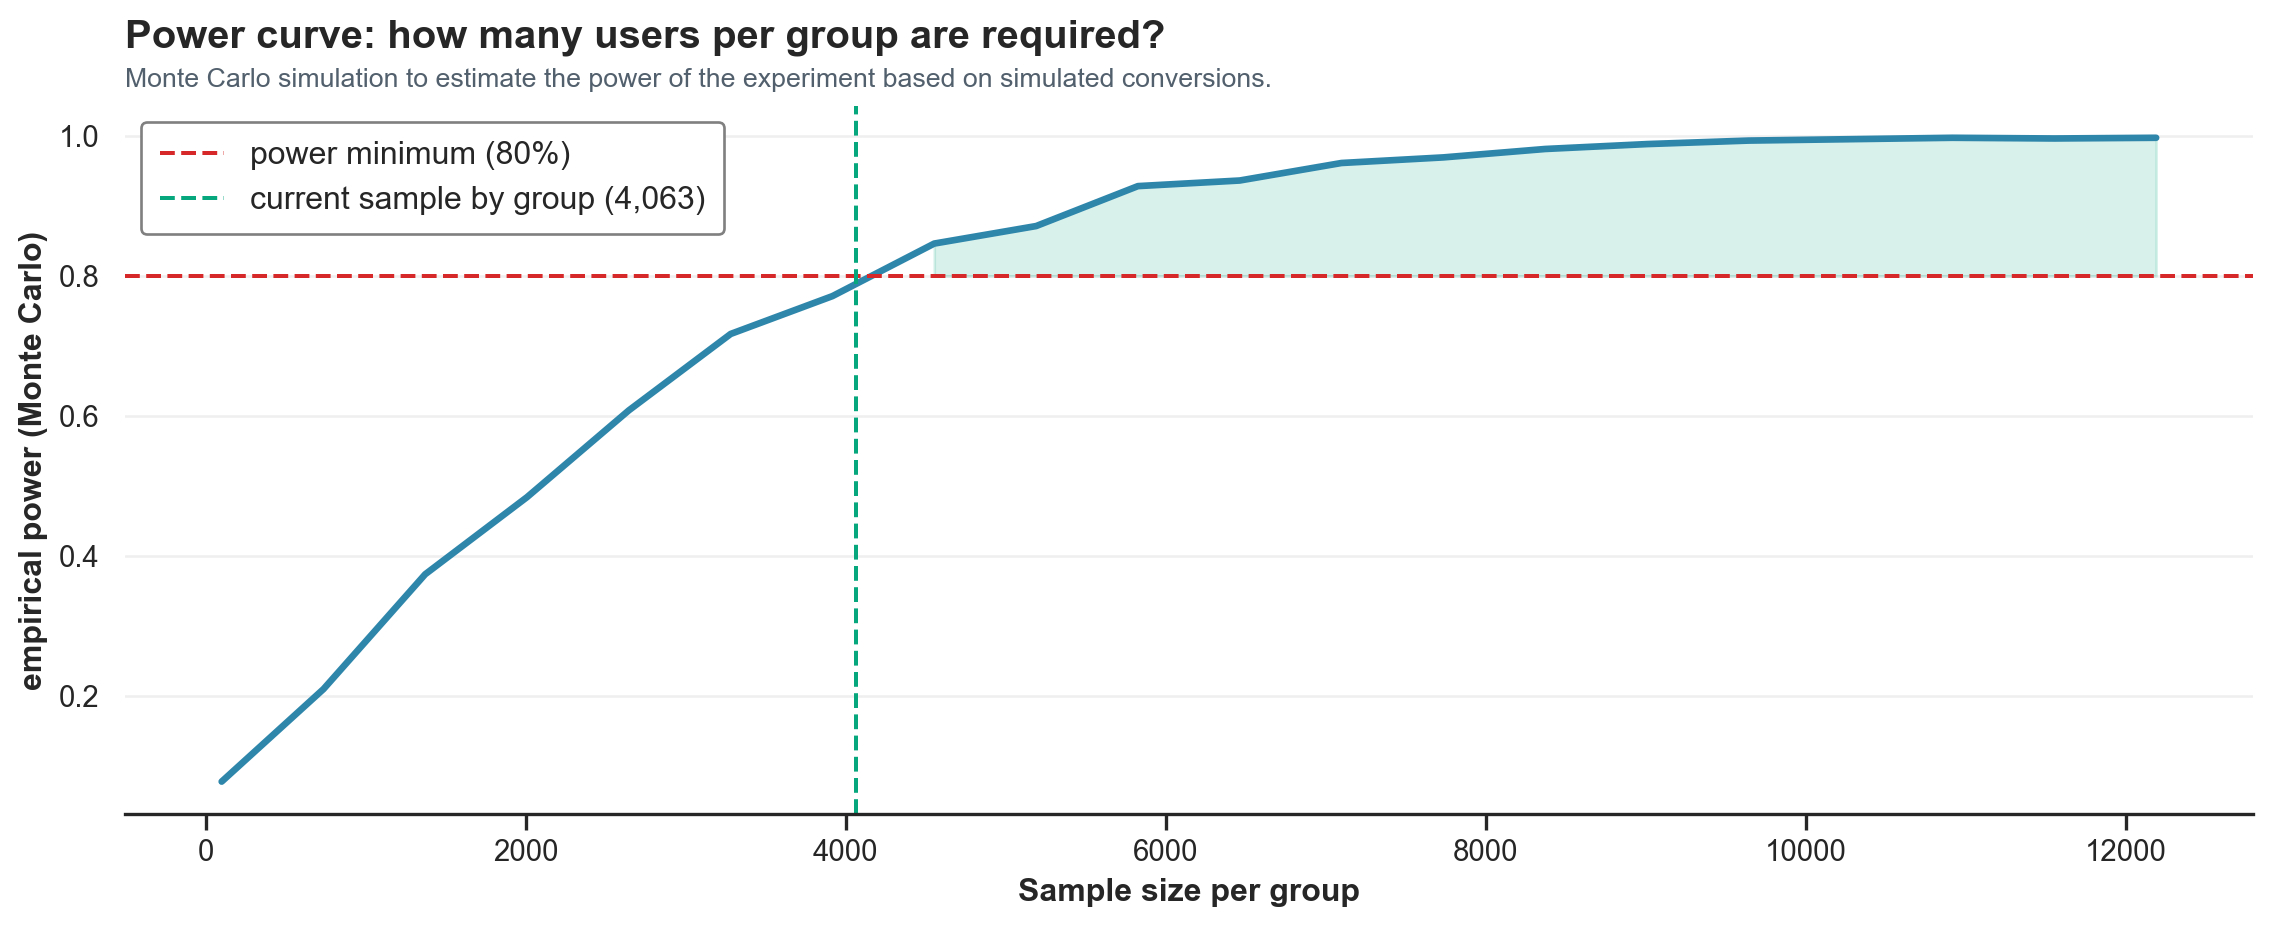


Empirical power with 4,063 per group: 79.2%


In [19]:
# MONTE CARLO: Synthetic population simulation for power analysis.
# Objective: estimate the real power of the experiment with observed parameters,
# without depending on the real sample size.


import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

mc_n_simulations = int(globals().get("MC_N_SIMULATIONS", 10_000))
MC_SAMPLE_PER_GROUP = required_n_per_group

# Parameters observed in the real data
p_control = BASELINE_CONVERSION
p_treatment = min(BASELINE_CONVERSION + MINIMUM_LIFT_PP / 100, 0.999)

# Simulation: generate mc_n_simulations experiments and count H0 rejections
rng = np.random.default_rng(RANDOM_STATE)
rejections = 0

for _ in range(mc_n_simulations):
    ctrl = rng.binomial(1, p_control, MC_SAMPLE_PER_GROUP)
    trt = rng.binomial(1, p_treatment, MC_SAMPLE_PER_GROUP)

    n_ctrl, n_trt = len(ctrl), len(trt)
    conv_ctrl, conv_trt = ctrl.sum(), trt.sum()

    if conv_ctrl == 0 and conv_trt == 0:
        continue

    try:
        _, p_val = proportions_ztest(
            [conv_ctrl, conv_trt], [n_ctrl, n_trt]
        )
        if p_val < ALPHA:
            rejections += 1
    except Exception:
        continue

empirical_power = rejections / mc_n_simulations

mc_summary = pd.DataFrame({
    "Parameter": [
        "Conversion baseline (control)",
        "Expected conversion (treatment)",
        "Simulated minimum lift",
        "Sample size per group",
        "Number of simulations",
        "Estimated empirical power",
        "Interpretation",
    ],
    "Value": [
        f"{p_control * 100:.2f}%",
        f"{p_treatment * 100:.2f}%",
        f"{MINIMUM_LIFT_PP:.1f} p.p.",
        f"{MC_SAMPLE_PER_GROUP:,}",
        f"{mc_n_simulations:,}",
        f"{empirical_power:.1%}",
        "Adequate (>= 80%)" if empirical_power >= 0.80
        else "Insufficient - increase MINIMUM_LIFT_PP or sample size",
],
})
display(mc_summary)

sample_sizes = np.linspace(100, MC_SAMPLE_PER_GROUP * 3, 20, dtype=int)
power_curve = []

for n in sample_sizes:
    rej = 0
    for _ in range(1_000):
        ctrl = rng.binomial(1, p_control, n)
        trt = rng.binomial(1, p_treatment, n)
        try:
            _, pv = proportions_ztest([ctrl.sum(), trt.sum()], [n, n])
            if pv < ALPHA:
                rej += 1
        except Exception:
            pass
    power_curve.append(rej / 1_000)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample_sizes, power_curve, color="#2E86AB", linewidth=2.5)
ax.axhline(0.80, color="#D62828", linestyle="--", linewidth=1.5,
        label="power minimum (80%)")
ax.axvline(MC_SAMPLE_PER_GROUP, color="#06A77D", linestyle="--", linewidth=1.5,
        label=f"current sample by group ({MC_SAMPLE_PER_GROUP:,})")
ax.fill_between(sample_sizes, power_curve, 0.80,
                where=[p >= 0.80 for p in power_curve],
                alpha=0.15, color="#06A77D")
ax.set_xlabel("Sample size per group", fontweight="bold")
ax.set_ylabel("empirical power (Monte Carlo)", fontweight="bold")
#ax.set_title("Power curve: how many users per group are required?",
#            fontweight="bold")
add_titles(ax, "Power curve: how many users per group are required?", 
        subtitle="Monte Carlo simulation to estimate the power of the experiment based on simulated conversions.")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEmpirical power with {MC_SAMPLE_PER_GROUP:,} per group: {empirical_power:.1%}")

In [20]:
from IPython.display import Markdown

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### A/B Test Insight: personalization vs control
</span>

The experiment design was defined above. The hypothesis: customized campaigns generate higher conversion rates than the control group with statistical significance and sufficient magnitude (>= {MINIMUM_LIFT_PP:.1f} p.p. of lift) to justify operational cost.
"""))


<span style="color:steelblue; text-align: left">

### A/B Test Insight: personalization vs control
</span>

The experiment design was defined above. The hypothesis: customized campaigns generate higher conversion rates than the control group with statistical significance and sufficient magnitude (>= 2.0 p.p. of lift) to justify operational cost.


<span style="color:steelblue; text-align: left">

### Sufficiency Check: Monte Carlo -> Real Test
</span>

Monte Carlo estimated empirical power based on `required_n_per_group` from power analysis. Before running the real test, we check whether available sample per variant in `df_clean` satisfies this requirement.

If real sample is below requirement, the test can still run - but with lower power, increasing the risk of missing a true effect (Type II error).



,Variant,Available users,Required (power analysis),Sufficient?,Estimated power,Gap (users)
0,control,4932,4063,✓ Yes,79.2%,0
1,personalization,4825,4063,✓ Yes,79.2%,0



  PRE-TEST DECISION
  ✓ Sufficient sample across all variants.
    Smallest group: 4,825 users (required: 4,063).
    Empirical power (Monte Carlo): 79.2%
    Proceed with run_ab_test(df_clean).


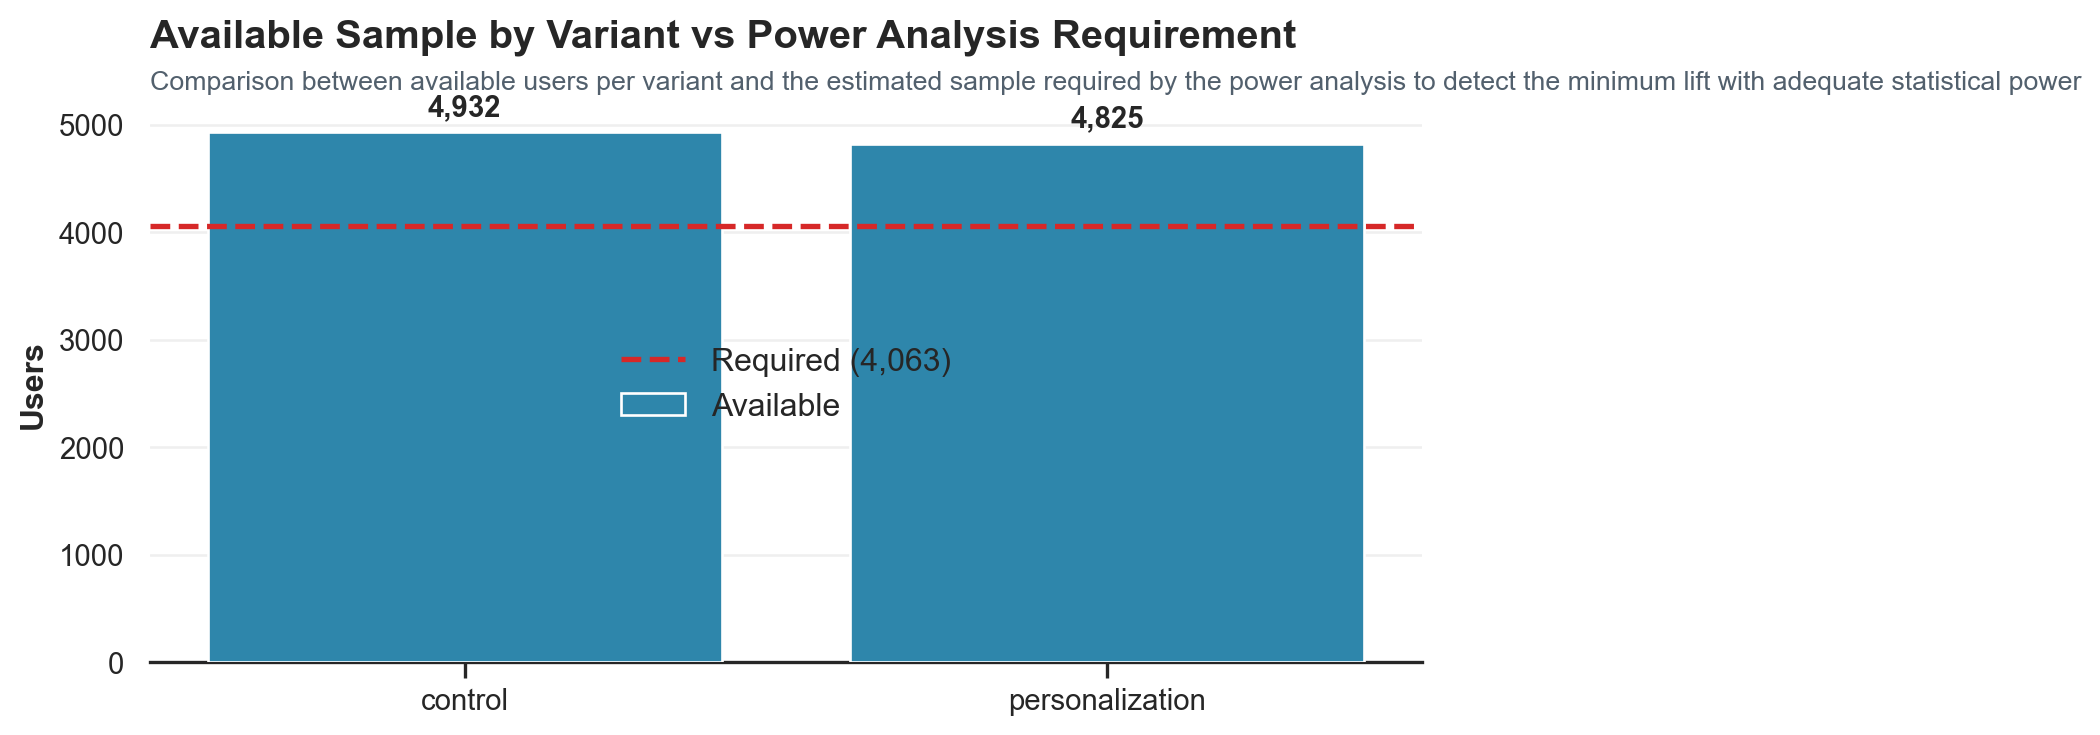

In [21]:
# MONTE CARLO -> REAL TEST CONNECTION
# Check whether the available sample per variant is sufficient
# before running the A/B test with real data.

# -- 1. Real sample count by variant --------------------------------------
variant_counts = df_clean["variant"].value_counts().sort_index()
n_variants = variant_counts.shape[0]
min_real = int(variant_counts.min())
max_real = int(variant_counts.max())

# -- 2. Power analysis and Monte Carlo parameters -------------------------
req_n = int(globals().get("required_n_per_group", 0))
emp_power = float(globals().get("empirical_power", float("nan")))
runtime = int(globals().get("runtime_days", 0))

# -- 3. Sample adequacy verification by variant ---------------------------
adequacy_rows = []

for variant, count in variant_counts.items():
    n = int(count)
    sufficient = n >= req_n

    if req_n > 0:
        power_fraction = min(n / req_n, 1.0)

        # Conservative linear estimate of available statistical power
        estimated_power = (
            emp_power * power_fraction
            if not __import__("math").isnan(emp_power)
            else float("nan")
        )
    else:
        power_fraction = float("nan")
        estimated_power = float("nan")

    adequacy_rows.append({
        "Variant": str(variant),
        "Available users": n,
        "Required (power analysis)": req_n if req_n > 0 else "N/A",
        "Sufficient?": "✓ Yes" if sufficient else "✗ No",
        "Estimated power": (
            f"{estimated_power:.1%}"
            if not __import__("math").isnan(estimated_power)
            else "N/A"
        ),
        "Gap (users)": (
            max(req_n - n, 0)
            if req_n > 0 else "N/A"
        ),
    })

adequacy_df = pd.DataFrame(adequacy_rows)
display(adequacy_df)

# -- 4. Decision summary ---------------------------------------------------
all_sufficient = min_real >= req_n if req_n > 0 else True

print("\n" + "=" * 65)
print("  PRE-TEST DECISION")
print("=" * 65)

if req_n == 0:
    print("  ⚠ Power analysis was not executed - missing required_n_per_group.")
    print("    Run Cell 27 before proceeding.")

elif all_sufficient:
    print("  ✓ Sufficient sample across all variants.")
    print(
        f"    Smallest group: {min_real:,} users "
        f"(required: {req_n:,})."
    )

    if not __import__("math").isnan(emp_power):
        print(f"    Empirical power (Monte Carlo): {emp_power:.1%}")

    print("    Proceed with run_ab_test(df_clean).")

else:
    deficit = req_n - min_real

    print("  ✗ Insufficient sample.")
    print(
        f"    Smallest group: {min_real:,} users "
        f"(required: {req_n:,}, deficit: {deficit:,})."
    )

    if not __import__("math").isnan(emp_power):
        power_avail = emp_power * (min_real / req_n)

        print(
            f"    Estimated power with current sample: "
            f"~{power_avail:.1%} (target: {emp_power:.1%})"
        )

    if runtime > 0:
        print(
            f"    Estimated time to reach required sample: "
            f"{runtime} days."
        )

    print()
    print("  Options:")
    print("    1. Wait for more data (recommended for production).")
    print("    2. Increase MINIMUM_LIFT_PP to reduce required_n.")
    print("    3. Proceed acknowledging reduced statistical power (exploratory only).")

    import warnings

    warnings.warn(
        f"Real sample ({min_real:,}) is smaller than "
        f"required_n_per_group ({req_n:,}). "
        f"Test power may be lower than the Monte Carlo "
        f"estimate ({emp_power:.1%}).",
        UserWarning,
        stacklevel=1,
    )

print("=" * 65)

# -- 5. Comparison chart: available vs required ---------------------------
fig, ax = plt.subplots(figsize=(10, 4))

x = range(n_variants)

bars_r = ax.bar(
    x,
    variant_counts.values,
    color="#2E86AB",
    label="Available",
    zorder=3,
)

ax.axhline(
    req_n,
    color="#D62828",
    linestyle="--",
    linewidth=2,
    label=f"Required ({req_n:,})",
    zorder=4,
)

# Highlight insufficient variants in red
for bar, count in zip(bars_r, variant_counts.values):
    if req_n > 0 and int(count) < req_n:
        bar.set_color("#D62828")
        bar.set_alpha(0.7)

# Labels on bars
for bar, count in zip(bars_r, variant_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(variant_counts.values) * 0.02,
        f"{int(count):,}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

ax.set_xticks(list(x))
ax.set_xticklabels(
    variant_counts.index.tolist(),
    fontsize=11,
)

ax.set_ylabel("Users", fontweight="bold")

add_titles(
    ax,
    "Available Sample by Variant vs Power Analysis Requirement",
    subtitle=(
        "Comparison between available users per variant and "
        "the estimated sample required by the power analysis "
        "to detect the minimum lift with adequate statistical power"
    ),
)

ax.legend(loc="center", frameon=False)

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)


A/B TEST - PROPORTIONS Z-TEST

 A/B TEST - CONVERSION
--------------------------------------------------------------------------------


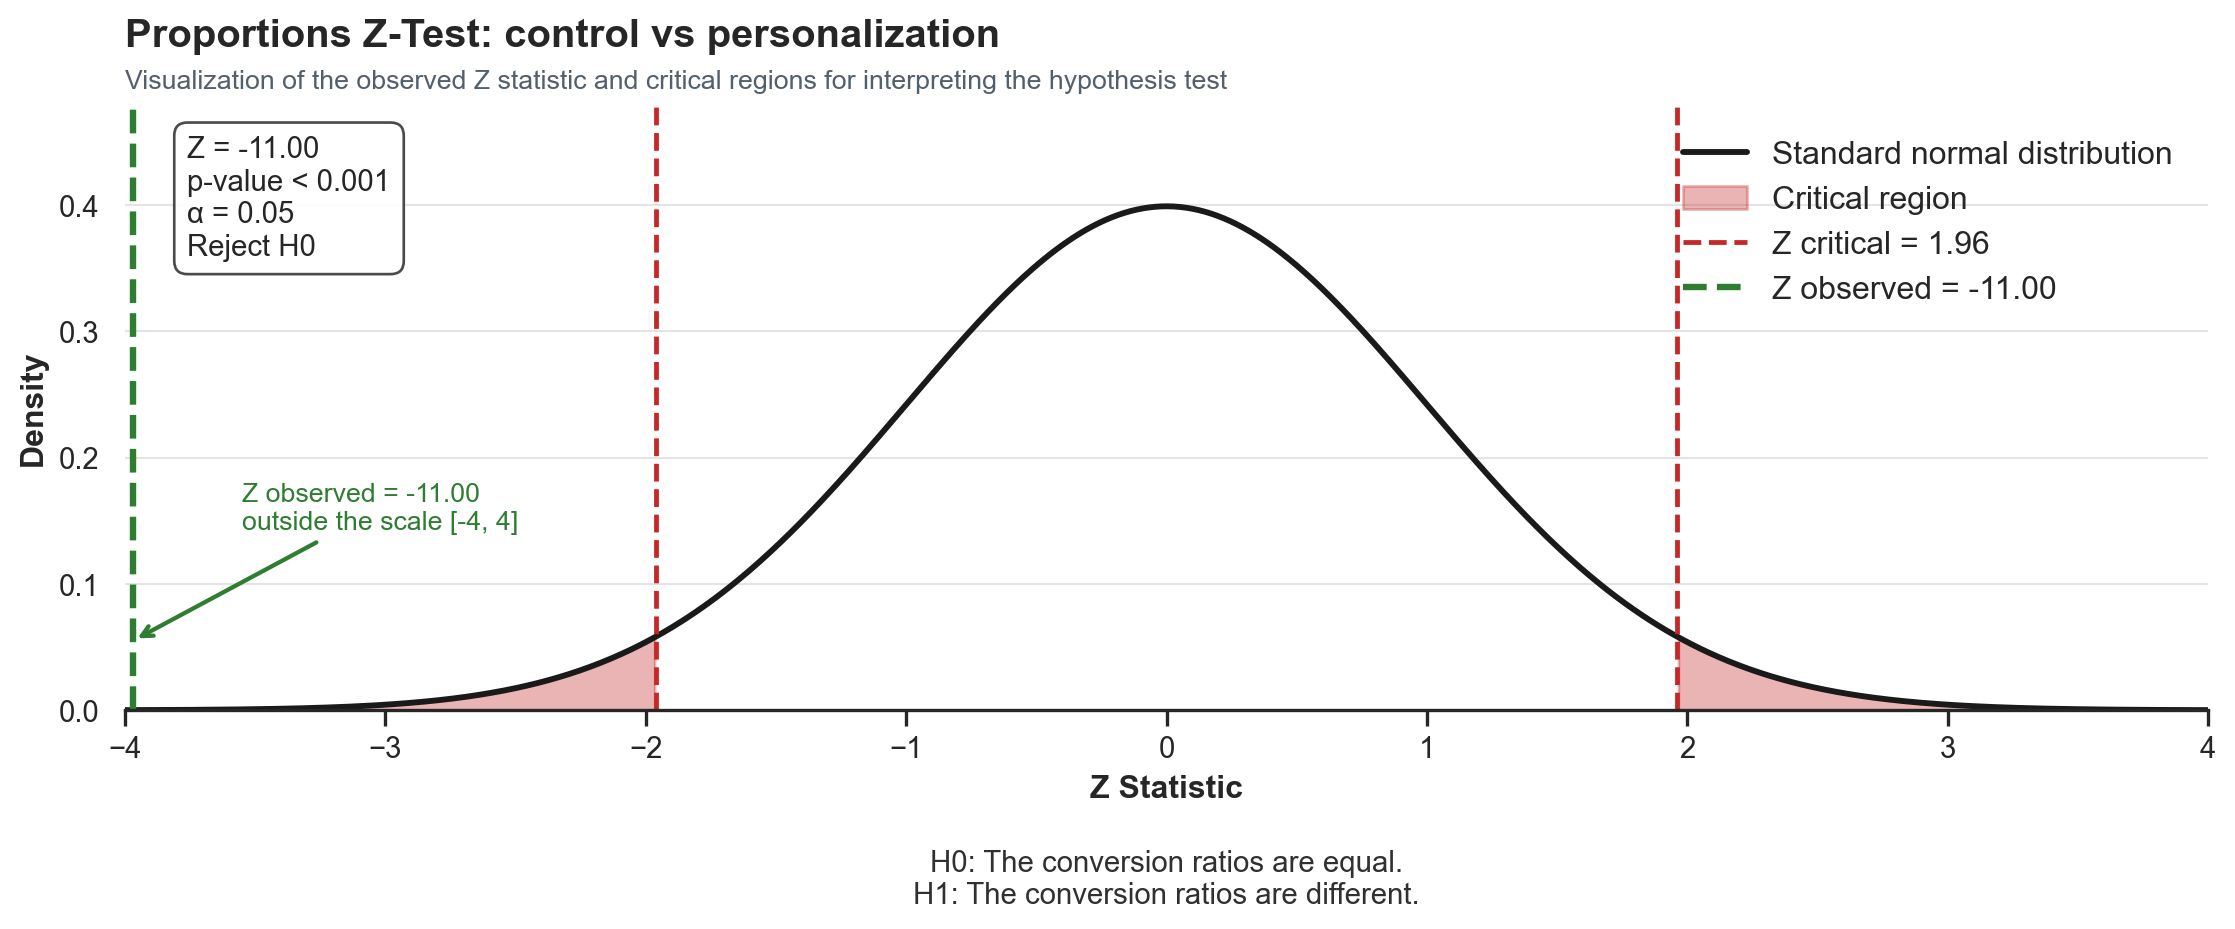


Z-TEST RESULT
Z Statistic: -10.9983
Critical Value: 1.96
P-value: 0.000000

Conclusion:
There are statistically significant evidence to reject H0.

EFFECT SIZE - conversion
Rate control: 7.34%
Rate personalization: 14.24%
Absolute difference (personalization - control): 6.90 p.p.
Percentage Uplift: 93.99%
IC 95% of difference: [5.67, 8.12] p.p.


,Variant_A,Variant_B,Conv_A_%,Conv_B_%,Z_Stat,P_Value,Significance,Effect_%,Diff_B_vs_A_pp,Uplift_B_vs_A_%,IC95_Diff_B_vs_A_pp
0,control,personalization,7.34,14.24,-11.00,0.00,? YES,-6.90,6.90,93.99,"[5.67, 8.12]"


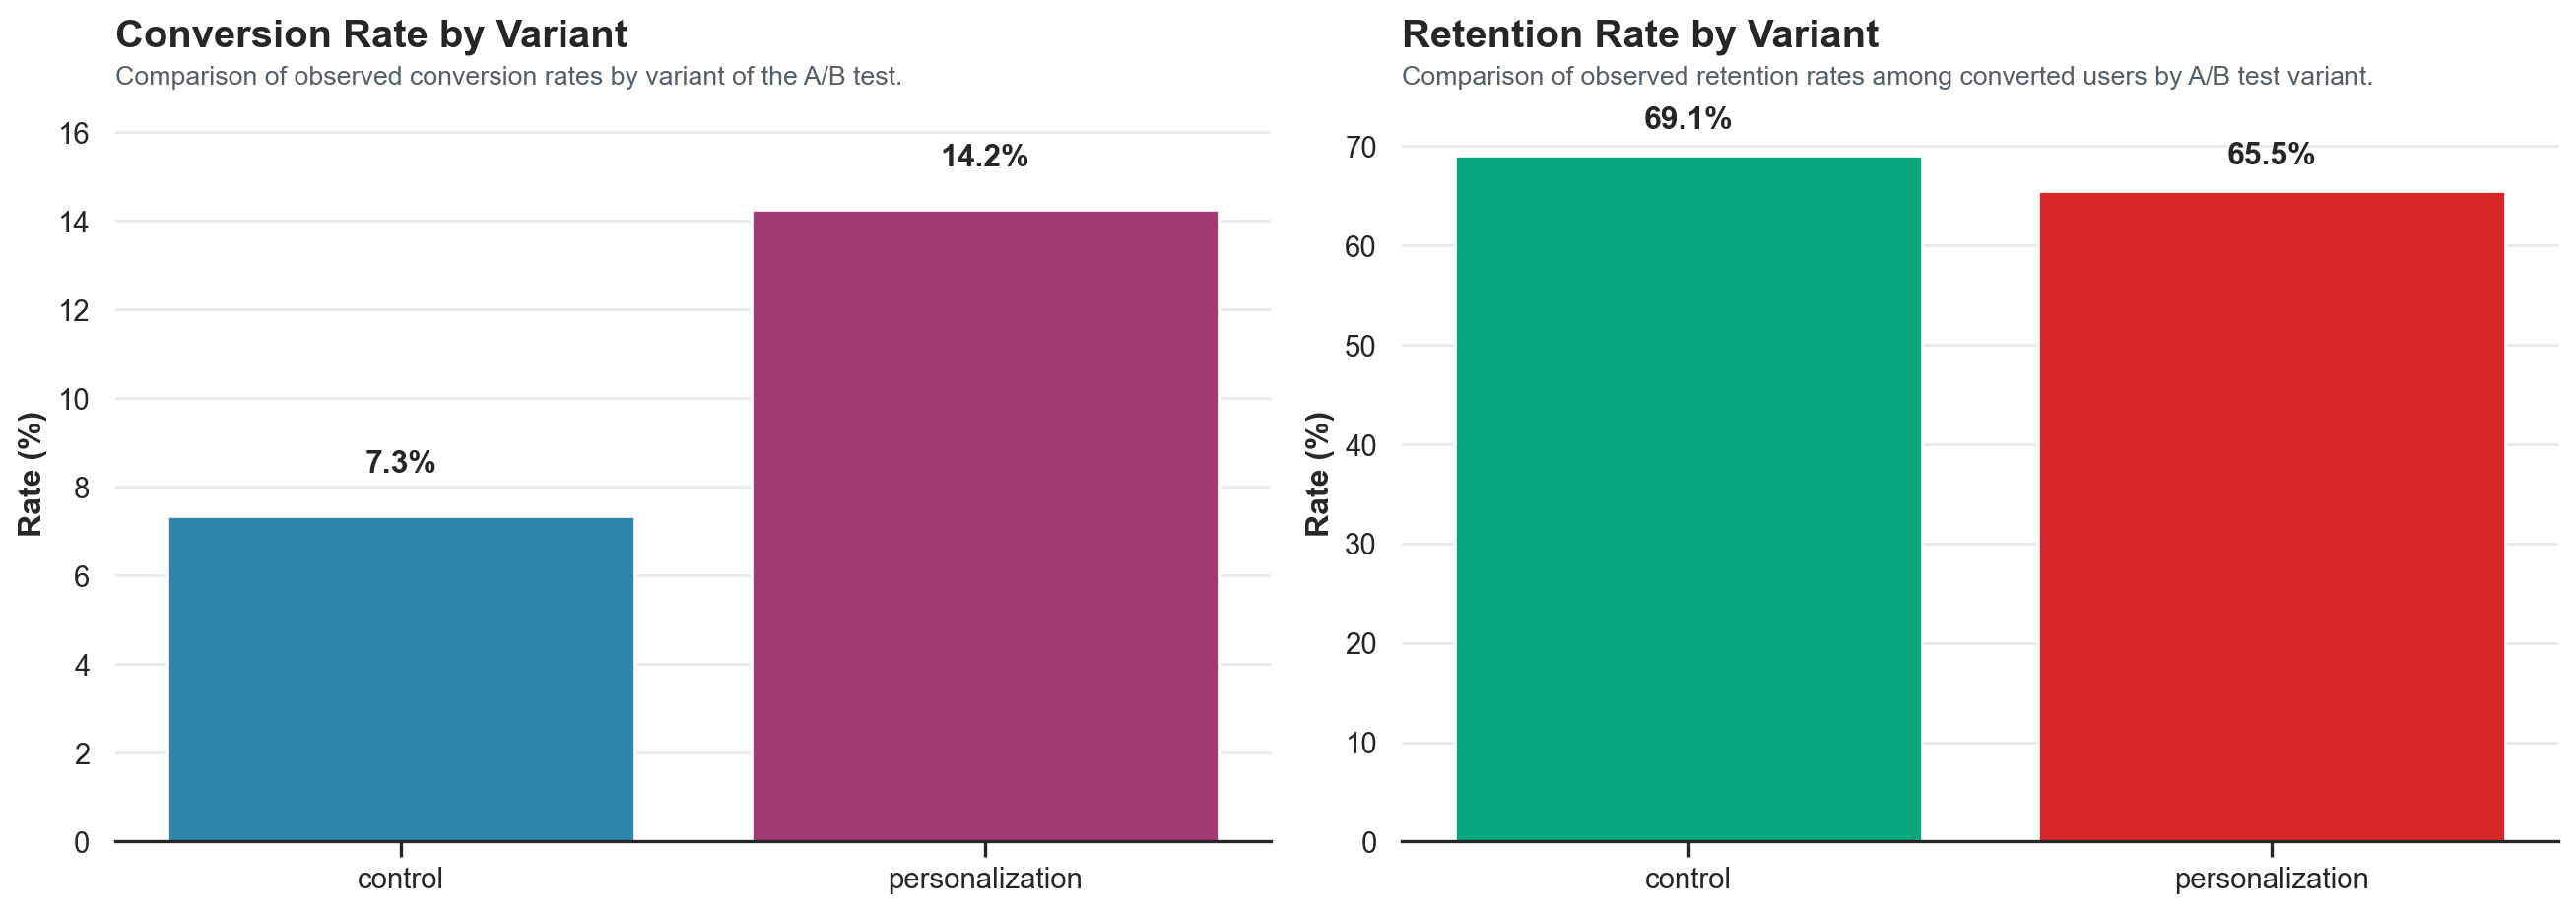

A/B test completed


In [22]:
def plot_z_test_distribution(
    z_stat: float,
    alpha: float = 0.05,
    alternative: str = "two-sided",
    title: Optional[str] = None,
    p_value: Optional[float] = None,
    h0_text: Optional[str] = None,
    h1_text: Optional[str] = None,
) -> None:
    """Plot the standard normal distribution for interpretation of the Z-test."""
    from scipy import stats

    valid_alternatives = {"two-sided", "greater", "less"}
    alternative = alternative.lower()

    if alternative not in valid_alternatives:
        raise ValueError(
            "alternative should be 'two-sided', 'greater' or 'less'."
        )

    if p_value is None:
        if alternative == "two-sided":
            p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        elif alternative == "greater":
            p_value = 1 - stats.norm.cdf(z_stat)
        else:
            p_value = stats.norm.cdf(z_stat)

    p_value = float(p_value)
    x = np.linspace(-4, 4, 1_000)
    y = stats.norm.pdf(x)

    fig, ax = plt.subplots(figsize=(14, 5))
    critical_color = "#C62828"
    observed_color = "#2E7D32"

    ax.plot(
        x,
        y,
        color="#1A1A1A",
        linewidth=2.2,
        label="Standard normal distribution",
    )

    if alternative == "two-sided":
        z_crit = stats.norm.ppf(1 - alpha / 2)
        lower_crit = -z_crit
        upper_crit = z_crit

        left_tail = x <= lower_crit
        right_tail = x >= upper_crit

        ax.fill_between(
            x[left_tail],
            y[left_tail],
            color=critical_color,
            alpha=0.35,
            label="Critical region",
        )
        ax.fill_between(
            x[right_tail],
            y[right_tail],
            color=critical_color,
            alpha=0.35,
        )
        ax.axvline(
            lower_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
            label=f"Z critical = {z_crit:.2f}",
        )
        ax.axvline(
            upper_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
        )
        critical_label = f"{z_crit:.2f}"
    elif alternative == "greater":
        z_crit = stats.norm.ppf(1 - alpha)
        right_tail = x >= z_crit

        ax.fill_between(
            x[right_tail],
            y[right_tail],
            color=critical_color,
            alpha=0.35,
            label="Critical region",
        )
        ax.axvline(
            z_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
            label=f"Z critical = {z_crit:.2f}",
        )
        critical_label = f"{z_crit:.2f}"
    else:
        z_crit = stats.norm.ppf(alpha)
        left_tail = x <= z_crit

        ax.fill_between(
            x[left_tail],
            y[left_tail],
            color=critical_color,
            alpha=0.35,
            label="Critical region",
        )
        ax.axvline(
            z_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
            label=f"Z critical = {z_crit:.2f}",
        )
        critical_label = f"{z_crit:.2f}"

    x_min, x_max = -4, 4
    z_plot = float(np.clip(z_stat, x_min + 0.03, x_max - 0.03))
    z_outside_scale = not np.isclose(z_plot, z_stat)

    ax.axvline(
        z_plot,
        color=observed_color,
        linestyle="--",
        linewidth=2.4,
        label=f"Z observed = {z_stat:.2f}",
    )

    if z_outside_scale:
        if z_stat < x_min:
            text_x = -3.55
            ha = "left"
        else:
            text_x = 3.55
            ha = "right"

        ax.annotate(
            f"Z observed = {z_stat:.2f}\noutside the scale [-4, 4]",
            xy=(z_plot, 0.055),
            xytext=(text_x, 0.16),
            ha=ha,
            va="center",
            fontsize=10,
            color=observed_color,
            arrowprops={
                "arrowstyle": "->",
                "color": observed_color,
                "linewidth": 1.6,
            },
        )

    decision = "Reject H0" if p_value < alpha else "Fail to reject H0"
    p_value_label = (
        "p-value < 0.001" if p_value < 0.001 else f"p-value = {p_value:.4f}"
    )
    annotation = (
        f"Z = {z_stat:.2f}\n"
        f"{p_value_label}\n"
        f"α = {alpha:.2f}\n"
        f"{decision}"
    )

    ax.text(
        0.03,
        0.95,
        annotation,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=11,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": "#404040",
            "alpha": 0.94,
        },
    )

    h0_text = h0_text or "H0: The conversion rates are equal"
    h1_text = h1_text or "H1: The conversion rates are different"
    hypotheses = f"{h0_text}\n{h1_text}"

    ax.text(
        0.5,
        -0.23,
        hypotheses,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        color="#303030",
    )

    '''ax.set_title(
        title or "Standard Normal Distribution for Z-Test",
        fontsize=15,
        fontweight="bold",
        pad=16,
    )'''
    
    add_titles(ax, title or "Standard Normal Distribution for Z-Test",
        subtitle="Visualization of the observed Z statistic and critical regions for interpreting the hypothesis test")
    
    ax.set_xlabel("Z Statistic", fontweight="bold")
    ax.set_ylabel("Density", fontweight="bold")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y.max() * 1.20)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.8, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=False)

    plt.subplots_adjust(bottom=0.25)
    plt.show()
    plt.close(fig)

    print("\n" + "=" * 70)
    print("Z-TEST RESULT")
    print("=" * 70)
    print(f"Z Statistic: {z_stat:.4f}")
    print(f"Critical Value: {critical_label}")
    print(f"P-value: {p_value:.6f}")
    print("\nConclusion:")

    if p_value < alpha:
        print("There are statistically significant evidence to reject H0.")
    else:
        print("There is not enough evidence to reject H0.")


def run_ab_test(df: pd.DataFrame) -> pd.DataFrame:
    """Run A/B test using proportions z-test."""
    print("\n" + "=" * 80)
    print("A/B TEST - PROPORTIONS Z-TEST")
    print("=" * 80)

    if "variant" not in df.columns or df["variant"].nunique() < 2:
        print("The A/B test cannot be executed.")
        return pd.DataFrame()

    variants = df["variant"].unique()
    ab_results = []
    main_comparison_plotted = False

    print("\n A/B TEST - CONVERSION")
    print("-" * 80)

    for variant_a in variants:
        for variant_b in variants:
            if variant_a >= variant_b:
                continue

            conv_a = df[df["variant"] == variant_a]["converted_flag"].sum()
            count_a = df[df["variant"] == variant_a].shape[0]
            conv_b = df[df["variant"] == variant_b]["converted_flag"].sum()
            count_b = df[df["variant"] == variant_b].shape[0]

            rate_a = conv_a / count_a
            rate_b = conv_b / count_b

            z_stat, p_value = proportions_ztest(
                [int(conv_a), int(conv_b)], [int(count_a), int(count_b)]
            )

            sig = "? YES" if p_value < 0.05 else "? NO"
            effect = (rate_a - rate_b) * 100
            diff_b_vs_a = rate_b - rate_a
            uplift_b_vs_a = (
                (diff_b_vs_a / rate_a) * 100 if rate_a > 0 else np.nan
            )
            se_diff = np.sqrt(
                (rate_a * (1 - rate_a) / count_a)
                + (rate_b * (1 - rate_b) / count_b)
            )
            ci_low_pp = (diff_b_vs_a - 1.96 * se_diff) * 100
            ci_high_pp = (diff_b_vs_a + 1.96 * se_diff) * 100

            ab_results.append({
                "Variant_A": variant_a,
                "Variant_B": variant_b,
                "Conv_A_%": round(rate_a * 100, 2),
                "Conv_B_%": round(rate_b * 100, 2),
                "Z_Stat": round(z_stat, 4),
                "P_Value": round(p_value, 6),
                "Significance": sig,
                "Effect_%": round(effect, 2),
                "Diff_B_vs_A_pp": round(diff_b_vs_a * 100, 2),
                "Uplift_B_vs_A_%": round(uplift_b_vs_a, 2),
                "IC95_Diff_B_vs_A_pp": (
                    f"[{ci_low_pp:.2f}, {ci_high_pp:.2f}]"
                ),
            })

            comparison = {str(variant_a).lower(), str(variant_b).lower()}
            is_main_comparison = comparison == {"control", "personalization"}

            if is_main_comparison and not main_comparison_plotted:
                plot_z_test_distribution(
                    z_stat=z_stat,
                    alpha=ALPHA,
                    alternative="two-sided",
                    title=(
                        "Proportions Z-Test: "
                        f"{variant_a} vs {variant_b}"
                    ),
                    p_value=p_value,
                    h0_text=(
                        "H0: The conversion ratios are equal."
                    ),
                    h1_text=(
                        "H1: The conversion ratios are different."
                    ),
                )

                print("\n" + "=" * 80)
                print("EFFECT SIZE - conversion")
                print("=" * 80)
                print(f"Rate {variant_a}: {rate_a * 100:.2f}%")
                print(f"Rate {variant_b}: {rate_b * 100:.2f}%")
                print(
                    "Absolute difference "
                    f"({variant_b} - {variant_a}): "
                    f"{diff_b_vs_a * 100:.2f} p.p."
                )
                print(f"Percentage Uplift: {uplift_b_vs_a:.2f}%")
                print(
                    "IC 95% of difference: "
                    f"[{ci_low_pp:.2f}, {ci_high_pp:.2f}] p.p."
                )
                main_comparison_plotted = True

    ab_df = pd.DataFrame(ab_results)
    if not ab_df.empty:
        display(ab_df)

    # Descriptive complementary visualization.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    variant_stats = df.groupby("variant").agg({
        "converted_flag": ["sum", "count"]
    })
    variant_stats.columns = ["conversions", "total"]
    variant_stats["conv_rate"] = (
        variant_stats["conversions"] / variant_stats["total"] * 100
    )

    axes[0].bar(
        variant_stats.index,
        variant_stats["conv_rate"],
        color=["#2E86AB", "#A23B72"][:len(variant_stats)],
    )
    axes[0].set_ylabel("Rate (%)", fontweight="bold")
    #axes[0].set_title("Conversion Rate by Variant", fontweight="bold")
    add_titles(axes[0], "Conversion Rate by Variant",
        subtitle="Comparison of observed conversion rates by variant of the A/B test.")
    conv_max = float(variant_stats["conv_rate"].max())
    conv_label_offset = max(conv_max * 0.06, 0.8)
    axes[0].set_ylim(0, conv_max + conv_label_offset * 2.8)
    for i, v in enumerate(variant_stats["conv_rate"]):
        axes[0].text(
            i,
            v + conv_label_offset,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ret_stats = (
        df[df["converted_flag"] == 1]
        .groupby("variant")["retained_flag"]
        .agg(["sum", "count"])
    )
    ret_stats.columns = ["retained", "converted"]
    ret_stats["ret_rate"] = (
        ret_stats["retained"] / ret_stats["converted"] * 100
    )

    axes[1].bar(
        ret_stats.index,
        ret_stats["ret_rate"],
        color=["#06A77D", "#D62828"][:len(ret_stats)],
    )
    axes[1].set_ylabel("Rate (%)", fontweight="bold")
    #axes[1].set_title("Retention Rate by Variant", fontweight="bold")
    add_titles(axes[1], "Retention Rate by Variant",
        subtitle="Comparison of observed retention rates among converted users by A/B test variant.")
    ret_max = float(ret_stats["ret_rate"].max())
    ret_label_offset = max(ret_max * 0.03, 0.8)
    axes[1].set_ylim(0, ret_max + ret_label_offset * 2.5)
    for i, v in enumerate(ret_stats["ret_rate"]):
        axes[1].text(
            i,
            v + ret_label_offset,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()
    plt.close()

    print("A/B test completed")
    return ab_df


ab_test_summary = run_ab_test(df_clean)

In [23]:
from IPython.display import Markdown

incremental_value = float(
    globals().get(
        "incremental_value",
        max(df_clean["user_id"].nunique(), 1) * REVENUE_PER_CONVERSION * 0.01,
    )
)

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Inferential Insight from Z-Test

</span>

> **What it shows:** The Z-test evaluates whether the personalization variant
> produces a statistically significant difference compared to the control group.
>
> **Why it matters:** Statistical significance does not necessarily imply
> practical relevance. It is also necessary to verify whether the lift magnitude
> (>= {MINIMUM_LIFT_PP:.1f} p.p.) justifies the operational cost.
>
> **Recommended action:** If p < 0.05 and lift >= {MINIMUM_LIFT_PP:.1f} p.p.,
> launch the campaign; otherwise, revisit the experimental design or increase
> the sample size.
>
> **Business impact:** Each additional percentage point of lift may generate
> approximately \\$ {incremental_value:,.0f}, considering the current user base.
"""))



<span style="color:steelblue; text-align: left">

### Inferential Insight from Z-Test

</span>

> **What it shows:** The Z-test evaluates whether the personalization variant
> produces a statistically significant difference compared to the control group.
>
> **Why it matters:** Statistical significance does not necessarily imply
> practical relevance. It is also necessary to verify whether the lift magnitude
> (>= 2.0 p.p.) justifies the operational cost.
>
> **Recommended action:** If p < 0.05 and lift >= 2.0 p.p.,
> launch the campaign; otherwise, revisit the experimental design or increase
> the sample size.
>
> **Business impact:** Each additional percentage point of lift may generate
> approximately \$ 3,289, considering the current user base.


<span style="color:steelblue; text-align: left">

## ROI and Expected Value Simulation
</span>

This section provides a financial simulation to estimate channel-level economic return. The goal is to complement conversion and retention metrics with value-oriented insight for operational decisions.

Because the dataset does not include actual campaign costs or observed per-user revenue, we use business assumptions defined in project constants to estimate:

- total cost by channel;
- conversion-driven revenue;
- additional value from retention;
- estimated profit;
- estimated ROI.

This does not replace real financial measurement, but creates a practical framework to compare channel efficiency from an economic perspective.




ROI SIMULATION


,marketing_channel,impacted_users,conversions,total_cost,estimated_revenue,incremental_revenue,estimated_profit,roi_%,roi_incremental_%
0,Email,552,187,441.60,8375.18,7841.05,7933.58,1796.55,1675.60
3,Instagram,1726,243,2071.20,10912.81,9242.71,8841.61,426.88,346.25
1,Facebook,1744,227,2092.80,10193.22,8505.71,8100.42,387.06,306.43
2,House Ads,3911,298,3911.00,13361.82,9577.49,9450.82,241.65,144.89
4,Push,963,79,1155.60,3547.46,2615.65,2391.86,206.98,126.35



Estimated organic baseline: 20% of the current conversion rate.
Incremental ROI = gain attributable to the campaign beyond what would occur organically.


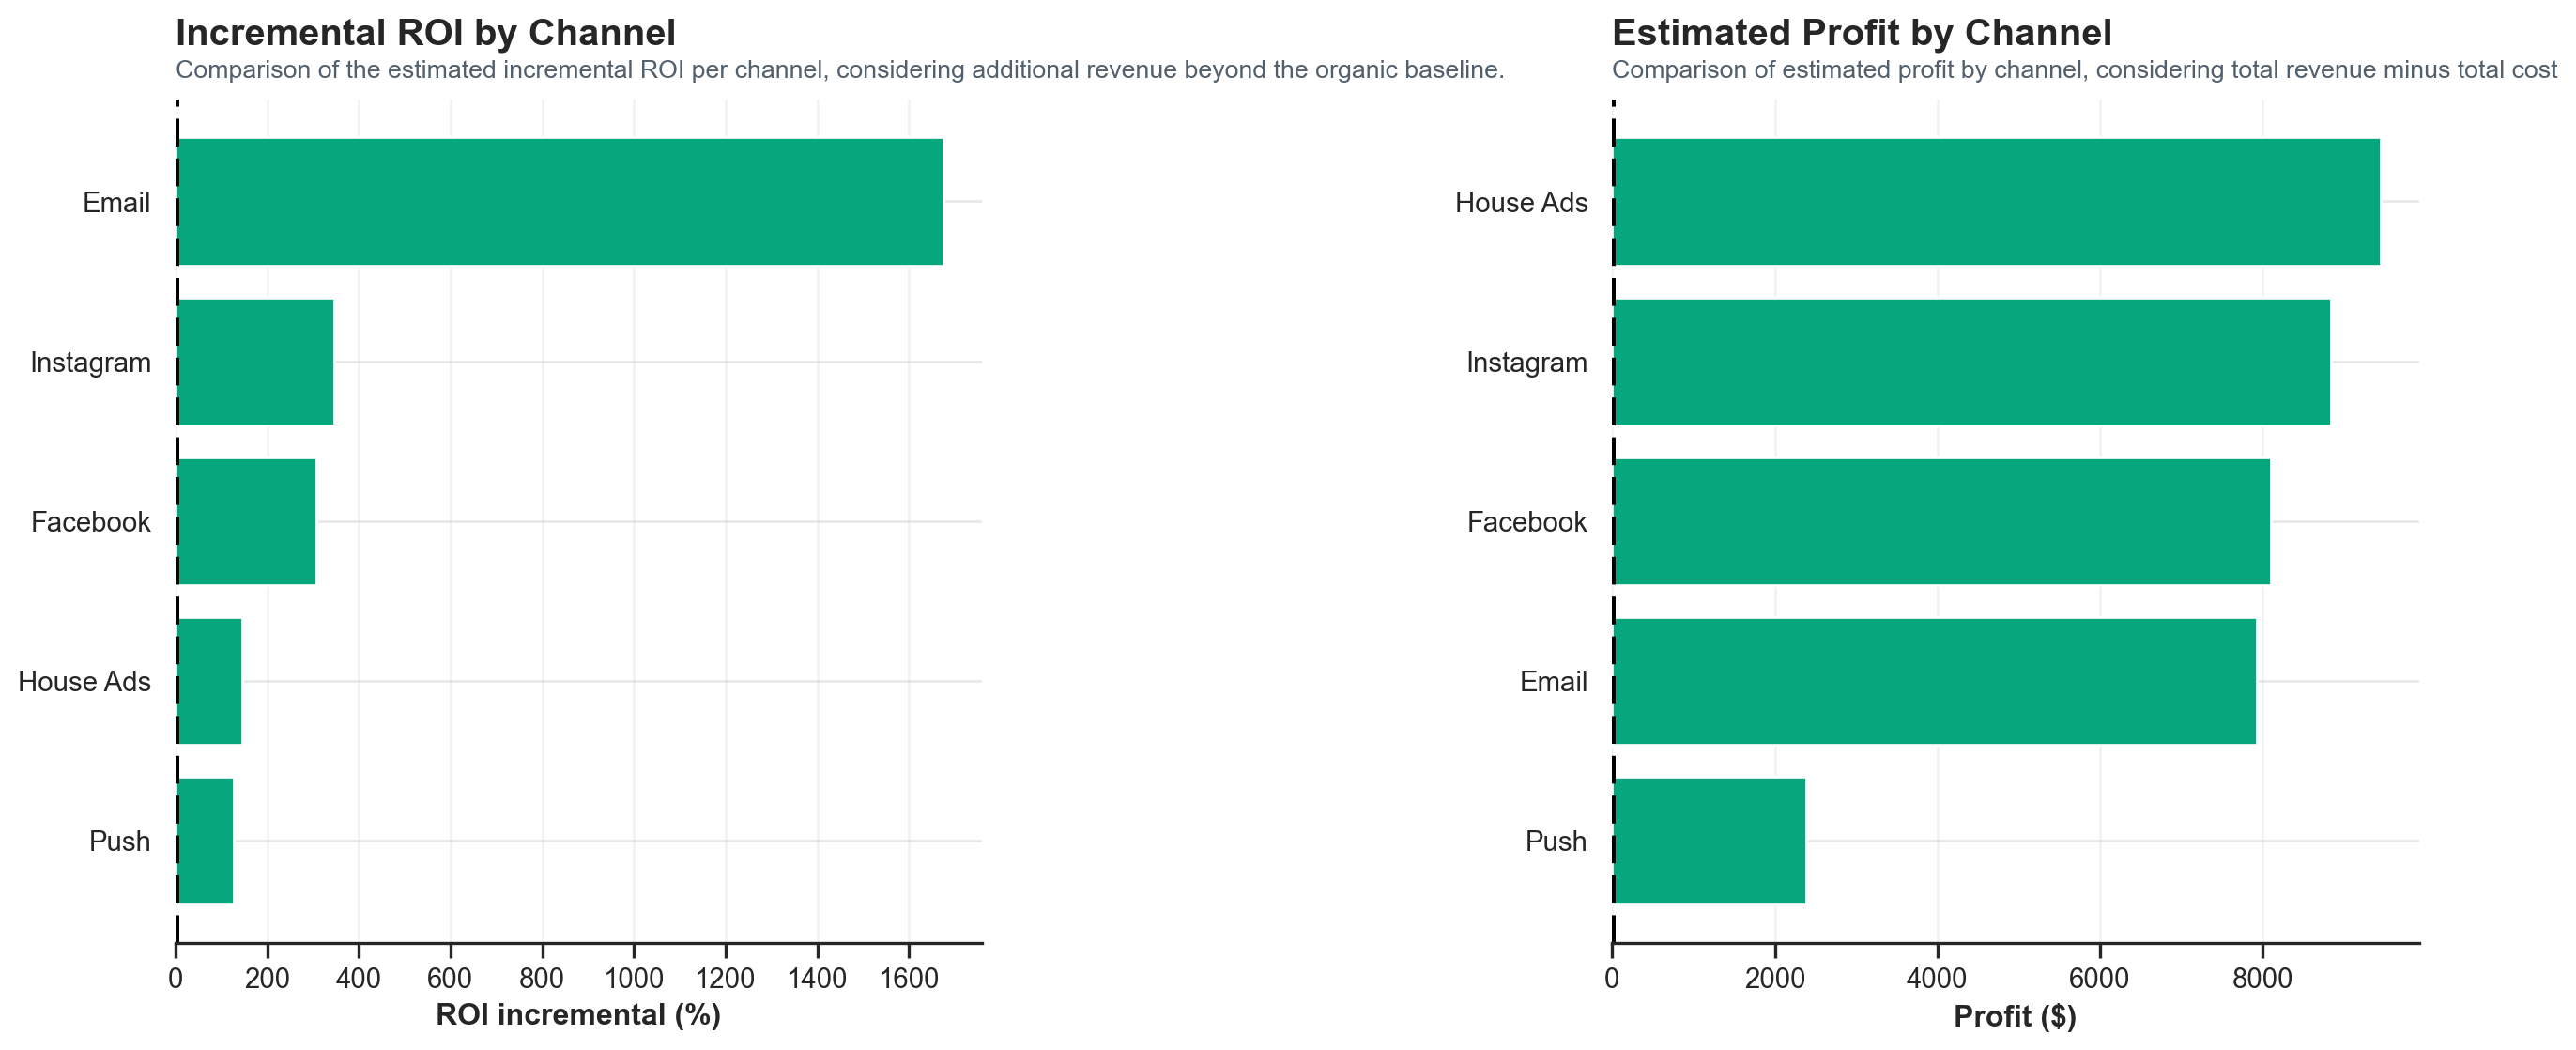

ROI simulation completed


In [24]:
def simulate_roi(
    channel_summary: pd.DataFrame,
    cost_dict: dict,
    revenue_per_conversion: float,
    customer_value: float,
) -> pd.DataFrame:
    """Simulate total and incremental ROI per channel."""
    print("\n" + "=" * 80)
    print("ROI SIMULATION")
    print("=" * 80)

    roi_summary = channel_summary.copy()
    roi_summary["total_cost"] = (
        roi_summary["marketing_channel"].map(cost_dict).fillna(DEFAULT_COST)
        * roi_summary["impacted_users"]
    )

    # C2: uses the median LTV of the majority segment of the channel when available.
    ltv_fallback = float(
        globals().get(
            "global_ltv",
            globals().get("ESTIMATED_CUSTOMER_VALUE", customer_value),
        )
    )
    if "ltv_by_customer" in globals() and not ltv_by_customer.empty:
        ltv_fallback = float(ltv_by_customer["historical_ltv"].mean())

    if "Segment" in df_clean.columns and "segment_ltv_map" in globals():
        channel_segment_map = (
            df_clean.dropna(subset=["Segment"])
            .groupby("marketing_channel")["Segment"]
            .agg(lambda values: values.mode().iloc[0])
        )
        roi_summary["majority_segment"] = roi_summary[
            "marketing_channel"
        ].map(channel_segment_map)
        roi_summary["ltv_reference"] = (
            roi_summary["majority_segment"].map(segment_ltv_map)
            .fillna(ltv_fallback)
        )
    else:
        roi_summary["majority_segment"] = "Not segmented"
        roi_summary["ltv_reference"] = ltv_fallback

    roi_summary["estimated_revenue"] = (
        roi_summary["conversions"] * revenue_per_conversion
        + roi_summary["retained"] * roi_summary["ltv_reference"] * 0.15
    )
    roi_summary["estimated_profit"] = (
        roi_summary["estimated_revenue"] - roi_summary["total_cost"]
    )
    roi_summary["roi_%"] = (
        roi_summary["estimated_profit"]
        / roi_summary["total_cost"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    # C5: baseline without marketing campaign.
    baseline_conversion = globals().get(
        "BASELINE_CONVERSION",
        df_clean["converted_flag"].mean(),
    )
    baseline_conversions = (
        roi_summary["impacted_users"]
        * baseline_conversion
        * ORGANIC_CONVERSION_RATE
    )
    baseline_revenue = baseline_conversions * revenue_per_conversion
    roi_summary["incremental_revenue"] = (
        roi_summary["estimated_revenue"] - baseline_revenue
    )
    roi_summary["roi_incremental_%"] = (
        (roi_summary["incremental_revenue"] - roi_summary["total_cost"])
        / roi_summary["total_cost"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    display_columns = [
        "marketing_channel",
        "impacted_users",
        "conversions",
        "total_cost",
        "estimated_revenue",
        "incremental_revenue",
        "estimated_profit",
        "roi_%",
        "roi_incremental_%",
    ]
    display(
        roi_summary[display_columns].sort_values(
            "roi_incremental_%",
            ascending=False,
        )
    )
    print(
        "\nEstimated organic baseline: "
        f"{ORGANIC_CONVERSION_RATE * 100:.0f}% of the current conversion rate."
    )
    print(
        "Incremental ROI = gain attributable to the campaign beyond what would occur organically."
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    roi_sorted = roi_summary.sort_values("roi_incremental_%", ascending=True)
    axes[0].barh(
        roi_sorted["marketing_channel"],
        roi_sorted["roi_incremental_%"],
        color=[
            "#06A77D" if value > 0 else "#D62828"
            for value in roi_sorted["roi_incremental_%"]
        ],
    )
    axes[0].set_xlabel("ROI incremental (%)", fontweight="bold")
    #axes[0].set_title("Incremental ROI by Channel", fontweight="bold")
    add_titles(axes[0], "Incremental ROI by Channel",
        subtitle="Comparison of the estimated incremental ROI per channel, considering additional revenue beyond the organic baseline.")
    axes[0].axvline(x=0, color="black", linestyle="--")
    axes[0].grid(axis="x", alpha=0.25)

    profit_sorted = roi_summary.sort_values("estimated_profit", ascending=True)
    axes[1].barh(
        profit_sorted["marketing_channel"],
        profit_sorted["estimated_profit"],
        color=[
            "#06A77D" if value > 0 else "#D62828"
            for value in profit_sorted["estimated_profit"]
        ],
    )
    axes[1].set_xlabel("Profit ($)", fontweight="bold")
    #axes[1].set_title("Estimated Profit by Channel", fontweight="bold")
    add_titles(axes[1], "Estimated Profit by Channel",
        subtitle="Comparison of estimated profit by channel, considering total revenue minus total cost")
    axes[1].axvline(x=0, color="black", linestyle="--")
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()
    plt.close()

    print("ROI simulation completed")
    return roi_summary


roi_summary = simulate_roi(
    channel_summary,
    COST_PER_IMPRESSION,
    REVENUE_PER_CONVERSION,
    ESTIMATED_CUSTOMER_VALUE,
)

In [25]:
from IPython.display import Markdown

# FIX 3: real dollar impact of reallocation, not percentage spread.
total_budget = float(roi_summary["total_cost"].sum()) if "total_cost" in roi_summary.columns else 0.0
realoc_fraction = 0.10
min_volume_threshold = total_budget * 0.05

roi_eligible = roi_summary.copy()
if not roi_eligible.empty and "total_cost" in roi_eligible.columns:
    roi_eligible = roi_eligible[roi_eligible["total_cost"] >= min_volume_threshold].copy()

if (
    len(roi_eligible) >= 2
    and {"roi_incremental_%", "total_cost", "estimated_profit", "marketing_channel"}.issubset(set(roi_summary.columns))
):
    best_channel_row = roi_eligible.loc[roi_eligible["roi_incremental_%"].idxmax()]
    worst_channel_row = roi_eligible.loc[roi_eligible["roi_incremental_%"].idxmin()]

    best_roi = float(best_channel_row["roi_incremental_%"]) / 100
    worst_roi = float(worst_channel_row["roi_incremental_%"]) / 100
    best_name = str(best_channel_row["marketing_channel"])
    worst_name = str(worst_channel_row["marketing_channel"])

    budget_reallocated = total_budget * realoc_fraction
    additional_profit = budget_reallocated * (best_roi - worst_roi)

    roi_global_current = (
        float(roi_summary["estimated_profit"].sum())
        / max(float(roi_summary["total_cost"].sum()), 1e-9)
        * 100
    )
    new_total_profit = float(roi_summary["estimated_profit"].sum()) + additional_profit
    roi_global_new = new_total_profit / max(total_budget, 1e-9) * 100
    roi_improvement_pp = roi_global_new - roi_global_current

    savings = float(
        roi_summary.loc[roi_summary["roi_incremental_%"] < 0, "total_cost"].sum()
    ) * realoc_fraction

    roi_outliers = roi_eligible[roi_eligible["roi_incremental_%"] > 500]
else:
    best_name = "N/D"
    worst_name = "N/D"
    budget_reallocated = 0.0
    additional_profit = 0.0
    roi_global_current = 0.0
    roi_global_new = 0.0
    roi_improvement_pp = 0.0
    savings = 0.0
    roi_outliers = pd.DataFrame()

if not roi_outliers.empty:
    for _, row in roi_outliers.iterrows():
        print(
            f"ALERTA: {row['marketing_channel']} tem ROI incremental de "
            f"{row['roi_incremental_%']:.0f}% com apenas "
            f"\\$ {row['total_cost']:,.0f} de custo total. "
            "ROI alto em channel de baixo volume pode indicar custo subestimado "
            "ou sample insuficiente - validar antes de escalar."
        )

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights on ROI and Expected Value

</span>

> **What it shows:** {best_name} has the highest incremental ROI, while
> {worst_name} has the lowest among channels with relevant volume
> (>= 5% of total budget).
>
> **Why it matters:** Large ROI differences across channels indicate
> inefficiencies in the current budget allocation, suggesting that part
> of the investment may be generating returns below its potential.
>
> **Recommended action:** Reallocate {realoc_fraction*100:.0f}% of the budget
> from {worst_name} to {best_name}.
>
> **Estimated impact:** Reallocating \\$ {budget_reallocated:,.0f}
> (10% of the total budget of \\$ {total_budget:,.0f})
> may generate approximately \\$ {additional_profit:,.0f}
> in additional estimated profit, increasing overall ROI from
> {roi_global_current:.1f}% to approximately {roi_global_new:.1f}%
> (+{roi_improvement_pp:.1f} p.p.).
>
> Additional savings of up to \\$ {savings:,.0f} may also be achieved
> by reducing investment in channels with negative incremental ROI.
"""))


<span style="color:steelblue; text-align: left">

### Insights on ROI and Expected Value

</span>

> **What it shows:** Instagram has the highest incremental ROI, while
> Push has the lowest among channels with relevant volume
> (>= 5% of total budget).
>
> **Why it matters:** Large ROI differences across channels indicate
> inefficiencies in the current budget allocation, suggesting that part
> of the investment may be generating returns below its potential.
>
> **Recommended action:** Reallocate 10% of the budget
> from Push to Instagram.
>
> **Estimated impact:** Reallocating \$ 967
> (10% of the total budget of \$ 9,672)
> may generate approximately \$ 2,127
> in additional estimated profit, increasing overall ROI from
> 379.6% to approximately 401.6%
> (+22.0 p.p.).
>
> Additional savings of up to \$ 0 may also be achieved
> by reducing investment in channels with negative incremental ROI.


<span style="color:steelblue; text-align: left">

## Retention Predictive Modeling Experiments

</span>

We know who converts (A/B test) and how much they are worth by segment (LTV).

The remaining operational question:
- `Among converted users, who is at higher risk of not staying retained?`

We test 4 scenarios to isolate two critical decisions: (1) does using conversion as a feature improve predictive power or introduce leakage? (2) does SMOTE improve detection of not-retained users or amplify noise?

The best scenario by ROC AUC and Not Retained recall becomes the prioritization model for preventive campaigns.



Running experiment: LogisticRegression | with converted | without SMOTE


C:\Users\enior\AppData\Local\Temp\ipykernel_31784\1520049603.py:830: UserWarning: LogisticRegression already uses class_weight='balanced'; the SMOTE scenario evaluates additional balancing.
  warn_once(


Running experiment: LogisticRegression | with converted | SMOTE
Running experiment: LogisticRegression | without converted | without SMOTE
Running experiment: LogisticRegression | without converted | SMOTE
Running experiment: RandomForest | with converted | without SMOTE
Running experiment: RandomForest | with converted | SMOTE
Running experiment: RandomForest | without converted | without SMOTE
Running experiment: RandomForest | without converted | SMOTE
Running experiment: HistGradientBoosting | with converted | without SMOTE
Running experiment: HistGradientBoosting | with converted | SMOTE
Running experiment: HistGradientBoosting | without converted | without SMOTE
Running experiment: HistGradientBoosting | without converted | SMOTE
Running experiment: LightGBM | with converted | without SMOTE
Running experiment: LightGBM | with converted | SMOTE
Running experiment: LightGBM | without converted | without SMOTE
Running experiment: LightGBM | without converted | SMOTE
Running experime

,experiment,estimator_name,include_converted,resampling_strategy,accuracy,precision,recall,f1,roc_auc,precision_not_retained,recall_not_retained,f1_not_retained,false_positives,false_negatives
0,BalancedRandomForest | with converted | without SMOTE,BalancedRandomForest,True,None,0.85,0.97,0.86,0.92,0.80,0.21,0.61,0.31,43,252
1,XGBoost | with converted | without SMOTE,XGBoost,True,None,0.95,0.95,1.00,0.97,0.79,0.67,0.04,0.07,105,2
2,LogisticRegression | with converted | without SMOTE,LogisticRegression,True,None,0.92,0.98,0.93,0.95,0.79,0.35,0.61,0.44,43,123
3,LogisticRegression | with converted | SMOTE,LogisticRegression,True,smote,0.92,0.98,0.93,0.95,0.78,0.35,0.61,0.45,43,121
4,HistGradientBoosting | with converted | without SMOTE,HistGradientBoosting,True,None,0.86,0.97,0.88,0.92,0.78,0.22,0.59,0.32,45,225
5,XGBoost | with converted | SMOTE,XGBoost,True,smote,0.92,0.97,0.94,0.96,0.78,0.36,0.52,0.42,52,103
6,LightGBM | with converted | without SMOTE,LightGBM,True,None,0.85,0.97,0.87,0.92,0.77,0.21,0.60,0.31,44,245
7,HistGradientBoosting | with converted | SMOTE,HistGradientBoosting,True,smote,0.86,0.97,0.88,0.92,0.77,0.21,0.55,0.30,49,228
8,LightGBM | with converted | SMOTE,LightGBM,True,smote,0.86,0.97,0.88,0.92,0.75,0.21,0.53,0.30,51,222
9,RandomForest | with converted | without SMOTE,RandomForest,True,None,0.87,0.97,0.89,0.93,0.75,0.23,0.57,0.33,47,209


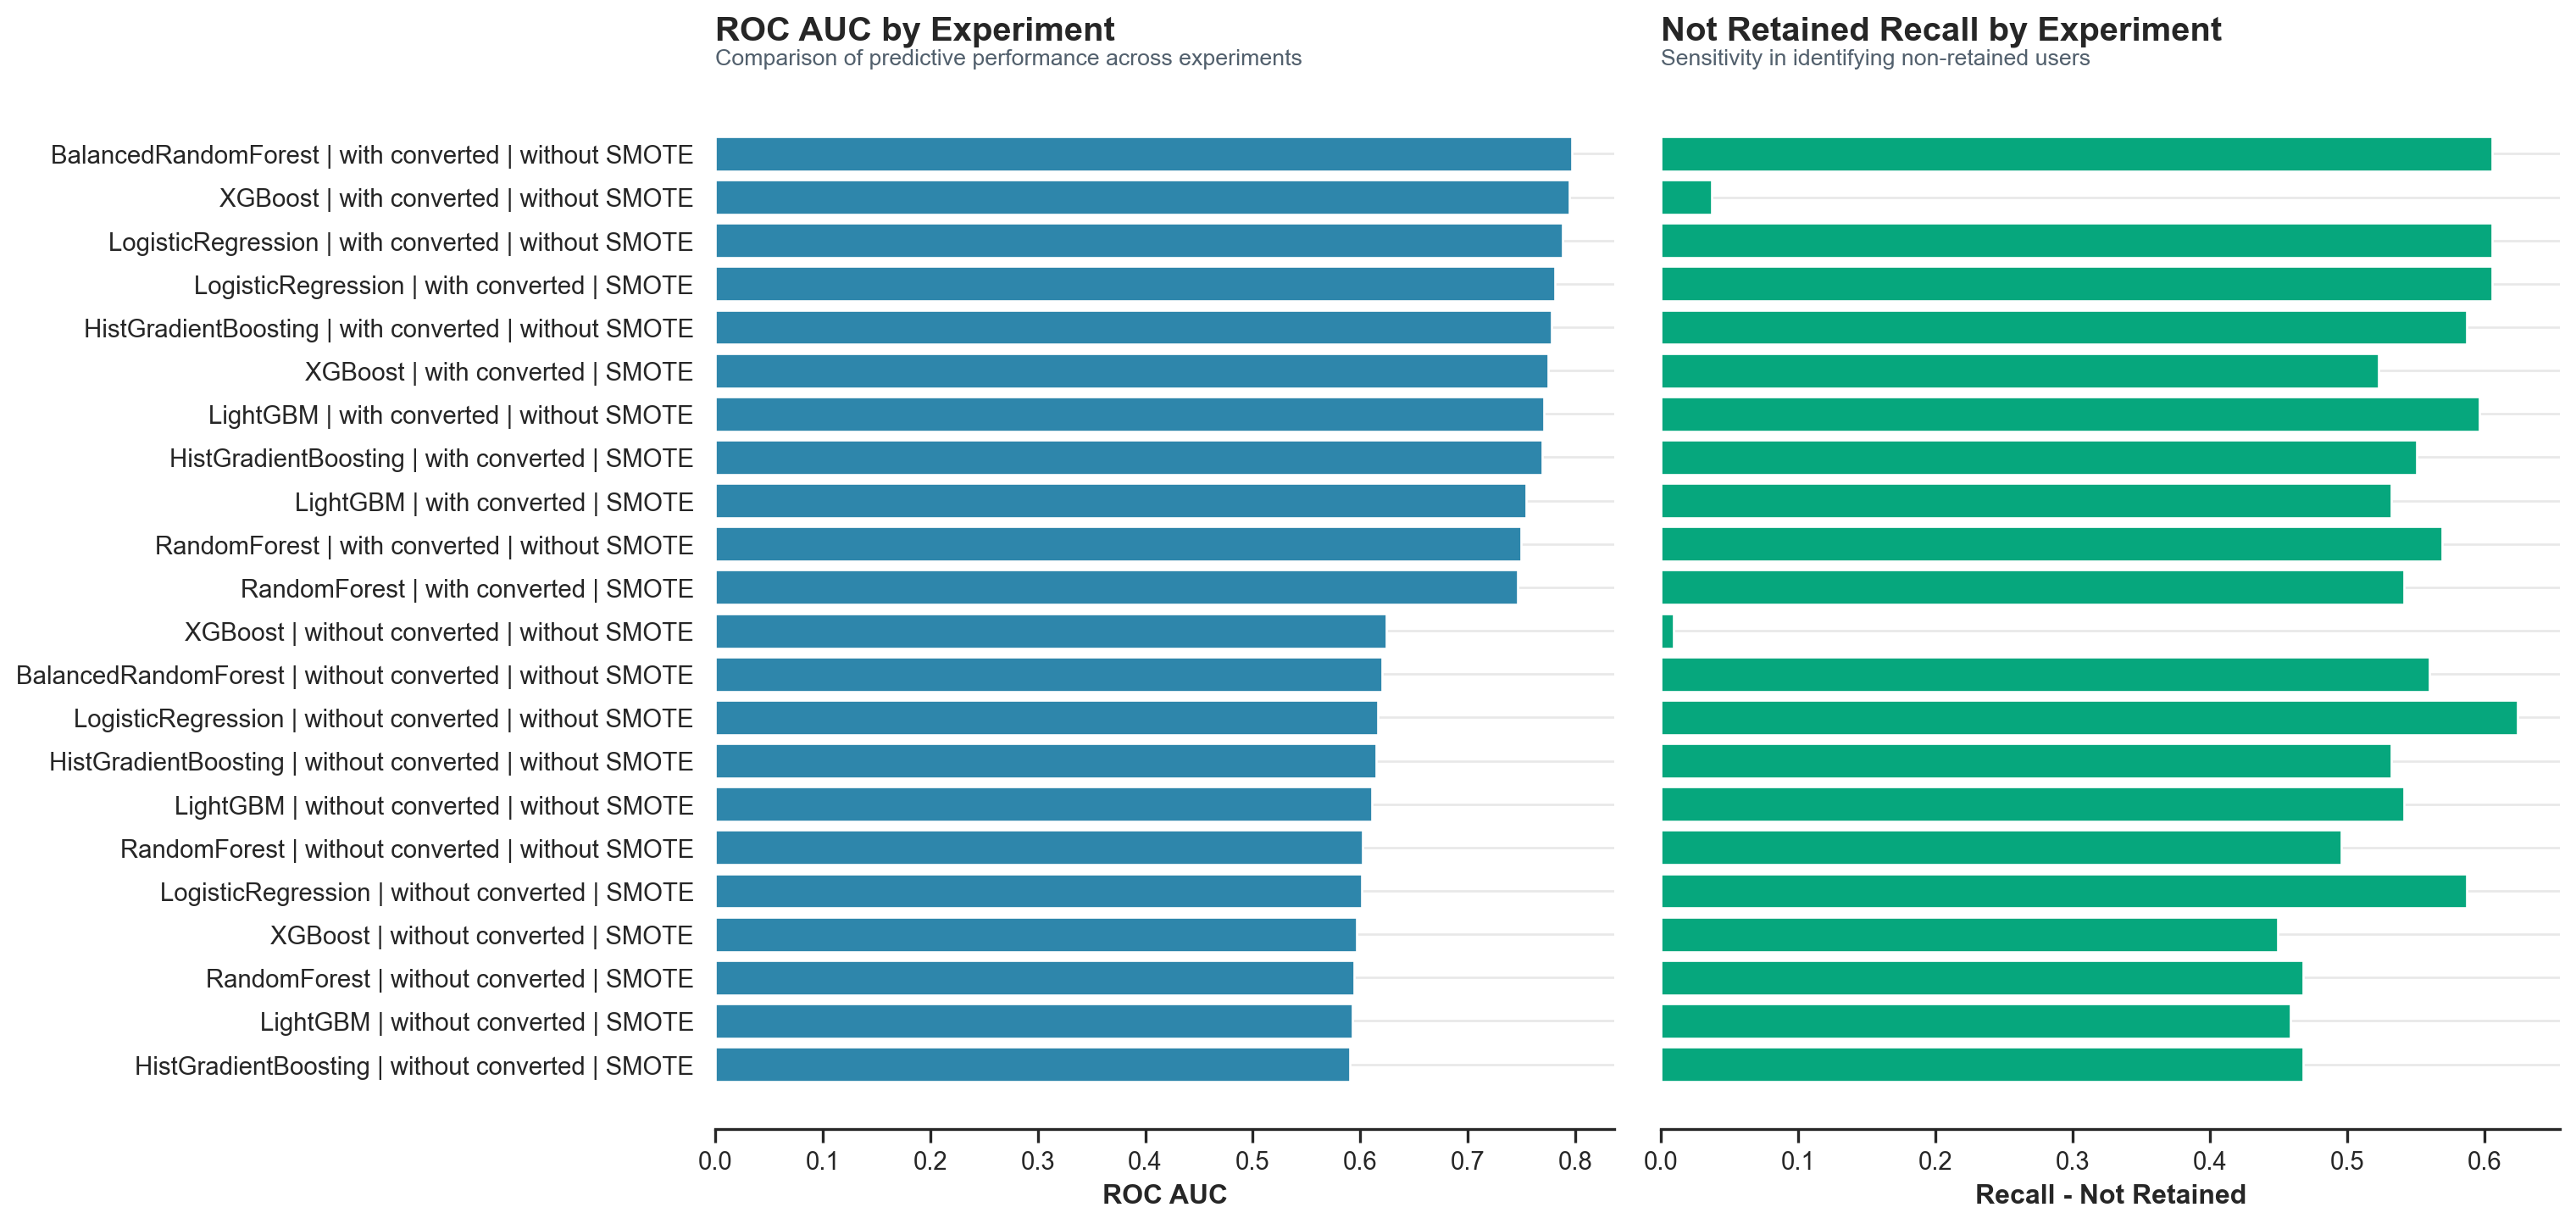


Best scenario according to the defined ranking:
estimator_name         BalancedRandomForest
include_converted                      True
resampling_strategy                    None
roc_auc                                0.80
recall_not_retained                    0.61
f1_not_retained                        0.31
Name: 0, dtype: object

CONFIGURATION: Estimator=BalancedRandomForest | conversion=True | Resampling=None
Target class distribution:
retained_flag
Retained        9210
Not Retained     547
Name: count, dtype: int64


,Metric,Value
0,Accuracy,0.85
1,Precision,0.97
2,Recall,0.86
3,F1-Score,0.92
4,ROC AUC,0.80
5,Precision - Not Retained,0.21
6,Recall - Not Retained,0.61
7,F1 - Not Retained,0.31
8,False Positives,43.00
9,False Negatives,252.00


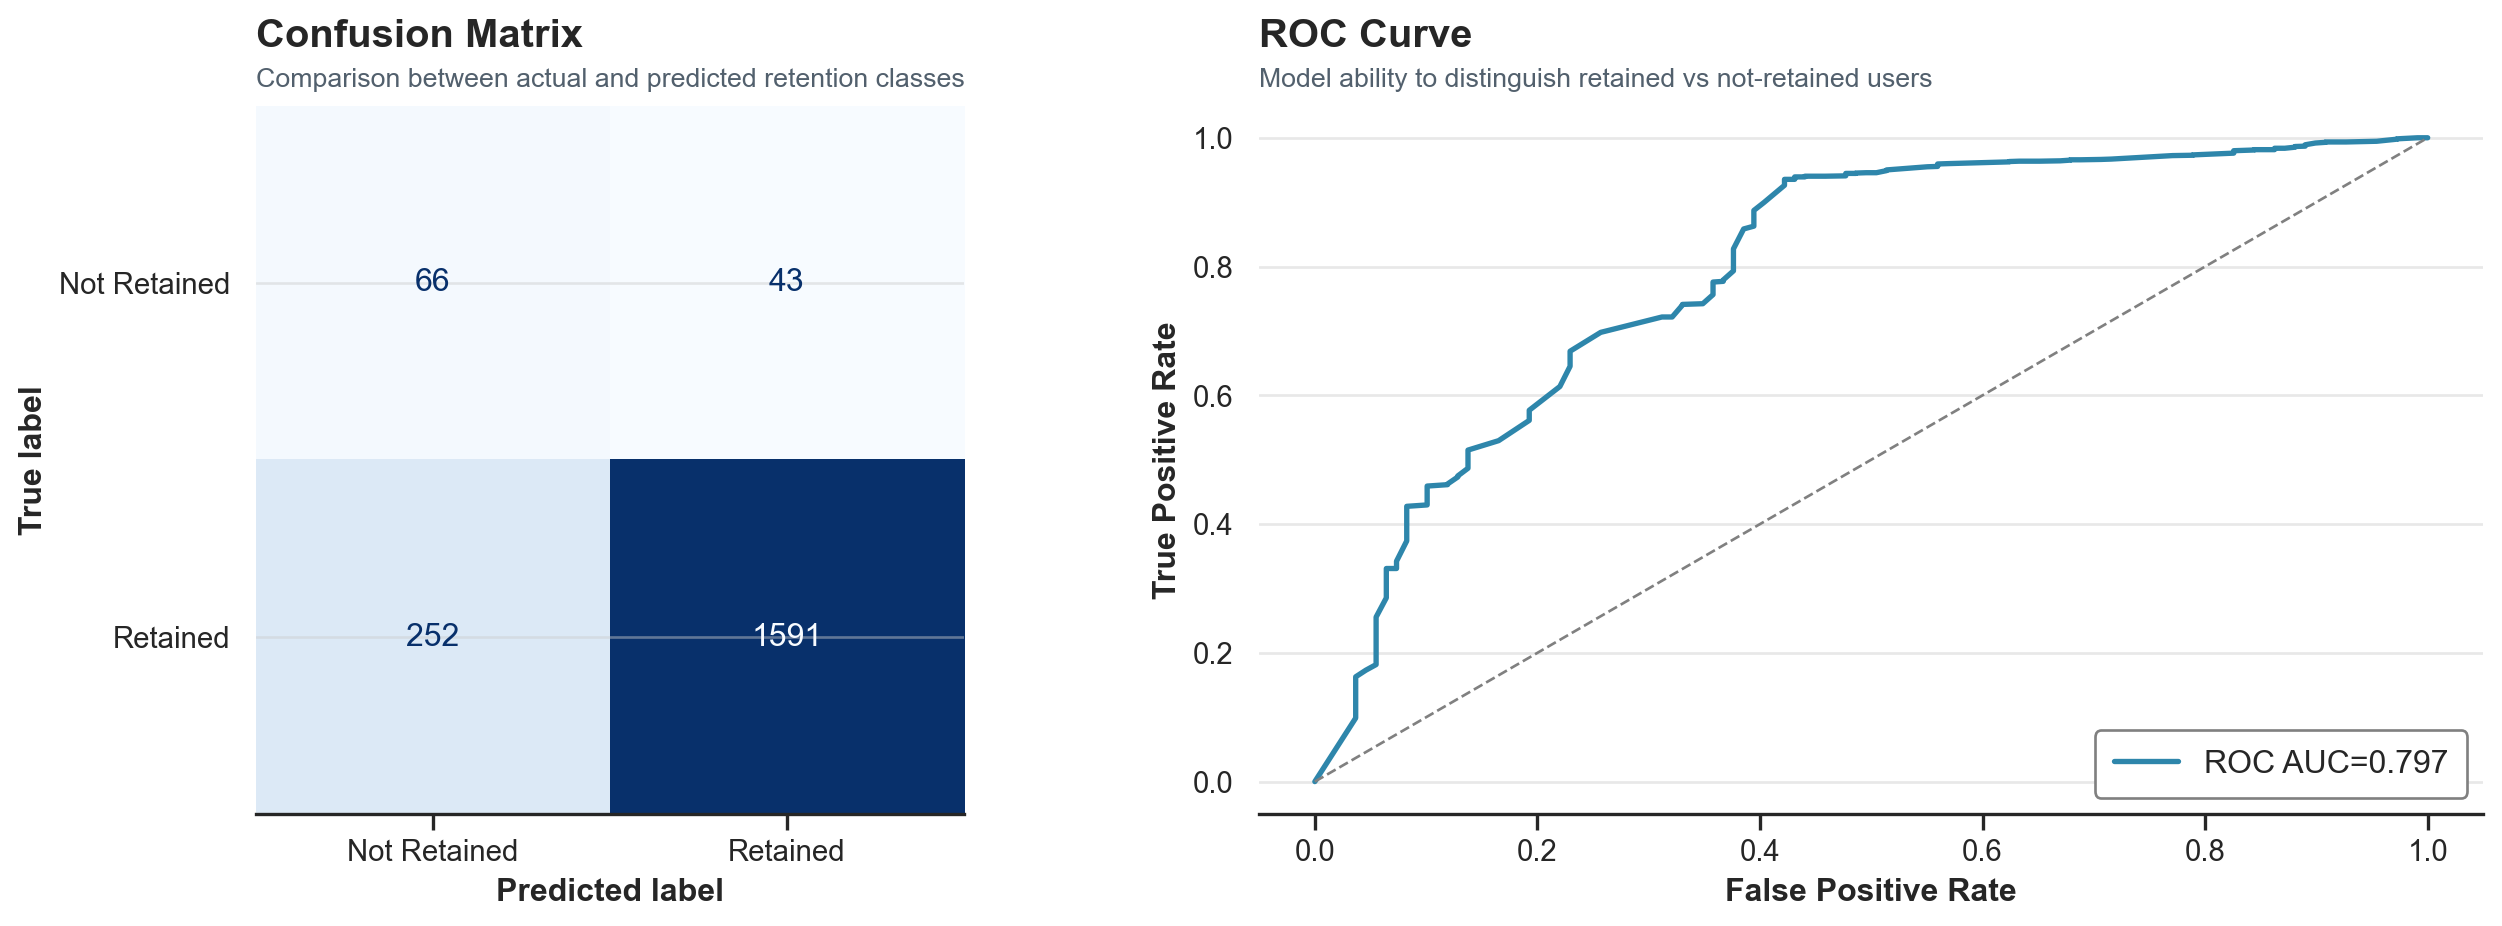

,feature,importance
25,num__converted_flag,0.59
6,cat__variant_control,0.03
17,cat__age_group_19-24 years,0.03
7,cat__variant_personalization,0.03
2,cat__marketing_channel_House Ads,0.03
22,cat__age_group_55+ years,0.03
0,cat__marketing_channel_Email,0.03
18,cat__age_group_24-30 years,0.02
1,cat__marketing_channel_Facebook,0.02
19,cat__age_group_30-36 years,0.02


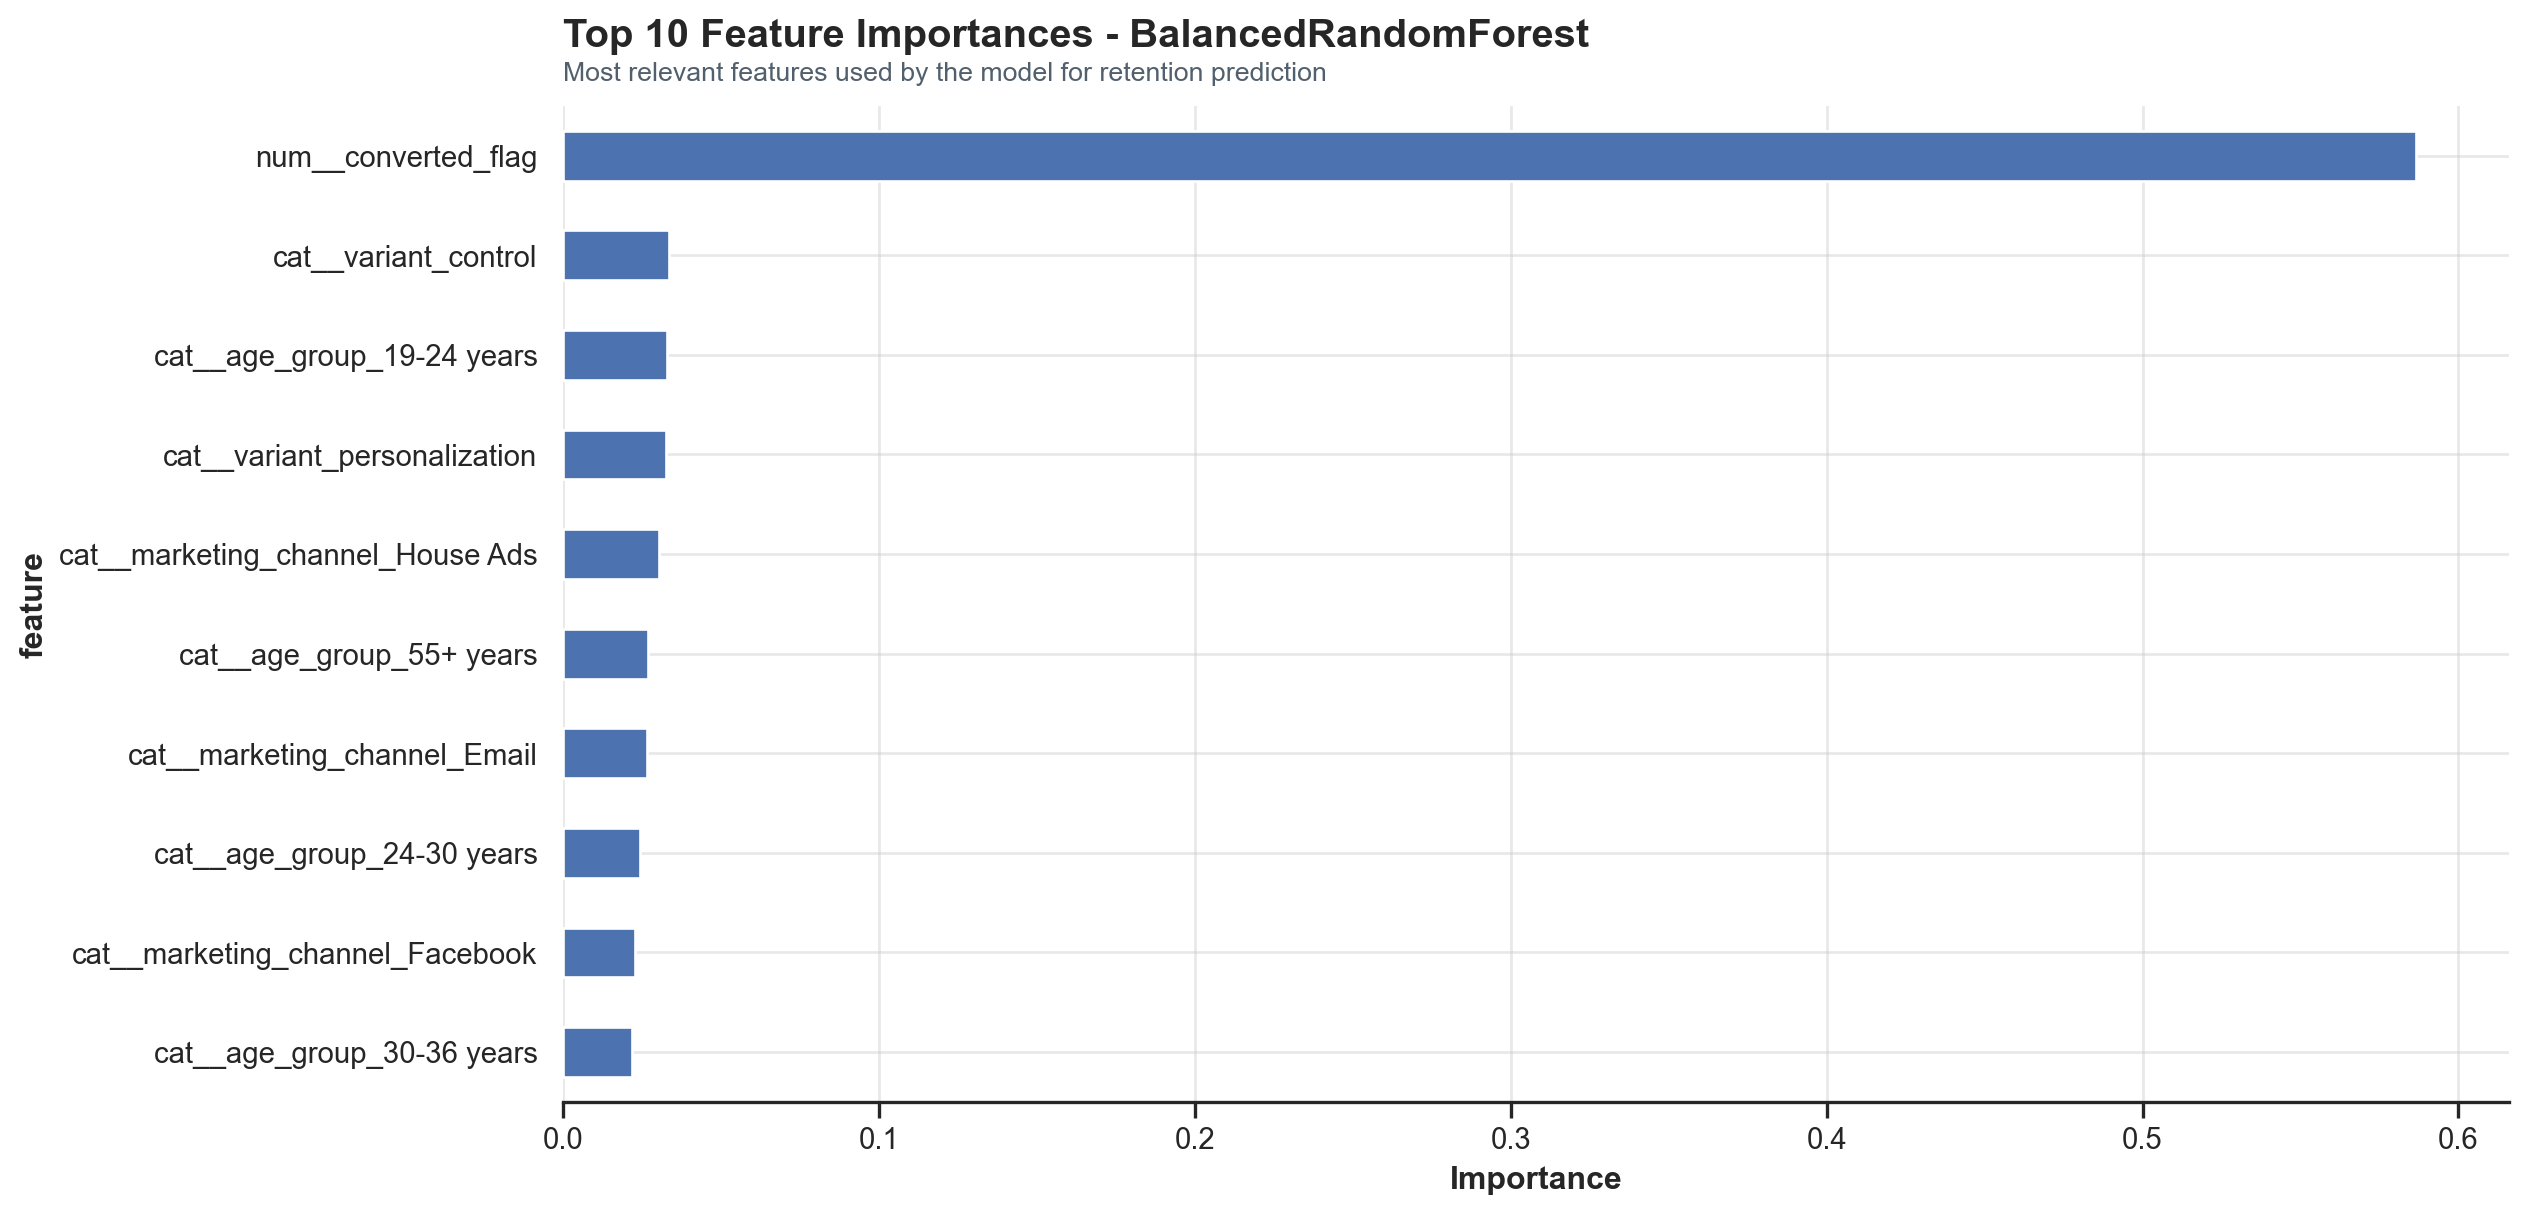

In [26]:
import inspect
import warnings

warnings.filterwarnings(
    "ignore",
    message=(
        "X does not have valid feature names, "
        "but LGBMClassifier was fitted with feature names"
    ),
)

from typing import Any, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except Exception as exc:
    SMOTE = None
    ImbPipeline = None
    IMBLEARN_IMPORT_ERROR = exc
else:
    IMBLEARN_IMPORT_ERROR = None


OPTIONAL_MODEL_INSTALL_HINT = (
    "mamba install -n Churn-ML -c conda-forge "
    "lightgbm xgboost imbalanced-learn"
)

OPTIONAL_WARNINGS_SHOWN = set()


def warn_once(key: str, message: str) -> None:
    """Emit optional warnings only once per execution."""
    if key not in OPTIONAL_WARNINGS_SHOWN:
        warnings.warn(message, stacklevel=2)
        OPTIONAL_WARNINGS_SHOWN.add(key)


def to_binary_flag(series: pd.Series, default: int = 0) -> pd.Series:
    """Convert boolean, textual, or numeric values into 0/1 flags."""
    mapping = {
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0,
        "yes": 1,
        "no": 0,
        "sim": 1,  # Portuguese "yes" alias for backward compatibility
        "nao": 0,  # Portuguese "no" alias for backward compatibility
        "y": 1,
        "n": 0,
    }

    normalized = series.astype("string").str.strip().str.lower()
    mapped = normalized.map(mapping)
    numeric = pd.to_numeric(series, errors="coerce")
    result = mapped.fillna(numeric).fillna(default).astype(int)

    return result.clip(lower=0, upper=1)


def prepare_retention_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Create modeling flags without depending on previous notebook cells."""
    df_model = df.copy().replace({pd.NA: np.nan})

    if "converted_flag" not in df_model.columns and "converted" in df_model.columns:
        df_model["converted_flag"] = to_binary_flag(df_model["converted"])

    if "retained_flag" not in df_model.columns and "is_retained" in df_model.columns:
        df_model["retained_flag"] = to_binary_flag(df_model["is_retained"])

    if "is_correct_lang_flag" not in df_model.columns:
        if "is_correct_lang" in df_model.columns:
            df_model["is_correct_lang_flag"] = to_binary_flag(
                df_model["is_correct_lang"]
            )
        elif {
            "language_displayed",
            "language_preferred",
        }.issubset(df_model.columns):
            df_model["is_correct_lang_flag"] = (
                df_model["language_displayed"].astype(str)
                == df_model["language_preferred"].astype(str)
            ).astype(int)

    if "month" not in df_model.columns and "date_served" in df_model.columns:
        df_model["month"] = pd.to_datetime(
            df_model["date_served"],
            errors="coerce",
        ).dt.month

    return df_model


def make_one_hot_encoder() -> OneHotEncoder:
    """Create OneHotEncoder compatible with different sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def get_retention_estimators(random_state: int = 42) -> dict[str, Any]:
    """Return available retention estimators in the environment."""
    estimators = {
        "LogisticRegression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),
    }

    hist_params = {"random_state": random_state}
    hist_signature = inspect.signature(HistGradientBoostingClassifier)

    if "class_weight" in hist_signature.parameters:
        hist_params["class_weight"] = "balanced"
    else:
        warn_once(
            "hist_gradient_class_weight",
            (
                "HistGradientBoostingClassifier in this sklearn version does "
                "not support class_weight; running without internal balancing."
            ),
        )

    estimators["HistGradientBoosting"] = HistGradientBoostingClassifier(
        **hist_params
    )

    try:
        from lightgbm import LGBMClassifier
    except Exception as exc:
        warn_once(
            "lightgbm_missing",
            (
                "LightGBM unavailable; estimator skipped. "
                f"Details: {exc}. Install with: {OPTIONAL_MODEL_INSTALL_HINT}"
            ),
        )
    else:
        estimators["LightGBM"] = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1,
            verbose=-1,
        )

    try:
        from xgboost import XGBClassifier
    except Exception as exc:
        warn_once(
            "xgboost_missing",
            (
                "XGBoost unavailable; estimator skipped. "
                f"Details: {exc}. Install with: {OPTIONAL_MODEL_INSTALL_HINT}"
            ),
        )
    else:
        # XGBoost uses class 1 as the positive class.
        # In this project, the operationally relevant class for
        # preventive action is class 0 ("Not Retained").
        # Therefore, scale_pos_weight remains disabled to avoid
        # optimizing the wrong class without calibration.
        estimators["XGBoost"] = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
        )

    try:
        from imblearn.ensemble import BalancedRandomForestClassifier
    except Exception as exc:
        warn_once(
            "balanced_rf_missing",
            (
                "BalancedRandomForestClassifier unavailable; estimator skipped. "
                f"Details: {exc}. Install with: {OPTIONAL_MODEL_INSTALL_HINT}"
            ),
        )
    else:
        estimators["BalancedRandomForest"] = BalancedRandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
        )

    return estimators


def get_retention_feature_sets(
    df: pd.DataFrame,
    include_converted: bool,
) -> tuple[list[str], list[str]]:
    """Build dynamic categorical and numerical feature lists."""
    categorical_candidates = [
        "marketing_channel",
        "variant",
        "language_displayed",
        "language_preferred",
        "age_group",
    ]

    numeric_candidates = [
        "is_correct_lang_flag",
        "month",
    ]

    if include_converted:
        numeric_candidates.append("converted_flag")

    categorical_features = [
        feature for feature in categorical_candidates if feature in df.columns
    ]

    numeric_features = [
        feature for feature in numeric_candidates if feature in df.columns
    ]

    return categorical_features, numeric_features


def make_retention_preprocessor(
    categorical_features: list[str],
    numeric_features: list[str],
) -> ColumnTransformer:
    """Create a common preprocessing pipeline for all estimators."""
    transformers = []

    if categorical_features:
        categorical_transformer = SklearnPipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Unknown",
                    ),
                ),
                ("onehot", make_one_hot_encoder()),
            ]
        )

        transformers.append(
            ("cat", categorical_transformer, categorical_features)
        )

    if numeric_features:
        numeric_transformer = SklearnPipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )

        transformers.append(
            ("num", numeric_transformer, numeric_features)
        )

    return ColumnTransformer(transformers=transformers)


def predict_retention_proba(
    pipeline: Any,
    X_test: pd.DataFrame,
) -> np.ndarray:
    """Get probability for the Retained class when available."""
    if hasattr(pipeline, "predict_proba"):
        probabilities = pipeline.predict_proba(X_test)
        return np.asarray(probabilities)[:, 1]

    warn_once(
        "predict_proba_missing",
        "Final estimator does not expose predict_proba; ROC AUC will be unavailable.",
    )

    return np.full(shape=len(X_test), fill_value=np.nan)


def calculate_retention_metrics(
    y_test: pd.Series,
    y_pred: np.ndarray,
    y_pred_proba: np.ndarray,
) -> dict[str, Any]:
    """Calculate overall metrics and Not Retained class metrics."""
    y_true = np.asarray(y_test)
    y_hat = np.asarray(y_pred)
    proba = np.asarray(y_pred_proba)

    try:
        roc_auc = roc_auc_score(y_true, proba)
    except ValueError:
        roc_auc = np.nan

    false_positives = int(((y_true == 0) & (y_hat == 1)).sum())
    false_negatives = int(((y_true == 1) & (y_hat == 0)).sum())

    return {
        "accuracy": round(accuracy_score(y_true, y_hat), 4),
        "precision": round(
            precision_score(y_true, y_hat, zero_division=0),
            4,
        ),
        "recall": round(
            recall_score(y_true, y_hat, zero_division=0),
            4,
        ),
        "f1": round(
            f1_score(y_true, y_hat, zero_division=0),
            4,
        ),
        "roc_auc": round(float(roc_auc), 4)
        if pd.notna(roc_auc)
        else np.nan,
        "precision_not_retained": round(
            precision_score(
                y_true,
                y_hat,
                pos_label=0,
                zero_division=0,
            ),
            4,
        ),
        "recall_not_retained": round(
            recall_score(
                y_true,
                y_hat,
                pos_label=0,
                zero_division=0,
            ),
            4,
        ),
        "f1_not_retained": round(
            f1_score(
                y_true,
                y_hat,
                pos_label=0,
                zero_division=0,
            ),
            4,
        ),
        "false_positives": false_positives,
        "false_negatives": false_negatives,
    }


def make_metrics_dataframe(metrics: dict[str, Any]) -> pd.DataFrame:
    """Format metrics for notebook display."""
    metric_labels = [
        ("Accuracy", "accuracy"),
        ("Precision", "precision"),
        ("Recall", "recall"),
        ("F1-Score", "f1"),
        ("ROC AUC", "roc_auc"),
        ("Precision - Not Retained", "precision_not_retained"),
        ("Recall - Not Retained", "recall_not_retained"),
        ("F1 - Not Retained", "f1_not_retained"),
        ("False Positives", "false_positives"),
        ("False Negatives", "false_negatives"),
    ]

    return pd.DataFrame(
        {
            "Metric": [label for label, _ in metric_labels],
            "Value": [metrics[key] for _, key in metric_labels],
        }
    )


def get_transformed_feature_names(
    pipeline: Any,
    expected_size: Optional[int] = None,
) -> np.ndarray:
    """Recover transformed feature names when exposed by sklearn."""
    preprocessor = pipeline.named_steps["preprocessor"]

    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = np.array([], dtype=object)

    if expected_size is not None and len(feature_names) != expected_size:
        return np.array([f"feature_{idx}" for idx in range(expected_size)])

    return feature_names


def plot_retention_diagnostics(
    y_test: pd.Series,
    y_pred: np.ndarray,
    y_pred_proba: np.ndarray,
    roc_auc: float,
) -> None:
    """Display confusion matrix and ROC curve."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Not Retained", "Retained"],
    ).plot(
        ax=axes[0],
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )

    add_titles(
        axes[0],
        "Confusion Matrix",
        subtitle="Comparison between actual and predicted retention classes",
    )

    if pd.notna(roc_auc):
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

        axes[1].plot(
            fpr,
            tpr,
            color="#2E86AB",
            lw=2,
            label=f"ROC AUC={roc_auc:.3f}",
        )
    else:
        axes[1].text(
            0.5,
            0.5,
            "ROC AUC unavailable",
            ha="center",
        )

    axes[1].plot(
        [0, 1],
        [0, 1],
        color="gray",
        linestyle="--",
        lw=1,
    )

    axes[1].set_xlabel("False Positive Rate", fontweight="bold")
    axes[1].set_ylabel("True Positive Rate", fontweight="bold")

    add_titles(
        axes[1],
        "ROC Curve",
        subtitle="Model ability to distinguish retained vs not-retained users",
    )

    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()
    plt.close()


def plot_model_signal_summary(
    pipeline: Any,
    estimator_name: str,
    top_n: int = 10,
) -> None:
    """Display feature importances or coefficients when available."""
    classifier = pipeline.named_steps["classifier"]

    if hasattr(classifier, "feature_importances_"):
        values = np.asarray(classifier.feature_importances_)
        feature_names = get_transformed_feature_names(pipeline, len(values))

        signal_df = pd.DataFrame(
            {
                "feature": feature_names,
                "importance": values,
            }
        ).sort_values("importance", ascending=False)

        top_features = signal_df.head(top_n).sort_values("importance")

        display(signal_df.head(top_n))

        top_features.plot.barh(
            x="feature",
            y="importance",
            legend=False,
        )

        add_titles(
            plt.gca(),
            f"Top {top_n} Feature Importances - {estimator_name}",
            subtitle=(
                "Most relevant features used by the model "
                "for retention prediction"
            ),
        )

        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()
        plt.close()

        return

    if isinstance(classifier, LogisticRegression) and hasattr(
        classifier,
        "coef_",
    ):
        coefficients = np.asarray(classifier.coef_).ravel()
        feature_names = get_transformed_feature_names(
            pipeline,
            len(coefficients),
        )

        coef_df = pd.DataFrame(
            {
                "feature": feature_names,
                "coefficient": coefficients,
                "absolute_coefficient": np.abs(coefficients),
            }
        ).sort_values("absolute_coefficient", ascending=False)

        top_coefficients = coef_df.head(top_n).sort_values(
            "absolute_coefficient"
        )

        display(coef_df.head(top_n))

        top_coefficients.plot.barh(
            x="feature",
            y="absolute_coefficient",
            legend=False,
        )

        add_titles(
            plt.gca(),
            f"Top {top_n} Absolute Coefficients - {estimator_name}",
            subtitle=(
                "Features most strongly associated with retention in logistic "
                "regression, regardless of direction"
            ),
        )

        plt.xlabel("Absolute coefficient")
        plt.tight_layout()
        plt.show()
        plt.close()

        return

    print(
        f"{estimator_name} does not expose direct feature importances "
        "or coefficients."
    )


def build_retention_model(
    df: pd.DataFrame,
    test_size: float = 0.2,
    include_converted: bool = True,
    resampling_strategy: Optional[str] = None,
    estimator_name: str = "RandomForest",
    random_state: int = 42,
    show_plots: bool = True,
    display_metrics: bool = True,
    verbose: bool = True,
) -> Tuple[
    Any,
    pd.DataFrame,
    list,
    list,
    pd.Series,
    np.ndarray,
    np.ndarray,
    pd.DataFrame,
]:
    """Train an experimental retention model for a defined scenario."""
    if resampling_strategy not in {None, "smote"}:
        raise ValueError("resampling_strategy must be None or 'smote'.")

    df_model = prepare_retention_model_frame(df)

    if "retained_flag" not in df_model.columns:
        raise ValueError(
            "The retained_flag or is_retained column is required."
        )

    categorical_features, numeric_features = get_retention_feature_sets(
        df_model,
        include_converted=include_converted,
    )

    feature_columns = categorical_features + numeric_features

    if not feature_columns:
        raise ValueError("No available features for retention modeling.")

    X = df_model[feature_columns].copy()
    y = to_binary_flag(df_model["retained_flag"])

    if y.nunique() < 2:
        raise ValueError(
            "The retained_flag target variable must contain both classes 0 and 1."
        )

    estimators = get_retention_estimators(random_state=random_state)

    if estimator_name not in estimators:
        available = ", ".join(estimators.keys())

        raise ValueError(
            f"Estimator '{estimator_name}' unavailable. Available: {available}."
        )

    if verbose:
        print("\n" + "=" * 80)
        print(
            "CONFIGURATION: "
            f"Estimator={estimator_name} | "
            f"conversion={include_converted} | "
            f"Resampling={resampling_strategy}"
        )
        print("Target class distribution:")
        print(
            y.value_counts().rename(
                index={
                    0: "Not Retained",
                    1: "Retained",
                }
            )
        )
        print("=" * 80)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    preprocessor = make_retention_preprocessor(
        categorical_features=categorical_features,
        numeric_features=numeric_features,
    )

    steps = [("preprocessor", preprocessor)]

    effective_resampling = resampling_strategy

    if resampling_strategy == "smote":
        if SMOTE is None or ImbPipeline is None:
            warn_once(
                "smote_missing",
                (
                    "SMOTE unavailable; scenario executed without resampling. "
                    f"Install with: {OPTIONAL_MODEL_INSTALL_HINT}"
                ),
            )
            effective_resampling = None
        else:
            minority_count = int(y_train.value_counts().min())

            if minority_count < 2:
                warn_once(
                    "smote_too_few_samples",
                    (
                        "SMOTE skipped because the minority class contains "
                        "fewer than 2 training samples."
                    ),
                )
                effective_resampling = None
            else:
                k_neighbors = min(5, minority_count - 1)

                # SMOTE is applied in the numerical space after
                # OneHotEncoder transformation.
                steps.append(
                    (
                        "resampler",
                        SMOTE(
                            random_state=random_state,
                            k_neighbors=k_neighbors,
                        ),
                    )
                )

    steps.append(("classifier", estimators[estimator_name]))

    pipeline_class = (
        ImbPipeline
        if effective_resampling == "smote"
        else SklearnPipeline
    )

    pipeline = pipeline_class(steps=steps)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred_proba = predict_retention_proba(pipeline, X_test)

    metrics = calculate_retention_metrics(
        y_test,
        y_pred,
        y_pred_proba,
    )

    metrics_df = make_metrics_dataframe(metrics)

    if display_metrics:
        display(metrics_df)

    if show_plots:
        plot_retention_diagnostics(
            y_test=y_test,
            y_pred=y_pred,
            y_pred_proba=y_pred_proba,
            roc_auc=metrics["roc_auc"],
        )

        plot_model_signal_summary(
            pipeline,
            estimator_name=estimator_name,
        )

    return (
        pipeline,
        metrics_df,
        categorical_features,
        numeric_features,
        y_test,
        y_pred,
        y_pred_proba,
        X_test,
    )


def make_experiment_label(
    estimator_name: str,
    include_converted: bool,
    resampling_strategy: Optional[str],
) -> str:
    """Create readable labels for tables and charts."""
    converted_label = "with converted" if include_converted else "without converted"
    resampling_label = "SMOTE" if resampling_strategy == "smote" else "without SMOTE"

    return f"{estimator_name} | {converted_label} | {resampling_label}"


def run_retention_experiments(
    df_clean: pd.DataFrame,
    random_state: int = 42,
    test_size: float = 0.2,
) -> pd.DataFrame:
    """Run experimental matrix across estimators, features, and balancing strategies."""
    available_estimators = get_retention_estimators(random_state=random_state)

    preferred_order = [
        "LogisticRegression",
        "RandomForest",
        "HistGradientBoosting",
        "LightGBM",
        "XGBoost",
        "BalancedRandomForest",
    ]

    estimator_names = [
        name for name in preferred_order if name in available_estimators
    ]

    smote_available = SMOTE is not None and ImbPipeline is not None

    if not smote_available:
        warn_once(
            "smote_matrix_missing",
            (
                "SMOTE unavailable; experiments with resampling='smote' "
                f"will be skipped. Install with: {OPTIONAL_MODEL_INSTALL_HINT}"
            ),
        )

    rows = []
    include_options = [True, False]

    for estimator_name in estimator_names:
        if estimator_name == "BalancedRandomForest":
            resampling_options = [None]
        else:
            resampling_options = [None, "smote"] if smote_available else [None]

        for include_converted in include_options:
            for resampling_strategy in resampling_options:
                if (
                    estimator_name == "LogisticRegression"
                    and resampling_strategy == "smote"
                ):
                    warn_once(
                        "logistic_smote_note",
                        (
                            "LogisticRegression already uses "
                            "class_weight='balanced'; the SMOTE scenario "
                            "evaluates additional balancing."
                        ),
                    )

                print(
                    "Running experiment: "
                    f"{make_experiment_label(estimator_name, include_converted, resampling_strategy)}"
                )

                try:
                    result = build_retention_model(
                        df_clean,
                        test_size=test_size,
                        include_converted=include_converted,
                        resampling_strategy=resampling_strategy,
                        estimator_name=estimator_name,
                        random_state=random_state,
                        show_plots=False,
                        display_metrics=False,
                        verbose=False,
                    )
                except Exception as exc:
                    warn_once(
                        (
                            f"experiment_failed_{estimator_name}_"
                            f"{include_converted}_{resampling_strategy}"
                        ),
                        (
                            "Experiment skipped due to error: "
                            f"{estimator_name}, "
                            f"include_converted={include_converted}, "
                            f"resampling_strategy={resampling_strategy}. "
                            f"Details: {exc}"
                        ),
                    )
                    continue

                _, _, _, _, y_test, y_pred, y_pred_proba, _ = result

                metrics = calculate_retention_metrics(
                    y_test,
                    y_pred,
                    y_pred_proba,
                )

                rows.append(
                    {
                        "experiment": make_experiment_label(
                            estimator_name,
                            include_converted,
                            resampling_strategy,
                        ),
                        "estimator_name": estimator_name,
                        "include_converted": include_converted,
                        "resampling_strategy": resampling_strategy or "None",
                        "accuracy": metrics["accuracy"],
                        "precision": metrics["precision"],
                        "recall": metrics["recall"],
                        "f1": metrics["f1"],
                        "roc_auc": metrics["roc_auc"],
                        "precision_not_retained": metrics[
                            "precision_not_retained"
                        ],
                        "recall_not_retained": metrics[
                            "recall_not_retained"
                        ],
                        "f1_not_retained": metrics["f1_not_retained"],
                        "false_positives": metrics["false_positives"],
                        "false_negatives": metrics["false_negatives"],
                    }
                )

    results_df = pd.DataFrame(rows)

    if results_df.empty:
        return results_df

    return results_df.sort_values(
        [
            "roc_auc",
            "recall_not_retained",
            "f1_not_retained",
        ],
        ascending=[False, False, False],
    ).reset_index(drop=True)


def plot_retention_experiment_comparison(
    results_df: pd.DataFrame,
) -> None:
    """Compare ROC AUC and Not Retained recall across experiments."""
    if results_df.empty:
        print("No experiments available for visualization.")
        return

    plot_df = results_df.sort_values(
        [
            "roc_auc",
            "recall_not_retained",
            "f1_not_retained",
        ],
        ascending=True,
    )

    fig_height = max(6, 0.35 * len(plot_df))
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, fig_height),
        sharey=True,
    )

    axes[0].barh(
        plot_df["experiment"],
        plot_df["roc_auc"],
        color="#2E86AB",
    )

    add_titles(
        axes[0],
        "ROC AUC by Experiment",
        subtitle="Comparison of predictive performance across experiments",
    )

    axes[0].set_xlabel("ROC AUC")

    axes[1].barh(
        plot_df["experiment"],
        plot_df["recall_not_retained"],
        color="#06A77D",
    )

    add_titles(
        axes[1],
        "Not Retained Recall by Experiment",
        subtitle="Sensitivity in identifying non-retained users",
    )

    axes[1].set_xlabel("Recall - Not Retained")

    plt.tight_layout()
    plt.show()
    plt.close()


experiment_results_df = run_retention_experiments(df_clean)

display(experiment_results_df)

plot_retention_experiment_comparison(experiment_results_df)

if experiment_results_df.empty:
    raise RuntimeError(
        "No retention experiments were successfully executed."
    )

best_experiment = experiment_results_df.iloc[0]
best_resampling_strategy = best_experiment["resampling_strategy"]

if best_resampling_strategy == "None" or pd.isna(best_resampling_strategy):
    best_resampling_strategy = None

print("\nBest scenario according to the defined ranking:")

print(
    best_experiment[
        [
            "estimator_name",
            "include_converted",
            "resampling_strategy",
            "roc_auc",
            "recall_not_retained",
            "f1_not_retained",
        ]
    ]
)

df_clean = prepare_retention_model_frame(df_clean)

(
    pipeline,
    model_metrics,
    cat_features,
    num_features,
    y_test,
    y_pred,
    y_pred_proba,
    X_test,
) = build_retention_model(
    df_clean,
    include_converted=bool(best_experiment["include_converted"]),
    resampling_strategy=best_resampling_strategy,
    estimator_name=str(best_experiment["estimator_name"]),
    show_plots=True,
    display_metrics=True,
    verbose=True,
)

retention_model_artifacts = {
    "pipeline": pipeline,
    "model_metrics": model_metrics,
    "cat_features": cat_features,
    "num_features": num_features,
    "y_test": y_test,
    "y_pred": y_pred,
    "y_pred_proba": y_pred_proba,
    "X_test": X_test,
    "best_experiment": best_experiment,
}

In [27]:
from IPython.display import Markdown

best = experiment_results_df.iloc[0]
display(Markdown(f"""
> **Selected model:** {best['estimator_name']} | {'with' if best['include_converted'] else 'without'} converted_flag | {best['resampling_strategy'] or 'without'} SMOTE
>
> **Metrics:** ROC AUC = {best['roc_auc']:.3f} | Not Retained Recall = {best['recall_not_retained']:.3f} | F1-score Not Retained = {best['f1_not_retained']:.3f}
>
> **Operational implication:** The model identifies {best['recall_not_retained']:.0%} of users
> who would not remain retained. This enables proactive preventive campaigns for this group
> before churn occurs, with a precision of {best['precision_not_retained']:.0%}
> (proportion of correct alerts).
>
> **Limitation:** Prediction is not causality. Results should be validated with a dedicated
> retention A/B experiment before scaling preventive campaigns.
"""))


> **Selected model:** BalancedRandomForest | with converted_flag | None SMOTE
>
> **Metrics:** ROC AUC = 0.797 | Not Retained Recall = 0.606 | F1-score Not Retained = 0.309
>
> **Operational implication:** The model identifies 61% of users
> who would not remain retained. This enables proactive preventive campaigns for this group
> before churn occurs, with a precision of 21%
> (proportion of correct alerts).
>
> **Limitation:** Prediction is not causality. Results should be validated with a dedicated
> retention A/B experiment before scaling preventive campaigns.


<span style="color:steelblue; text-align: left">

## Error Analysis: Users Predicted as Retained but Not Retained

</span>

Confusion matrix, false positives/negatives, and operational implications for risk-targeted campaigns.



In [28]:
def analyze_retention_errors(
    pipeline: Any,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    y_pred: np.ndarray,
    y_pred_proba: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Analyze false positives and false negatives from the retention model."""
    _ = pipeline
    errors_df = X_test.copy().reset_index(drop=True)
    errors_df.insert(0, "original_index", X_test.index.to_numpy())
    errors_df["y_true"] = np.asarray(y_test)
    errors_df["y_pred"] = np.asarray(y_pred)
    errors_df["prob_retention"] = np.asarray(y_pred_proba)

    false_positives = errors_df[
        (errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1)
    ].copy()
    false_negatives = errors_df[
        (errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0)
    ].copy()

    print("Classification error summary")
    print(f"false positivos: {len(false_positives)}")
    print(f"false negativos: {len(false_negatives)}")

    analysis_columns = [
        "marketing_channel",
        "variant",
        "age_group",
        "language_displayed",
        "language_preferred",
        "is_correct_lang_flag",
    ]

    if false_positives.empty:
        print("No false positives to analyze in the test set.")
        return errors_df, false_positives, false_negatives

    print("\nFalse positive distribution by variable")
    for column in analysis_columns:
        if column not in false_positives.columns:
            continue

        values = false_positives[column].astype("object")
        values = values.where(values.notna(), "Missing")
        frequency_table = (
            values.value_counts(dropna=False)
            .rename_axis(column)
            .reset_index(name="quantity")
        )
        frequency_table["percentage"] = (
            frequency_table["quantity"] / len(false_positives) * 100
        ).round(2)

        print(f"\n{column}")
        display(frequency_table)

    return errors_df, false_positives, false_negatives


(
    retention_errors_df,
    retention_false_positives_df,
    retention_false_negatives_df,
) = analyze_retention_errors(
    pipeline=pipeline,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
)

Classification error summary
false positivos: 43
false negativos: 252

False positive distribution by variable

marketing_channel


,marketing_channel,quantity,percentage
0,House Ads,25,58.14
1,Facebook,8,18.60
2,Instagram,4,9.30
3,Push,3,6.98
4,Email,3,6.98



variant


,variant,quantity,percentage
0,control,30,69.77
1,personalization,13,30.23



age_group


...

,language_displayed,quantity,percentage
0,English,38,88.37
1,Spanish,5,11.63



language_preferred


,language_preferred,quantity,percentage
0,English,38,88.37
1,Spanish,5,11.63



is_correct_lang_flag


,is_correct_lang_flag,quantity,percentage
0,1,43,100.00


In [29]:
from IPython.display import Markdown

fp_count = int(len(retention_false_positives_df))
converted_total = int((df_clean["converted_flag"] == 1).sum())
fp_pct = (fp_count / max(converted_total, 1)) * 100
fp_savings = fp_count * 0.20 * DEFAULT_COST

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Error Analysis Insights

</span>

>**What the data shows:** The model generated {fp_count:,} false positives ({fp_pct:.1f}% of converted users). These users were predicted as retained but were not retained.
>**Why this matters:** Each false positive represents wasted budget on users who do not benefit from the campaign. Reducing FP improves retention ROI.
>**Recommended action:** Run granular analysis to identify channels, segments, or periods with higher FP. Adjust model threshold or improve features.
>**Impacto:** Reduzir FP em 20% economiza \\$ {fp_savings:,.0f} sem perder capacidade preditiva no recall.
"""))


<span style="color:steelblue; text-align: left">

### Error Analysis Insights

</span>

>**What the data shows:** The model generated 43 false positives (4.1% of converted users). These users were predicted as retained but were not retained.
>**Why this matters:** Each false positive represents wasted budget on users who do not benefit from the campaign. Reducing FP improves retention ROI.
>**Recommended action:** Run granular analysis to identify channels, segments, or periods with higher FP. Adjust model threshold or improve features.
>**Impacto:** Reduzir FP em 20% economiza \$ 10 sem perder capacidade preditiva no recall.


<span style="color:steelblue; text-align: left">

## False Positive Bias Diagnosis

</span>

This section analyzes retention-model errors with focus on false positives.

False positives are cases where the model predicts retention (`y_pred = 1`), but true outcome is not retained (`y_true = 0`). From a business perspective, this group matters because it represents users that seemed likely to stay but churned.

We investigate patterns by:
- marketing channel;
- campaign variant;
- age group;
- displayed language;
- displayed vs preferred language compatibility.

The goal is not causal proof, but practical evidence of where the model may overestimate retention probability.



In [30]:
def analyze_false_positive_bias(
    full_df: pd.DataFrame,
    false_positive_df: pd.DataFrame,
    columns: list[str],
) -> dict[str, pd.DataFrame]:
    """Compare false positives with the composition of the full dataset.

    The function calculates, for each categorical variable provided, the
    percentage distribution of the complete dataset and the percentage
    distribution of the false positive subset. The difference in percentage
    points (`diff_pp`) indicates whether a category appears in the false
    positives at a higher or lower proportion than its natural presence
    in the dataset.

    Parameters
    ----------
    full_df : pd.DataFrame
        Complete dataset used as a reference for the natural distribution
        of the groups.
    false_positive_df : pd.DataFrame
        DataFrame containing only false positives from the retention model.
    columns : list[str]
        Categorical variables that will be compared between the full dataset
        and the false positives.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary where each key is the analyzed variable name and each
        value is a DataFrame containing category, counts, percentages,
        percentage point difference, and textual interpretation.

    Notes
    -----
    The original DataFrames are not modified. Missing values are treated
    as the textual category "Missing" to preserve comparability between
    distributions.
    """
    full_data = full_df.copy(deep=False)
    false_positive_data = false_positive_df.copy(deep=False)
    results: dict[str, pd.DataFrame] = {}

    if not columns:
        print("No columns provided for bias analysis.")
        return results

    missing_columns = [
        column
        for column in columns
        if column not in full_data.columns
        or column not in false_positive_data.columns
    ]
    if missing_columns:
        print(f"Columns ignored because they are missing from the data: {missing_columns}")

    valid_columns = [
        column
        for column in columns
        if column in full_data.columns
        and column in false_positive_data.columns
    ]
    if not valid_columns:
        print("No valid columns available for analysis.")
        return results

    output_columns = [
        "category",
        "base_count",
        "base_pct",
        "false_positive_count",
        "false_positive_pct",
        "diff_pp",
        "interpretation",
    ]

    base_total = len(full_data)
    false_positive_total = len(false_positive_data)
    base_denominator = np.nan if base_total == 0 else base_total
    false_positive_denominator = (
        np.nan if false_positive_total == 0 else false_positive_total
    )

    print("False positive over-representation analysis")
    print(f"Total dataset: {base_total} records")
    print(f"False positives: {false_positive_total} records")

    for column in valid_columns:
        base_values = full_data[column].astype("object")
        base_values = base_values.where(base_values.notna(), "Missing")
        false_positive_values = false_positive_data[column].astype("object")
        false_positive_values = false_positive_values.where(
            false_positive_values.notna(),
            "Missing",
        )

        if base_values.empty and false_positive_values.empty:
            empty_df = pd.DataFrame(columns=output_columns)
            results[column] = empty_df
            print(f"\n{column}: no records available for comparison.")
            display(empty_df)
            continue

        base_counts = base_values.value_counts(dropna=False).rename(
            "base_count"
        )
        false_positive_counts = false_positive_values.value_counts(
            dropna=False
        ).rename("false_positive_count")

        comparison_df = (
            pd.concat([base_counts, false_positive_counts], axis=1)
            .fillna(0)
            .rename_axis("category")
            .reset_index()
        )

        comparison_df[["base_count", "false_positive_count"]] = comparison_df[
            ["base_count", "false_positive_count"]
        ].astype(int)

        comparison_df["base_pct"] = (
            comparison_df["base_count"] / base_denominator * 100
        ).round(2).fillna(0)

        comparison_df["false_positive_pct"] = (
            comparison_df["false_positive_count"]
            / false_positive_denominator
            * 100
        ).round(2).fillna(0)

        comparison_df["diff_pp"] = (
            comparison_df["false_positive_pct"]
            - comparison_df["base_pct"]
        ).round(2)

        comparison_df["interpretation"] = np.select(
            [
                comparison_df["diff_pp"] >= 10,
                comparison_df["diff_pp"] <= -10,
            ],
            [
                "Over-represented in false positives",
                "Under-represented in false positives",
            ],
            default="Proportional distribution",
        )

        comparison_df = comparison_df.sort_values(
            "diff_pp",
            ascending=False,
        ).reset_index(drop=True)

        comparison_df = comparison_df[output_columns]

        results[column] = comparison_df

        print(f"\nPercentage comparison for {column}")
        display(comparison_df)

        plot_df = comparison_df.sort_values("diff_pp", ascending=True)
        positions = np.arange(len(plot_df))
        bar_height = 0.38
        fig_height = max(4, len(plot_df) * 0.45)

        fig, ax = plt.subplots(figsize=(10, fig_height))

        ax.barh(
            positions - bar_height / 2,
            plot_df["base_pct"],
            height=bar_height,
            color="#2E86AB",
            label="Full dataset",
        )

        ax.barh(
            positions + bar_height / 2,
            plot_df["false_positive_pct"],
            height=bar_height,
            color="#D62828",
            label="False positives",
        )

        ax.set_yticks(positions)
        ax.set_yticklabels(plot_df["category"].astype(str))
        ax.set_xlabel("Percentage (%)", fontweight="bold")

        '''ax.set_title(
            f"Full dataset vs false positives: {column}",
            fontweight="bold",
        )'''

        add_titles(
            ax,
            f"Full dataset vs False Positives: {column}",
            subtitle=(
                "Comparison of the percentage distribution between the "
                "full dataset and false positives for each category"
            ),
        )

        ax.grid(axis="x", alpha=0.25)
        ax.legend()

        plt.tight_layout()
        plt.show()
        plt.close()

        top_row = comparison_df.iloc[0]

        category = top_row["category"]
        false_positive_pct = top_row["false_positive_pct"]
        base_pct = top_row["base_pct"]
        diff_pp = top_row["diff_pp"]

        if diff_pp >= 10:
            text = (
                f"{category} represents {false_positive_pct:.1f}% of "
                f"false positives, but only {base_pct:.1f}% of the full "
                f"dataset, indicating a possible concentration of errors "
                f"in {column}."
            )
            display(Markdown(text))

        else:
            text = (
                f"Largest difference in {column}: {category} represents "
                f"{false_positive_pct:.1f}% of false positives and "
                f"{base_pct:.1f}% of the full dataset ({diff_pp:.1f} p.p.), "
                "without significant over-representation under the "
                "10 p.p. threshold."
            )
            display(Markdown(text))

    return results

False positive over-representation analysis
Total dataset: 9757 records
False positives: 43 records

Percentage comparison for marketing_channel


,category,base_count,base_pct,false_positive_count,false_positive_pct,diff_pp,interpretation
0,House Ads,4574,46.88,25,58.14,11.26,Over-represented in false positives
1,Email,554,5.68,3,6.98,1.30,Proportional distribution
2,Facebook,1814,18.59,8,18.60,0.01,Proportional distribution
3,Missing,15,0.15,0,0.00,-0.15,Proportional distribution
4,Push,976,10.00,3,6.98,-3.02,Proportional distribution
5,Instagram,1824,18.69,4,9.30,-9.39,Proportional distribution


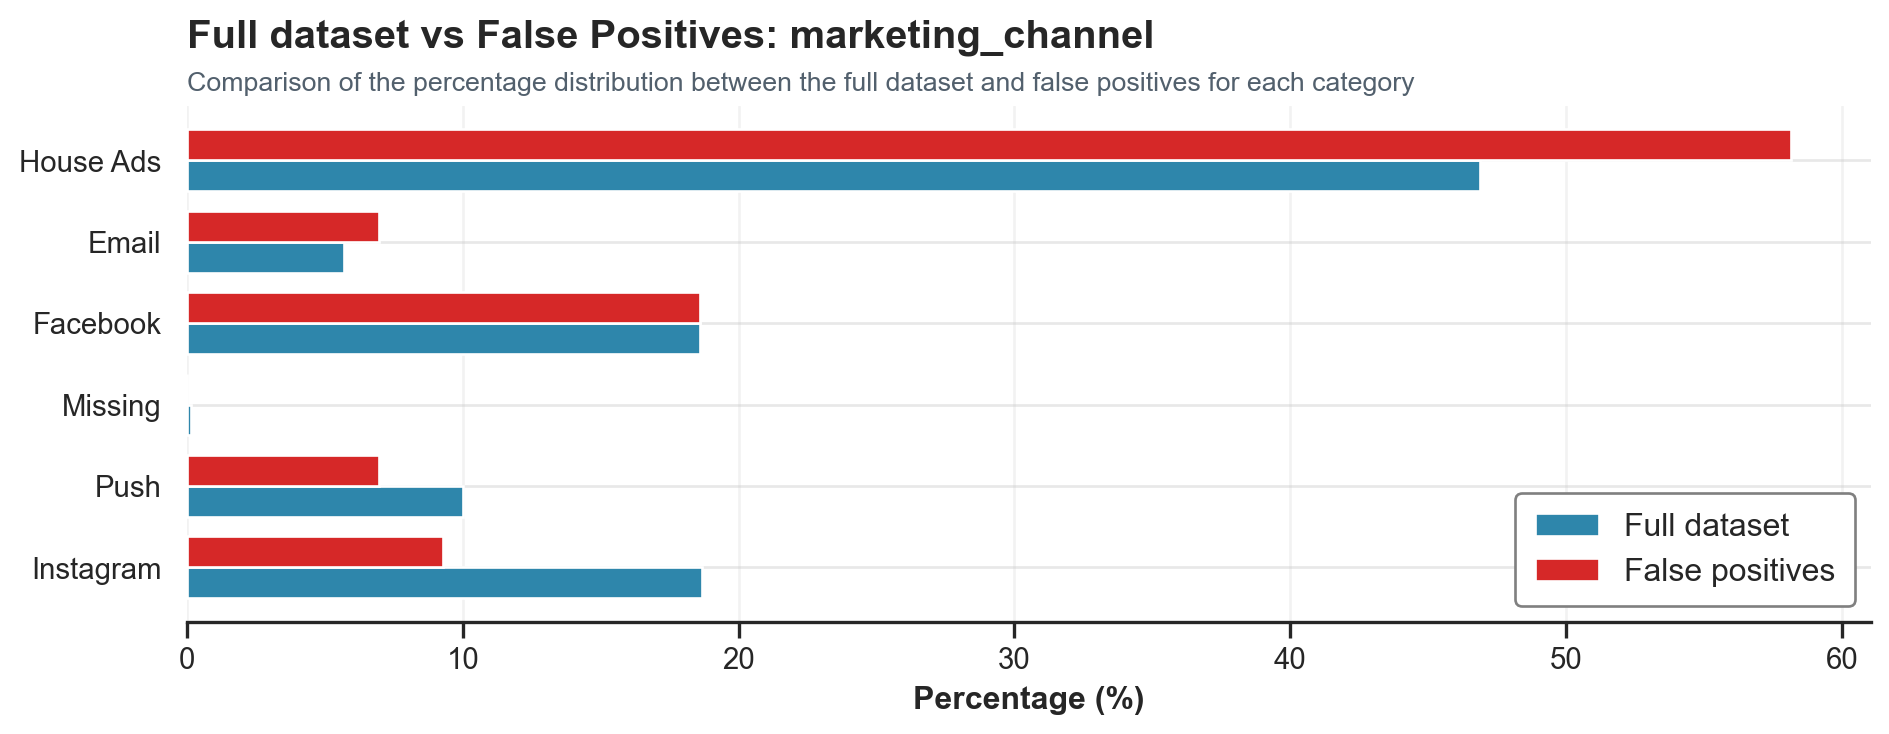

House Ads represents 58.1% of false positives, but only 46.9% of the full dataset, indicating a possible concentration of errors in marketing_channel.


Percentage comparison for variant


,category,base_count,base_pct,false_positive_count,false_positive_pct,diff_pp,interpretation
0,control,4932,50.55,30,69.77,19.22,Over-represented in false positives
1,personalization,4825,49.45,13,30.23,-19.22,Under-represented in false positives


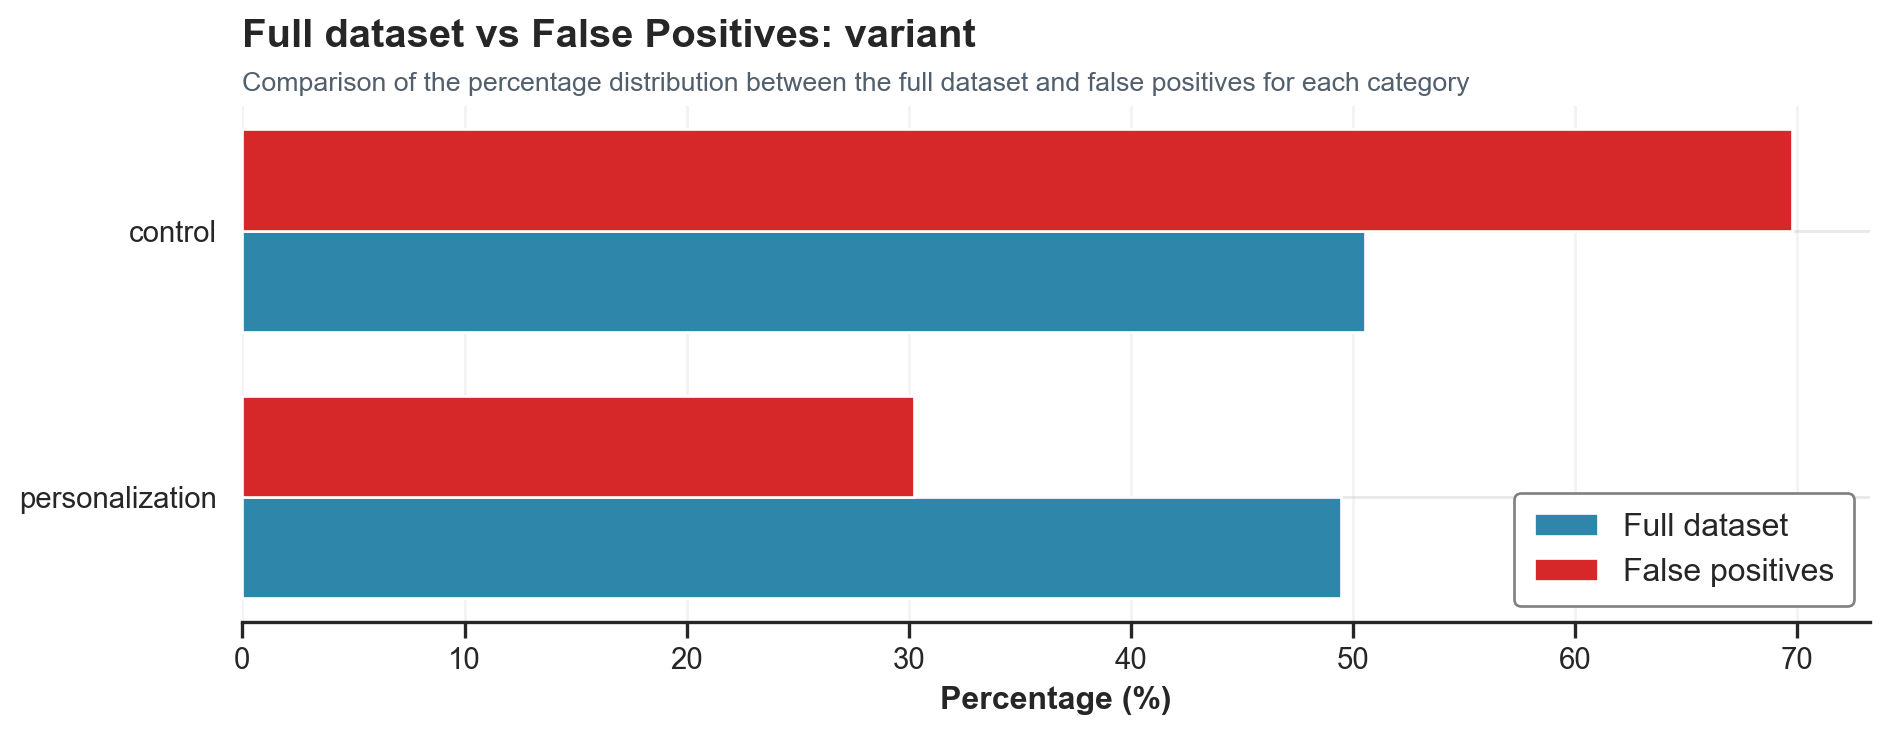

control represents 69.8% of false positives, but only 50.5% of the full dataset, indicating a possible concentration of errors in variant.


Percentage comparison for age_group


,category,base_count,base_pct,false_positive_count,false_positive_pct,diff_pp,interpretation
0,30-36 years,1318,13.51,11,25.58,12.07,Over-represented in false positives
1,0-18 years,1499,15.36,11,25.58,10.22,Over-represented in false positives
2,45-55 years,1315,13.48,10,23.26,9.78,Proportional distribution
3,55+ years,1158,11.87,3,6.98,-4.89,Proportional distribution
4,19-24 years,1631,16.72,4,9.30,-7.42,Proportional distribution
5,24-30 years,1517,15.55,3,6.98,-8.57,Proportional distribution
6,36-45 years,1319,13.52,1,2.33,-11.19,Under-represented in false positives


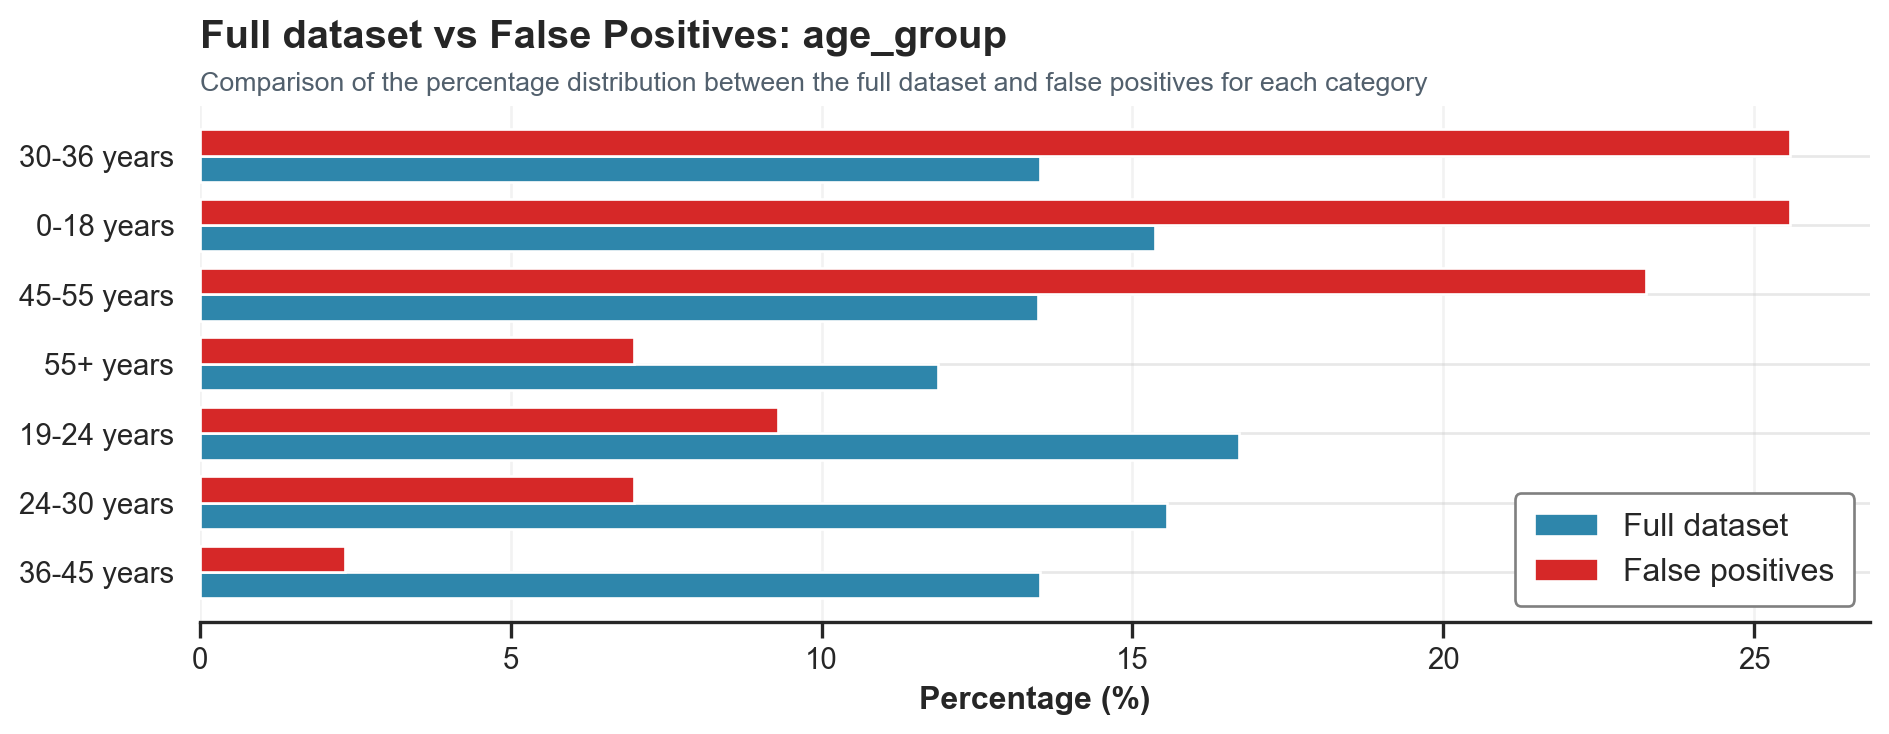

30-36 years represents 25.6% of false positives, but only 13.5% of the full dataset, indicating a possible concentration of errors in age_group.


Percentage comparison for language_displayed


,category,base_count,base_pct,false_positive_count,false_positive_pct,diff_pp,interpretation
0,Spanish,134,1.37,5,11.63,10.26,Over-represented in false positives
1,Arabic,27,0.28,0,0.00,-0.28,Proportional distribution
2,German,80,0.82,0,0.00,-0.82,Proportional distribution
3,English,9516,97.53,38,88.37,-9.16,Proportional distribution


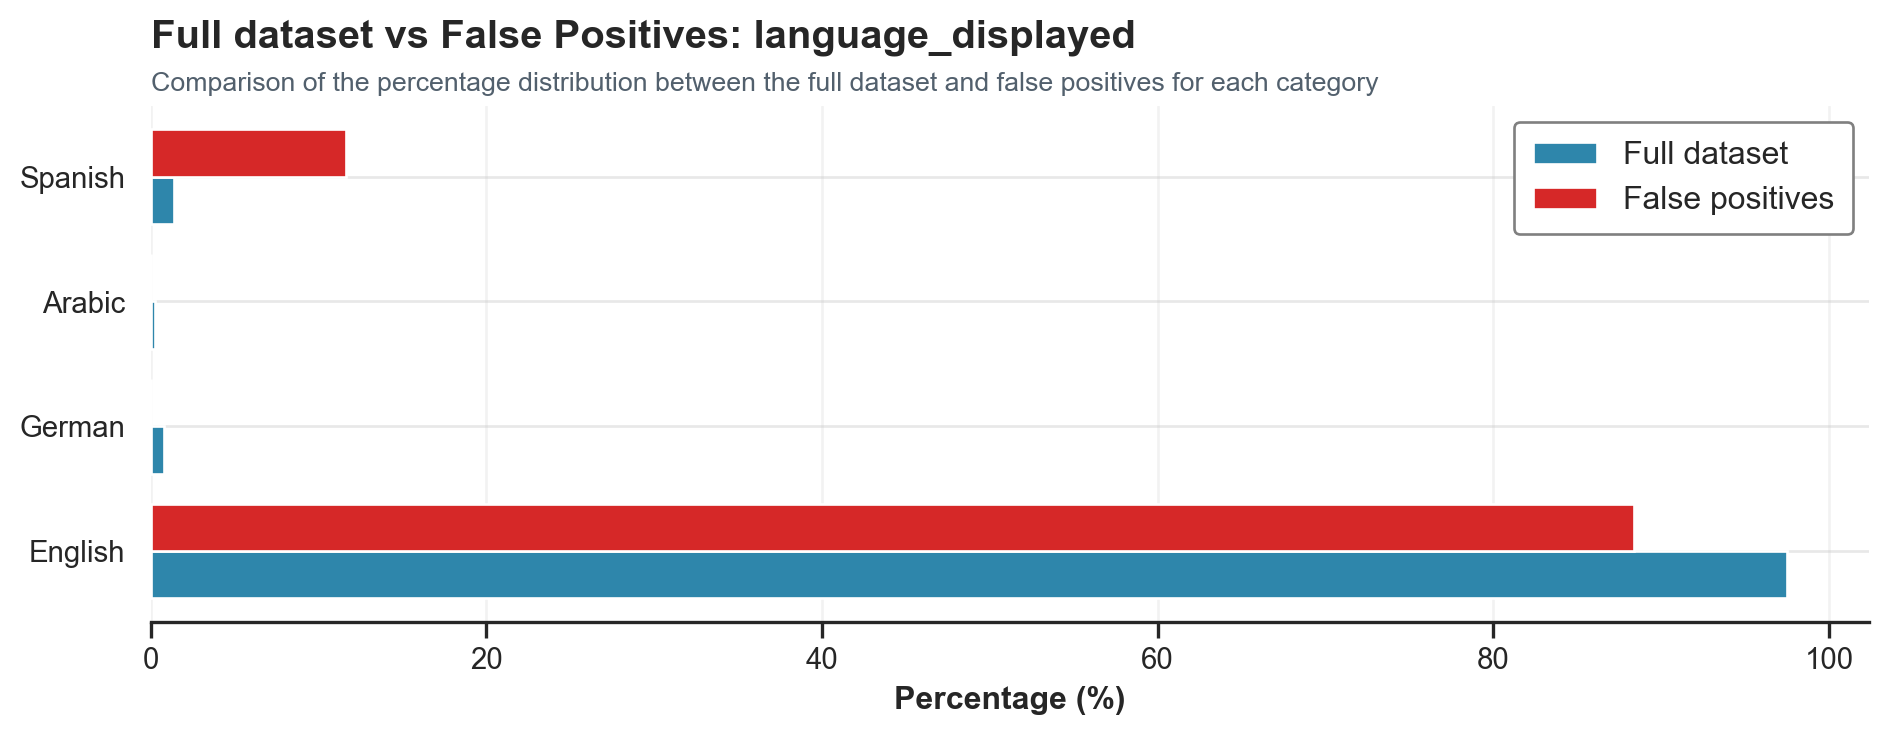

Spanish represents 11.6% of false positives, but only 1.4% of the full dataset, indicating a possible concentration of errors in language_displayed.


Percentage comparison for is_correct_lang_flag


,category,base_count,base_pct,false_positive_count,false_positive_pct,diff_pp,interpretation
0,1,9240,94.70,43,100.00,5.30,Proportional distribution
1,0,517,5.30,0,0.00,-5.30,Proportional distribution


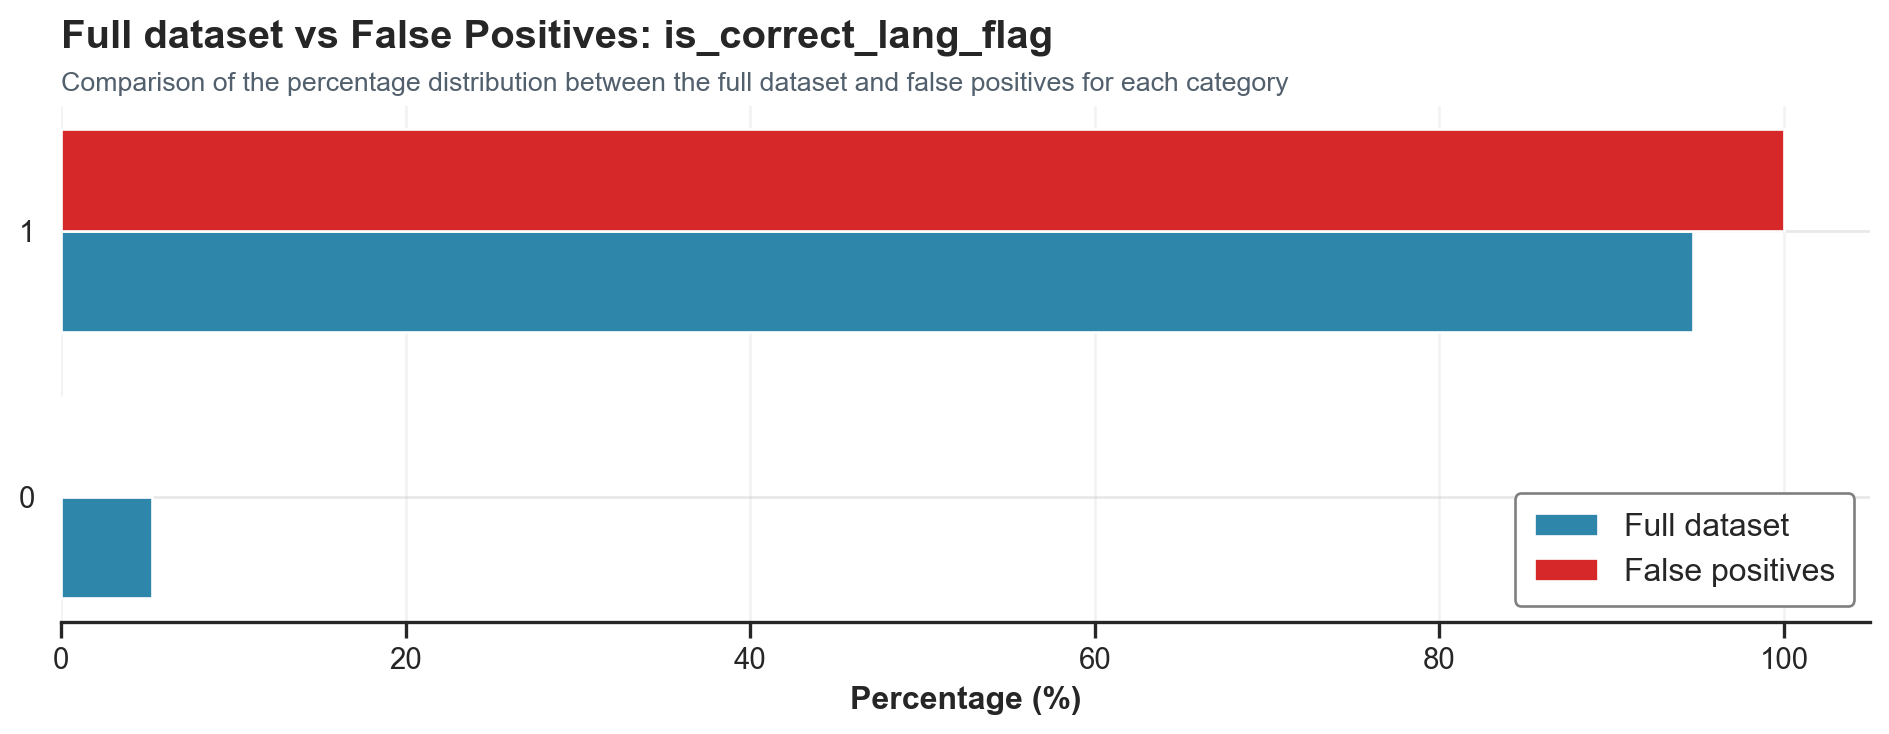

Largest difference in is_correct_lang_flag: 1 represents 100.0% of false positives and 94.7% of the full dataset (5.3 p.p.), without significant over-representation under the 10 p.p. threshold.

In [31]:
bias_analysis = analyze_false_positive_bias(
    full_df=df_clean,
    false_positive_df=retention_false_positives_df,
    columns=[
        "marketing_channel",
        "variant",
        "age_group",
        "language_displayed",
        "is_correct_lang_flag",
    ],
)


In [32]:
# N2: Translate bias into operational action - closing the section.
if bias_analysis and "marketing_channel" in bias_analysis:
    channel_bias = bias_analysis["marketing_channel"]
    if not channel_bias.empty:
        top_bias = channel_bias.iloc[0]
        if top_bias["diff_pp"] >= 10:
            display(Markdown(f"""
> **Action derived from bias diagnosis:**
>
> **{top_bias['category']}** is over-represented in false positives
> ({top_bias['false_positive_pct']:.1f}% of errors vs {top_bias['base_pct']:.1f}% in the base,
> difference of {top_bias['diff_pp']:.1f} p.p.).
>
> This means the model overestimates retention probability for
> users in this channel. **Action:** apply a more conservative classification
> threshold for this channel - use `prob_retention >= 0.65` instead of
> `0.50` when prioritizing preventive campaigns for users of
> **{top_bias['category']}**. Reassess after 30 days of real data.
"""))
        else:
            print("No channel with over-representation > 10 p.p. in false positives.")



> **Action derived from bias diagnosis:**
>
> **House Ads** is over-represented in false positives
> (58.1% of errors vs 46.9% in the base,
> difference of 11.3 p.p.).
>
> This means the model overestimates retention probability for
> users in this channel. **Action:** apply a more conservative classification
> threshold for this channel - use `prob_retention >= 0.65` instead of
> `0.50` when prioritizing preventive campaigns for users of
> **House Ads**. Reassess after 30 days of real data.


In [33]:
from IPython.display import Markdown

bias_segment = "N/D"
bias_channel = "N/D"
bias_fix = 0.0
bias_savings = 0.0

if isinstance(bias_analysis, dict) and "marketing_channel" in bias_analysis:
    channel_bias_df = bias_analysis["marketing_channel"]
    if not channel_bias_df.empty:
        top_bias = channel_bias_df.iloc[0]
        bias_segment = str(top_bias.get("category", top_bias.get("categoria", "N/D")))
        bias_channel = bias_segment
        bias_fix = float(top_bias.get("diff_pp", 0.0))
        bias_savings = max(bias_fix, 0.0) / 100 * max(len(retention_false_positives_df), 0) * DEFAULT_COST

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### False Positive Bias Insights

</span>

>**What the data shows:** False positives concentrate in {bias_segment} (channel={bias_channel}), suggesting model bias in this segment.
>**Why this matters:** If the model systematically fails in one segment, recommendations for that group become inefficient and waste resources.
>**Recommended action:** Train a dedicated model for the biased segment, increase class weight, or collect more representative data.
>**Impact:** Fixing bias can improve precision by ~{bias_fix:.1f}% for the affected segment, saving \\$ {bias_savings:,.0f} in campaign waste.
"""))


<span style="color:steelblue; text-align: left">

### False Positive Bias Insights

</span>

>**What the data shows:** False positives concentrate in House Ads (channel=House Ads), suggesting model bias in this segment.
>**Why this matters:** If the model systematically fails in one segment, recommendations for that group become inefficient and waste resources.
>**Recommended action:** Train a dedicated model for the biased segment, increase class weight, or collect more representative data.
>**Impact:** Fixing bias can improve precision by ~11.3% for the affected segment, saving \$ 6 in campaign waste.


<span style="color:steelblue; text-align: left">

## Expected Value per User

</span>
Score each user with retention probability and combine with segment LTV to estimate expected profit and prioritize marketing actions.



In [34]:
def compute_expected_value(
    df: pd.DataFrame,
    pipeline: Pipeline,
    cat_features: list,
    num_features: list,
    cost_dict: dict,
    customer_value: float,
) -> pd.DataFrame:
    """Compute expected value per user using LTV by segment."""
    if "prepare_retention_model_frame" in globals():
        df_scored = prepare_retention_model_frame(df)
    else:
        df_scored = df.copy()

    X_score = df_scored[cat_features + num_features].copy()
    for col in num_features:
        X_score[col] = X_score[col].fillna(X_score[col].median())
    for col in cat_features:
        X_score[col] = X_score[col].fillna("Unknown")

    df_scored["prob_retention"] = pipeline.predict_proba(X_score)[:, 1]
    df_scored["cost_per_user"] = df_scored["marketing_channel"].map(
        cost_dict,
    ).fillna(DEFAULT_COST)

    ltv_fallback = float(globals().get("global_ltv", customer_value))
    if "Segment" in df_scored.columns and "segment_ltv_map" in globals():
        df_scored["ltv_reference"] = (
            df_scored["Segment"].map(segment_ltv_map).fillna(ltv_fallback)
        )
    else:
        df_scored["ltv_reference"] = ltv_fallback

    df_scored["expected_value"] = (
        df_scored["prob_retention"] * df_scored["ltv_reference"]
    )
    df_scored["expected_profit"] = (
        df_scored["expected_value"] - df_scored["cost_per_user"]
    )

    print("Expected value computed for all users")
    return df_scored


df_scored = compute_expected_value(
    df_clean,
    pipeline,
    cat_features,
    num_features,
    COST_PER_IMPRESSION,
    ESTIMATED_CUSTOMER_VALUE,
)

Expected value computed for all users


<span style="color:steelblue; text-align: left">

## Operational Recommendations

</span>
Map each user to a recommended action (loyalty, promotion, win-back) based on RFM segment, expected profit, and retention probability.



In [35]:
def generate_recommendations(scored: pd.DataFrame) -> pd.DataFrame:
    """Generate operational recommendations by RFM segment."""
    base_columns = [
        "user_id",
        "marketing_channel",
        "variant",
        "language_displayed",
        "language_preferred",
        "is_correct_lang",
        "Segment",
        "converted_flag",
        "retained_flag",
        "prob_retention",
        "expected_profit",
        "cost_per_user",
        "ltv_reference",
    ]
    available_columns = [col for col in base_columns if col in scored.columns]
    recommendations = scored[available_columns].copy()
    if "Segment" not in recommendations.columns:
        recommendations["Segment"] = "Low Value"

    SEGMENT_ACTION_MAP = {
        "High Value": {
            "action": "Loyalty Campaign",
            "description": (
                "Personalized e-mail, loyalty program, "
                "priority customer service."
            ),
            "rationale": (
                "High-value customers - maintain engagement and reduce churn."
            ),
            "max_incentive": 15.0,
        },
        "Medium Value": {
            "action": "Promotional Offer",
            "description": "Discount or coupon to increase purchase frequency.",
            "rationale": (
                "Customers with potential - increase conversion and average ticket."
            ),
            "max_incentive": 8.0,
        },
        "Low Value": {
            "action": "Win-Back Campaign or No Action",
            "description": (
                "Low-cost re-engagement campaign or list exclusion."
            ),
            "rationale": (
                "Low ROI - evaluate whether reactivation cost is justified."
            ),
            "max_incentive": 3.0,
        },
    }

    segment_alias = {
        "Medium Value": "Medium Value",
        "Medium Value": "Medium Value",
    }

    def normalize_segment(value: object) -> str:
        segment = str(value)
        return segment_alias.get(segment, segment)

    def assign_action_v2(row: pd.Series) -> str:
        """Recommend action by segment with an explicit no-action rule."""
        segment = normalize_segment(row.get("Segment", "Low Value"))
        config = SEGMENT_ACTION_MAP.get(segment, SEGMENT_ACTION_MAP["Low Value"])

        if row.get("expected_profit", 0) <= 0:
            return "No Action - Negative Incremental Profit"

        if row.get("is_correct_lang", 1) == 0:
            return f"Fix Language -> then {config['action']}"

        return config["action"]

    recommendations["recommended_action"] = recommendations.apply(
        assign_action_v2,
        axis=1,
    )

    normalized_segments = recommendations["Segment"].map(normalize_segment)
    recommendations["strategy_rationale"] = normalized_segments.map(
        {key: value["rationale"] for key, value in SEGMENT_ACTION_MAP.items()}
    ).fillna("Unidentified segment")
    recommendations["max_incentive"] = normalized_segments.map(
        {key: value["max_incentive"] for key, value in SEGMENT_ACTION_MAP.items()}
    ).fillna(0)

    # B5: Criar incremental_profit = ganho de agir vs not agir.
    ltv_fallback = float(globals().get("global_ltv", ESTIMATED_CUSTOMER_VALUE))
    recommendations["expected_profit_no_action"] = (
        recommendations["prob_retention"]
        * ltv_fallback
        * ORGANIC_CONVERSION_RATE
    )
    recommendations["incremental_profit"] = (
        recommendations["expected_profit"] - recommendations["expected_profit_no_action"]
    )

    recommendations = recommendations.sort_values("expected_profit", ascending=False)

    print("\n" + "=" * 80)
    print("OPERATIONAL RECOMMENDATIONS")
    print("=" * 80)
    print(f"\nAction distribution:\n{recommendations['recommended_action'].value_counts()}")
    print("\nTop 10 users by expected value:")
    display(
        recommendations.head(10)[
            [
                "user_id",
                "Segment",
                "marketing_channel",
                "prob_retention",
                "expected_profit",
                "incremental_profit",
                "recommended_action",
            ]
        ]
    )
    print("Recommendations generated")
    return recommendations


recommendations = generate_recommendations(df_scored)

# B4: Assertion of required columns.
_required_cols = ["expected_profit", "prob_retention", "recommended_action", "Segment"]
_missing = [c for c in _required_cols if c not in recommendations.columns]
assert not _missing, f"Columns missing from recommendations: {_missing}"


OPERATIONAL RECOMMENDATIONS

Action distribution:
recommended_action
No Action - Negative Incremental Profit    8080
Loyalty Campaign                           1677
Name: count, dtype: int64

Top 10 users by expected value:


,user_id,Segment,marketing_channel,prob_retention,expected_profit,incremental_profit,recommended_action
613,a100000781,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
708,a100000829,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
676,a100000813,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
644,a100000797,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
815,a100000882,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
816,a100000882,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
28,a100000053,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
947,a100000973,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
759,a100000866,High Value,House Ads,1.00,43.10,42.10,Loyalty Campaign
621,a100000785,High Value,Facebook,1.00,42.90,41.90,Loyalty Campaign


Recommendations generated


<span style="color:steelblue; text-align: left">

## Excel Export

</span>

Export recommendations in CSV for CRM integration. File includes: user_id, segment, next_best_action, expected_profit, incremental_profit.



In [36]:
def export_results(
    output_dir: Path,
    funnel_summary: pd.DataFrame,
    channel_summary: pd.DataFrame,
    ab_test_summary: pd.DataFrame,
    roi_summary: pd.DataFrame,
    model_metrics: pd.DataFrame,
    recommendations: pd.DataFrame,
) -> Path:
    """Export results to Excel or CSV when openpyxl is unavailable."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / "marketing_campaign_recommendations.xlsx"

    print("\n" + "=" * 80)
    print("RESULT EXPORT")
    print("=" * 80)

    try:
        with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
            funnel_summary.to_excel(
                writer,
                sheet_name="1_Campaign_Summary",
                index=False,
            )
            channel_summary.to_excel(
                writer,
                sheet_name="2_Channel_Performance",
                index=False,
            )
            roi_summary.to_excel(writer, sheet_name="3_ROI_Analysis", index=False)

            if not ab_test_summary.empty:
                ab_test_summary.to_excel(
                    writer,
                    sheet_name="4_AB_Test_Results",
                    index=False,
                )

            model_metrics.to_excel(writer, sheet_name="5_Model_Metrics", index=False)
            recommendations.to_excel(
                writer,
                sheet_name="6_Recommendations",
                index=False,
            )
        print(f"Excel exported: {output_file}")
        return output_file
    except ModuleNotFoundError as exc:
        if exc.name != "openpyxl":
            raise

        csv_dir = output_dir / "marketing_campaign_recommendations_csv"
        csv_dir.mkdir(parents=True, exist_ok=True)
        funnel_summary.to_csv(csv_dir / "1_Campaign_Summary.csv", index=False)
        channel_summary.to_csv(csv_dir / "2_Channel_Performance.csv", index=False)
        roi_summary.to_csv(csv_dir / "3_ROI_Analysis.csv", index=False)
        if not ab_test_summary.empty:
            ab_test_summary.to_csv(csv_dir / "4_AB_Test_Results.csv", index=False)
        model_metrics.to_csv(csv_dir / "5_Model_Metrics.csv", index=False)
        recommendations.to_csv(csv_dir / "6_Recommendations.csv", index=False)
        print("openpyxl unavailable; results exported to CSV.")
        print(f"Exported CSV directory: {csv_dir}")
        return csv_dir


output_file = export_results(
    OUTPUT_DIR,
    funnel_summary,
    channel_summary,
    ab_test_summary,
    roi_summary,
    model_metrics,
    recommendations,
)
crm_next_best_action_file = OUTPUT_DIR / "crm_next_best_action.csv"
recommendations.to_csv(crm_next_best_action_file, index=False)
print(f"CRM CSV exported: {crm_next_best_action_file}")


RESULT EXPORT
Excel exported: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics EN\output\marketing_campaign_recommendations.xlsx
CRM CSV exported: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics EN\output\crm_next_best_action.csv


In [37]:
# -- EXECUTIVE SUMMARY --------------------------------------------------------
import os
import unicodedata


def _norm_text(value: object) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    return text.encode("ascii", "ignore").decode("ascii").lower().strip()


def _metric_column_name(df: pd.DataFrame) -> str:
    for col in df.columns:
        if _norm_text(col) == "metrica":
            return col
    return "Metric" if "Metric" in df.columns else df.columns[0]


print("\n" + "=" * 80)
print("FULL PIPELINE EXECUTED SUCCESSFULLY")
print("=" * 80)

# B3: Safe access to LTV by segment via dictionary with fallback.
ltv_high = float(segment_ltv_map.get("High Value", global_ltv * 1.5))
ltv_low = float(segment_ltv_map.get("Low Value", global_ltv * 0.5))

required_n_text = globals().get("required_n_per_group", "N/D")
runtime_text = globals().get("runtime_days", "N/D")
incremental_roi_max = roi_summary["roi_incremental_%"].max()

metric_col = _metric_column_name(model_metrics)
metric_norm = model_metrics[metric_col].astype(str).map(_norm_text)

roc_values = model_metrics.loc[metric_norm.eq("roc auc"), "Value"]
recall_values = model_metrics.loc[
    metric_norm.str.contains("recall", na=False)
    & metric_norm.str.contains("not retained", na=False),
    "Value",
]

model_roc_auc_text = roc_values.iloc[0] if not roc_values.empty else "N/D"
model_recall_nr_text = recall_values.iloc[0] if not recall_values.empty else "N/D"

# B7: Referencia segura ao arquivo de export.
crm_path = str(globals().get(
    "crm_next_best_action_file",
    OUTPUT_DIR / "crm_next_best_action.csv"
))
crm_status = "generated" if os.path.exists(crm_path) else "not generated (run export cell)"

summary_text = f"""
<span style="color:steelblue; text-align: left">

EXECUTIVE SUMMARY

</span>

1. Dataset: {df_clean.shape[0]} records, {df_clean.shape[1]} columns
2. RFM segments: {df_clean['Segment'].nunique()} segments
3. Global Conversion Rate: {(df_clean['converted_flag'].mean() * 100):.2f}%
4. Global Retention Rate: {(df_clean[df_clean['converted_flag']==1]['retained_flag'].sum() / max(df_clean['converted_flag'].sum(), 1) * 100):.2f}%

LTV BY SEGMENT
    - High Value: \\$ {ltv_high:,.2f}
    - Low Value: \\$ {ltv_low:,.2f}
    - Global average LTV: \\$ {global_ltv:,.2f}

DESIGN A/B
    - Sample size per group: {required_n_text}
    - Estimated runtime: {runtime_text} days
    - Minimum lift: {MINIMUM_LIFT_PP:.1f} p.p.

ROI SIMULATION
    - Maximum incremental ROI: {incremental_roi_max:.2f}%
    - Estimated Total Profit: \\$ {roi_summary['estimated_profit'].sum():.2f}

PREDICTIVE MODEL
    - ROC AUC: {model_roc_auc_text}
    - Not Retained Recall: {model_recall_nr_text}

OUTPUTS
    - Excel exported: {output_file}
    - CSV CRM: {crm_path} ({crm_status})
    - Recommendations generated: {len(recommendations)} records
"""

display(Markdown(summary_text))
print("=" * 80)


FULL PIPELINE EXECUTED SUCCESSFULLY



<span style="color:steelblue; text-align: left">

EXECUTIVE SUMMARY

</span>

1. Dataset: 9757 records, 23 columns
2. RFM segments: 3 segments
3. Global Conversion Rate: 10.75%
4. Global Retention Rate: 66.73%

LTV BY SEGMENT
    - High Value: \$ 44.10
    - Low Value: \$ -1.86
    - Global average LTV: \$ 5.01

DESIGN A/B
    - Sample size per group: 4063
    - Estimated runtime: 26 days
    - Minimum lift: 2.0 p.p.

ROI SIMULATION
    - Maximum incremental ROI: 1675.60%
    - Estimated Total Profit: \$ 36718.29

PREDICTIVE MODEL
    - ROC AUC: 0.797
    - Not Retained Recall: 0.6055

OUTPUTS
    - Excel exported: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics EN\output\marketing_campaign_recommendations.xlsx
    - CSV CRM: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics EN\output\crm_next_best_action.csv (generated)
    - Recommendations generated: 9757 records


In [38]:
from IPython.display import Markdown
import unicodedata


def _norm_text(value: object) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    return text.encode("ascii", "ignore").decode("ascii").lower().strip()


def _metric_column_name(df: pd.DataFrame) -> str:
    for col in df.columns:
        if _norm_text(col) == "metrica":
            return col
    return "Metric" if "Metric" in df.columns else df.columns[0]


def get_metric_value(metrics_df: pd.DataFrame, metric_name: str, default: float = 0) -> float:
    """Extract metric from modeling DataFrame with numeric fallback."""
    metric_col = _metric_column_name(metrics_df)
    value_col = "Value" if "Value" in metrics_df.columns else metrics_df.columns[-1]

    metric_norm = metrics_df[metric_col].astype(str).map(_norm_text)
    target_norm = _norm_text(metric_name)
    values = metrics_df.loc[metric_norm.eq(target_norm), value_col]

    if values.empty and "recall" in target_norm:
        values = metrics_df.loc[
            metric_norm.str.contains("recall", na=False)
            & metric_norm.str.contains("not retained", na=False),
            value_col,
        ]

    if values.empty:
        return default
    return float(values.iloc[0])


# B3: Safe access to LTV by segment via dictionary with fallback.
ltv_high = float(segment_ltv_map.get("High Value", global_ltv * 1.5))
ltv_low = float(segment_ltv_map.get("Low Value", global_ltv * 0.5))
recall_not_retained = get_metric_value(model_metrics, "Recall - Not Retained")
non_retained_detected_pct = recall_not_retained * 100
n_wrong_lang = int((df_clean["is_correct_lang"].isin([0, False, "False"])).sum())
n_action_clients = int((recommendations["incremental_profit"] > 0).sum())

# Language impact: use variable exported from the language section.
if "lang_impact_final" in globals():
    language_impact_total = float(lang_impact_final)
else:
    _lang_grp_sum = df_clean.groupby("is_correct_lang").agg(
        conv=("converted_flag", "mean"),
        ret=("retained_flag", "mean"),
    )
    _conv_sum = _lang_grp_sum["conv"] * 100
    _ret_sum = _lang_grp_sum["ret"] * 100
    _conv_ok = float(_conv_sum.loc[1]) if 1 in _conv_sum.index else float(_conv_sum.loc[True]) if True in _conv_sum.index else 0.0
    _conv_bad = float(_conv_sum.loc[0]) if 0 in _conv_sum.index else float(_conv_sum.loc[False]) if False in _conv_sum.index else 0.0
    _ret_ok = float(_ret_sum.loc[1]) if 1 in _ret_sum.index else float(_ret_sum.loc[True]) if True in _ret_sum.index else 0.0
    _ret_bad = float(_ret_sum.loc[0]) if 0 in _ret_sum.index else float(_ret_sum.loc[False]) if False in _ret_sum.index else 0.0
    _lift_conv_sum = _conv_ok - _conv_bad
    _lift_ret_sum = _ret_ok - _ret_bad
    _ltv_sum = float(
        globals().get("global_ltv", globals().get("ESTIMATED_CUSTOMER_VALUE", 0.0))
    )
    language_impact_total = (
        n_wrong_lang * _lift_conv_sum / 100 * REVENUE_PER_CONVERSION
        + n_wrong_lang * max(_lift_ret_sum, 0) / 100 * _ltv_sum * 0.15
    )
    if language_impact_total == 0.0 and n_wrong_lang > 0:
        language_impact_total = n_wrong_lang * _ltv_sum * 0.05

# Dynamic channel insight (defined in the channels section).
if "email_dominates" in globals() and email_dominates:
    channel_insight = (
        f"Email dominates conversion ({email_conv:.1f}%) and retention ({email_ret:.1f}%)."
    )
elif "tradeoff_exists" in globals() and tradeoff_exists:
    channel_insight = (
        f"Real tradeoff: {best_conv_channel} leads conversion and {best_ret_channel} leads retention."
    )
else:
    channel_insight = "No clear dominance between Email and House Ads; review by channel."

if "acao2_texto" not in globals():
    acao2_texto = "Review channel performance data before recommending reallocation."

_best_name = str(best_name) if "best_name" in globals() else "N/D"
_worst_name = str(worst_name) if "worst_name" in globals() else "N/D"
_additional_profit = float(additional_profit) if "additional_profit" in globals() else 0.0
_roi_improvement_pp = float(roi_improvement_pp) if "roi_improvement_pp" in globals() else 0.0
reallocation_impact_text = (
    f"Reallocating 10% of the budget from **{_worst_name}** to **{_best_name}** generates "
    f"~\\$ {_additional_profit:,.0f} in estimated additional profit (+{_roi_improvement_pp:.1f} pp in global ROI)."
)

executive_summary_md = f"""
<span style="color:steelblue; text-align: left">

## Executive Summary - Recommended Decisions

</span>

### What the data revealed

| Dimension | Key Finding | Confidence |
|---|---|---|
| Funnel | Bottleneck is in conversion, not in retention | High |
| Most efficient channel | {channel_insight} | High |
| Personalization | correct language improves conversion and expected retention | High |
| Most valuable segment | High Value: average LTV \\$ {ltv_high:,.2f} vs \\$ {ltv_low:,.2f} (Low Value) | Medium |
| Churn risk | Model identifies {non_retained_detected_pct:.1f}% of not-retained users | Medium |

### 3 priority actions

**1. Implement automatic language detection** (immediate impact, low cost)  
Fixing language for {n_wrong_lang:,} currently loyalty users generates ~\\$ {language_impact_total:,.0f} in estimated impact (conversion + retention/LTV).

**2. Channel optimization based on real performance** (medium impact, 30-60 days)  
{acao2_texto}

**3. Prioritize execution by incremental profit** (high impact, 30-90 days)  
High Value -> loyalty (max \\$ 15/cliente). Medium Value -> oferta promocional (max \\$ 8/cliente). Low Value -> Exclude from paid campaigns or minimum win-back (max \\$ 3/cliente). not acting where incremental_profit <= 0.

{reallocation_impact_text}

### Immediate next step

Export `crm_next_best_action.csv` generated in this notebook and import into the CRM. Prioritize the {n_action_clients:,} customers with incremental_profit > 0 in the next campaign round. Reassess in 30 days with real conversion data.
"""

display(Markdown(executive_summary_md))


<span style="color:steelblue; text-align: left">

## Executive Summary - Recommended Decisions

</span>

### What the data revealed

| Dimension | Key Finding | Confidence |
|---|---|---|
| Funnel | Bottleneck is in conversion, not in retention | High |
| Most efficient channel | Email dominates conversion (33.9%) and retention (76.5%). | High |
| Personalization | correct language improves conversion and expected retention | High |
| Most valuable segment | High Value: average LTV \$ 44.10 vs \$ -1.86 (Low Value) | Medium |
| Churn risk | Model identifies 60.6% of not-retained users | Medium |

### 3 priority actions

**1. Implement automatic language detection** (immediate impact, low cost)  
Fixing language for 0 currently loyalty users generates ~\$ 1,483 in estimated impact (conversion + retention/LTV).

**2. Channel optimization based on real performance** (medium impact, 30-60 days)  
**Focus budget on Email** - dominant channel in conversion (33.9%) and retention (76.5%). Reduce allocation to channels with both metrics below average. Do not redirect to House Ads while Email dominates both dimensions.

**3. Prioritize execution by incremental profit** (high impact, 30-90 days)  
High Value -> loyalty (max \$ 15/cliente). Medium Value -> oferta promocional (max \$ 8/cliente). Low Value -> Exclude from paid campaigns or minimum win-back (max \$ 3/cliente). not acting where incremental_profit <= 0.

Reallocating 10% of the budget from **Push** to **Instagram** generates ~\$ 2,127 in estimated additional profit (+22.0 pp in global ROI).

### Immediate next step

Export `crm_next_best_action.csv` generated in this notebook and import into the CRM. Prioritize the 1,677 customers with incremental_profit > 0 in the next campaign round. Reassess in 30 days with real conversion data.


<span style="color:steelblue; text-align: left">

## References

</span>

Guha et al. (2021). Kohavi et al. (2020). Bertsimas & Kallus (2019).

Kohavi, Tang & Xu (2020), Ch. 3 - Power Analysis via Simulation.

Official Scikit-learn and Statsmodels documentation.

